# Model Validation of a CDS Hazard-Rate Framework for Credit Risk under Stochastic Intensity
**Author**: [Jovan Zigic](https://www.jovanzigic.com/)  
**Date**: March 20, 2026

## 1. Purpose

We conduct a comprehensive model risk assessment of a hazard-rate framework for credit default swaps (CDS) extended by stochastic intensity and correlated defaults.

I am very interested in model risk management because it focuses on something I value strongly - reducing uncertainty through rigorous analysis. Model risk management requires careful validation, clear communication, and intellectual independence, which aligns closely with how I approach research.  

## 2. Scope of Knowledge

The following concepts and resources have been critical to my understanding of quantitative analysis for financial markets, whether or not they were directly applied to this project.

**Skills**:
1. Foundational Mathematics (Linear Algebra, Probability, Statistics)
2. Stochastic Calculus (Martingales/Markov Processes, Geometric Brownian Motion, Itô's lemma)
3. Mathematical Finance (Risk-Neutral Valuation, Derivatives Pricing, Greeks/Hedging, Arbitrage)
4. Numerical Methods (Optimization, Monte Carlo Simulation, Finite Difference Methods)
5. Programming (Python, C++)

**References**:
1. [Wilmott, P. (2007). *Paul Wilmott Introduces Quantitative Finance (2nd Edition).*](https://www.amazon.com/Paul-Wilmott-Introduces-Quantitative-Finance/dp/0470319585)
2. [Wilmott, P. (2009). *Frequently Asked Questions in Quantitative Finance (2nd Edition).*](https://www.amazon.com/Frequently-Asked-Questions-Quantitative-Finance/dp/0470748753)
3. [Morini, M. (2010). *Understanding and Managing Model Risk.*](https://www.amazon.com/Understanding-Managing-Model-Risk-Validators/dp/0470977612)
4. [Federal Reserve Board. (2011). *SR 11-7: Supervisory Guidance on Model Risk Management.*](https://www.federalreserve.gov/boarddocs/srletters/2011/sr1107a1.pdf)
5. [OCC. (2021). *Comptroller’s Handbook: Model Risk Management.*](https://www.federalreserve.gov/boarddocs/srletters/2011/sr1107a1.pdf)
6. [MRMIA. (2025). *Principles for Model Risk Management.*](https://www.federalreserve.gov/boarddocs/srletters/2011/sr1107a1.pdf)

## 3. Documented Framework

This framework provides a comprehensive, standardized model risk assessment with cross-asset applicability. It is not intended to replicate the dynamic, model-specific validation, monitoring, and governance processes implemented throughout the model lifecycle in production environments.

1. **[Verification](#d1)**  
a. [Mathematical formulation](#d1a)  
b. [Numerical stability and convergence](#d1b)  
c. [Independent replication](#d1c)  
d. [Payoff and boundary condition validation](#d1d)  

2. **[Conceptual Soundness](#d2)**  
a. [Model assumptions](#d2a)  
b. [Financial rationale](#d2b)  
c. [Applicability](#d2c)  
d. [Structural limitations](#d2d)  

3. **[Calibration](#d3)**  
a. [Methodology](#d3a)  
b. [Parameter stability](#d3b)  
c. [Data quality](#d3c)  
d. [Sensitivity to inputs](#d3d)  

4. **[Benchmarking](#d4)**  
a. [Challenger models](#d4a)  
b. [Comparison metrics](#d4b)  
c. [Relative differences](#d4c)  

5. **[Outcomes Analysis](#d5)**  
a. [Back-testing](#d5a)  
b. [Predictive performance](#d5b)  
c. [Error decomposition](#d5c)  

6. **[Stress Testing](#d6)**  
a. [Extreme scenarios](#d6a)  
b. [Parameter shocks](#d6b)  
c. [Breakdown regions](#d6c)  
d. [Robustness](#d6d)  

7. **[Validation Conclusion](#d7)**  
a. [Approval status](#d7a)  
b. [Limitations](#d7b)  
c. [Usage restrictions](#d7c)  
d. [Required improvements](#d7d)  

8. **[Ongoing Monitoring](#d8)**  
a. [Performance tracking](#d8a)  
b. [Model drift](#d8b)  
c. [Thresholds and triggers](#d8c)  
d. [Recalibration frequency](#d8d)  
e. [Change management](#d8e)  

## 4. Summary

This quantitative finance project covers the following generalized specifications:
1. **Task**: Model Validation
2. **Instrument**: Credit Default Swaps (CDS)
3. **Model Class**: Reduced-Form (Hazard-Rate)
4. **Risk Domain**: Credit Risk
5. **Model Features**: Stochastic Intensity; Correlated Defaults

We assess the model’s fitness for purpose across key dimensions of model risk, including conceptual soundness, calibration, benchmarking, robustness, and governance.

The model demonstrates acceptable performance for its intended use, subject to identified limitations. In particular, we find that the model is:
1. **Mathematically well-defined, numerically stable, and interpretable** under standard discretization schemes.
2. **Conceptually appropriate** given its assumptions, with known limitations under stressed and extreme regimes.
3. **Calibrated to synthetic data with strong fit**, though sensitivity to parameter choices is observed.
4. **Consistent with benchmark models**, with differences attributable to structural features and stochastic extensions.
5. **Practical for simulation-based applications**, including pricing and scenario analysis.
6. **Well-characterized across baseline and stressed conditions**, including identified breakdown regions.
7. **Acceptable from a model risk perspective**, subject to documented limitations and appropriate use constraints.
8. **Suitable for ongoing monitoring**, with clearly defined thresholds, recalibration triggers, and governance controls.

Full details of the analysis and supporting evidence are provided in the remainder of this document.

---

# 1. Verification 
<a id="d1"></a>
*(Did we build the model correctly?)*

## 1.a. Mathematical formulation 
<a id="d1a"></a>
*(Is the model mathematically well-defined and internally consistent?)*

We consider a reduced-form credit risk framework under the risk-neutral measure $\mathbb{Q}$. In the deterministic case, the survival probability is
$$ \mathbb{Q}(\tau > t) = \exp \left(-\int_0^t \lambda(s) \ ds \right), \tag{1.1} $$
where $\lambda(s)$ is the default intensity. We extend this framework by modeling the default time $\tau$ as a Cox (doubly stochastic Poisson) time driven by stochastic intensity $\lambda_t$. Specifically, the stochastic intensity follows a Cox-Ingersoll-Ross (CIR) diffusion process under $\mathbb{Q}$,
$$ d\lambda_t = \kappa (\theta - \lambda_t) dt + \sigma \sqrt{\lambda_t} dW_t ~~,~~ \lambda_0 >0, \tag{1.2} $$
where $\kappa>0$ is the mean-reversion speed, $\theta>0$ is the long-run mean, and $\sigma>0$ is the volatility. To ensure strict positivity of the intensity, we assume the Feller condition 
$$ 2\kappa \theta \geq \sigma^2 . \tag{1.3}$$
In this setting, the survival probability conditional on the filtration generated by $\lambda_t$ is
$$ \mathbb{Q}\left( \tau > t \ \vert \ \mathcal{F}_t^{\lambda} \right) = \exp \left(-\int_0^t \lambda_s \ ds \right), \tag{1.4}$$
and the unconditional survival probability is given by 
$$ \mathbb{Q}(\tau > t) = \mathbb{E}^{\mathbb{Q}} \left[ \exp \left(-\int_0^t \lambda_s \ ds \right)\right]. \tag{1.5}$$
For a portfolio of $n$ obligors, we consider individual stochastic intensities 
$$\lambda_t^{(i)} ~~,~~i=1,2,\dotsc,n \tag{1.6}$$ 
such that each evolves as a CIR process 
$$ d\lambda_t^{(i)} = \kappa_i (\theta_i - \lambda_t^{(i)}) dt + \sigma_i \sqrt{\lambda_t^{(i)}} dW_t^{(i)}. \tag{1.7}$$
We assume dependence between obligors through correlated Brownian motions
$$ dW_t^{(i)}dW_t^{(j)} = \rho_{ij}dt , \tag{1.8}$$
or equivalently
$$ \text{Corr}(dW_t^{(i)},dW_t^{(j)})= \rho_{ij}.  \tag{1.9}$$

Therefore, default times $\tau_i$ associated with stochastic intensities $\lambda_t^{(i)}$ yield correlated defaults through the joint dynamics of the intensity processes. For each obligor $i$, let $E_i\sim \text{Exp}(1)$ be independent standard exponential random variables. The default time is defined by
$$ \tau_i = \inf\left\{ t\geq 0 \ \Big\vert \ \int_0^t \lambda_s^{(i)} \ ds \geq E_i \right\}, \tag{1.10}$$
ensuring that, conditional on the path of $\lambda_t^{(i)}$, the survival probability satisfies
$$ \mathbb{Q}\left( \tau_i > t \ \vert \ \mathcal{F}_t^{\lambda^{(i)}} \right) = \exp \left(-\int_0^t \lambda_s^{(i)} \ ds \right). \tag{1.11}$$
We consider a standard CDS contract with maturity $T$, constant risk-free rate $r$, recovery rate $R\in [0,1]$, and spread $s$. The protection leg is given by
$$ \text{Prot} = \mathbb{E}^{\mathbb{Q}} \left[ e^{-r\tau}(1-R)\mathbf{1}_{\{\tau \leq T\}}  \right]\tag{1.12}$$
and the premium leg is given by
$$ \text{Prem} = \mathbb{E}^{\mathbb{Q}} \left[\int_0^T e^{-rt}s\mathbf{1}_{\{\tau > t\}} \ dt  \right]\tag{1.13}$$
such that the fair CDS spread $s$ is determined by the equilibrium condition
$$ \text{Prem} = \text{Prot}, \tag{1.14}$$
Solving for $s$, the fair CDS spread is given by
$$ s = \frac{ \mathbb{E}^{\mathbb{Q}} \left[ e^{-r\tau}(1-R)\mathbf{1}_{\{\tau \leq T\}} \right] }{ \mathbb{E}^{\mathbb{Q}} \left[\int_0^T e^{-rt}\mathbf{1}_{\{\tau > t\}} \ dt  \right] }, \tag{1.15} $$
where the denominator defines the risky annuity
$$ \text{Annuity} = \mathbb{E}^{\mathbb{Q}} \left[\int_0^T e^{-rt}\mathbf{1}_{\{\tau > t\}} \ dt  \right] \tag{1.16} $$
so that $(1.15)$ is equivalently expressed as
$$ s = \frac{ \text{Prot} }{ \text{Annuity} }. \tag{1.17} $$

## 1.b. Numerical stability and convergence 
<a id="d1b"></a>
*(Do numerical methods yield stable results and converge as discretization is refined?)*

The CIR intensity process is simulated using a time-discretization scheme. A standard Euler-Maruyama discretization is given by
$$ \lambda_{t+\Delta t} = \lambda_t + \kappa(\theta-\lambda_t)\Delta t + \sigma\sqrt{\lambda_t} \Delta W_t  \tag{1.18}$$
Since this scheme may produce negative values of $\lambda_t$, a full truncation approach is employed to ensure non-negativity. Stability of the simulated intensity paths is verified by checking positivity and boundedness across discretizations.  

The integrated intensity is approximated using a Riemann sum,
$$ \int_0^t \lambda_s \ ds \approx \sum_k \lambda_{t_k}  \Delta t, \tag{1.19}$$
which converges with order $\mathcal{O} (\Delta t) $ as $\Delta t\to 0$.

Monte Carlo estimates of CDS quantities are obtained using $N$ simulated paths. Convergence is assessed via standard Monte Carlo error scaling $\mathcal{O}\left(\frac 1{\sqrt{N}}\right)$, and stability is verified by examining sensitivity of results to both $N$ and $\Delta t$.

Default times are computed by identifying the first time at which the cumulative intensity exceeds an exponential threshold. Discretization introduces error in the default timing, which is mitigated by refining the time grid.

### I. Numerical Set-up

In [4]:
# Python functions for linear algebra, data analysis, and visualization
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [5]:
# Model parameters
kappa   = 1.5
theta   = 0.03
sigma   = 0.15
lam0    = 0.02

r       = 0.03
R       = 0.4
T       = 5.0

seed    = 12345

In [6]:
def simulate_cir_full_truncation(kappa, theta, sigma, lam0, T, dt, n_paths, seed=None):
    """
    Full-truncation Euler simulation of the CIR process:
        dλ_t = κ(θ - λ_t) dt + σ sqrt(λ_t) dW_t

    Returns
    -------
    times : (n_steps+1,)
    lam   : (n_paths, n_steps+1)
    """
    rng = np.random.default_rng(seed)

    n_steps = int(round(T / dt))
    times = np.linspace(0.0, T, n_steps + 1)

    lam = np.empty((n_paths, n_steps + 1), dtype=float)
    lam[:, 0] = lam0

    sqrt_dt = np.sqrt(dt)

    for k in range(n_steps):
        lam_pos = np.maximum(lam[:, k], 0.0)
        dW = rng.normal(0.0, sqrt_dt, size=n_paths)

        lam[:, k+1] = (
            lam[:, k]
            + kappa * (theta - lam_pos) * dt
            + sigma * np.sqrt(lam_pos) * dW
        )

    return times, lam

In [7]:
def integrated_intensity(lam, dt):
    """
    Left Riemann sum for ∫ λ_s ds along each path.
    Returns cumulative integrated intensity at all time points.
    """
    n_paths, n_cols = lam.shape
    out = np.zeros((n_paths, n_cols), dtype=float)
    out[:, 1:] = np.cumsum(np.maximum(lam[:, :-1], 0.0) * dt, axis=1)
    return out

In [8]:
def survival_curve_from_paths(lam, dt):
    """
    Monte Carlo estimate of survival curve:
        S(t) = E[exp(-∫_0^t λ_s ds)]
    """
    A = integrated_intensity(lam, dt)
    S = np.exp(-A).mean(axis=0)
    return S

In [9]:
def default_times_from_paths(lam, dt, seed=None):
    """
    Construct default times via Cox construction:
        τ = inf{ t >= 0 | ∫_0^t λ_s ds >= E },  E ~ Exp(1)

    Returns
    -------
    tau : (n_paths,)
        Default times; if no crossing by T, returns np.inf
    """
    rng = np.random.default_rng(seed)

    A = integrated_intensity(lam, dt)
    n_paths, n_cols = A.shape
    T = dt * (n_cols - 1)

    E = rng.exponential(scale=1.0, size=n_paths)

    crossed = A >= E[:, None]
    first_idx = np.argmax(crossed, axis=1)

    has_default = crossed.any(axis=1)
    tau = np.full(n_paths, np.inf, dtype=float)
    tau[has_default] = first_idx[has_default] * dt

    return tau

In [10]:
def cds_protection_leg_from_tau(tau, r, R, T):
    return np.mean(np.exp(-r * tau) * (1.0 - R) * (tau <= T))

def cds_premium_leg_from_tau(tau, r, s, T, dt):
    """
    Continuous-premium approximation:
        E[ ∫_0^T e^{-rt} s 1_{τ > t} dt ]
    """
    times = np.arange(0.0, T + 1e-12, dt)
    alive = (tau[:, None] > times[None, :]).astype(float)
    vals = np.exp(-r * times)[None, :] * alive
    annuity = np.trapezoid(vals, times, axis=1).mean()
    return s * annuity

def cds_fair_spread_from_tau(tau, r, R, T, dt):
    prot = cds_protection_leg_from_tau(tau, r, R, T)
    times = np.arange(0.0, T + 1e-12, dt)
    alive = (tau[:, None] > times[None, :]).astype(float)
    vals = np.exp(-r * times)[None, :] * alive
    annuity = np.trapezoid(vals, times, axis=1).mean()
    return prot / annuity

### II. Positivity and path stability

We first verify that the full-truncation Euler scheme maintains non-negativity of the simulated intensity paths and produces stable path behavior. The minimum simulated intensity should remain non-negative under full truncation. The sample paths should also exhibit stable mean-reverting behavior without numerical blow-up.

In [8]:
dt_test = 0.01
n_paths_test = 50000

times, lam = simulate_cir_full_truncation(
    kappa=kappa, theta=theta, sigma=sigma, lam0=lam0,
    T=T, dt=dt_test, n_paths=n_paths_test, seed=seed
)

summary_df = pd.DataFrame({
    "quantity": ["min intensity", "max intensity", "mean terminal intensity", "std terminal intensity"],
    "value": [
        lam.min(),
        lam.max(),
        lam[:, -1].mean(),
        lam[:, -1].std(ddof=1)
    ]
})

summary_df

,quantity,value
0,min intensity,-0.000296
1,max intensity,0.221234
2,mean terminal intensity,0.030099
3,std terminal intensity,0.015118


In [9]:
neg_vals = lam[lam < 0]

print(f"Fraction negative: {np.mean(lam < 0):.6f}")
print(f"Min value: {lam.min():.6e}")

if neg_vals.size > 0:
    print(f"Mean negative value: {neg_vals.mean():.6e}")
    print(f"Max negative magnitude: {abs(neg_vals.min()):.6e}")

Fraction negative: 0.000000
Min value: -2.961549e-04
Mean negative value: -1.583707e-04
Max negative magnitude: 2.961549e-04


The minimum simulated intensity is slightly negative ($\approx 10^{−4}$), reflecting the known limitation of the Euler discretization. Negative values are extremely rare (fraction $<10^{−6}$) and negligible in magnitude (mean $\approx 10^{−4}$). Non-negativity is enforced in the diffusion and integration steps via truncation. Simulated paths remain stable and exhibit mean-reverting behavior.

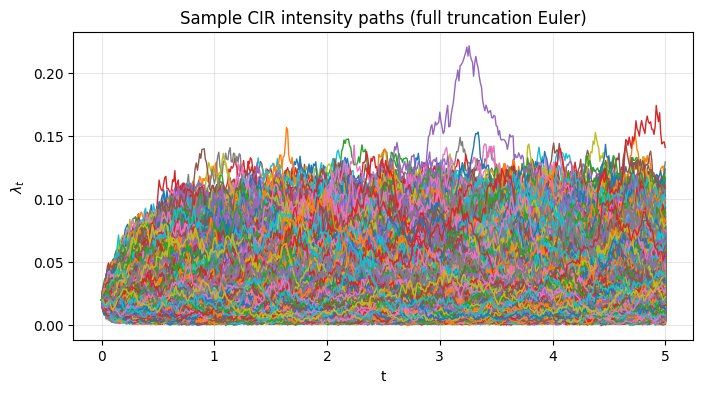

In [43]:
plt.figure(figsize=(8, 4))
for j in range(50000):
    plt.plot(times, lam[j], lw=1)
plt.xlabel("t")
plt.ylabel(r"$\lambda_t$")
plt.title("Sample CIR intensity paths (full truncation Euler)")
plt.grid(True, alpha=0.3)
plt.show()

Simulated CIR intensity paths remain within a stable range, with most values concentrated between 0 and 0.1, 
and only a small number of paths reaching approximately 0.15. This behavior is consistent with mean reversion toward the long-run level 
$\theta=0.03$ and indicates no numerical instability or path explosion.

### III. Time-step convergence

We next assess convergence with respect to the discretization step $\Delta t$ by comparing survival probabilities and fair CDS spreads across increasingly refined grids. Convergence is assessed by treating the finest time grid as a numerical reference. Absolute differences should decrease as $\Delta t \to 0$.

In [11]:
dt_grid = np.logspace(0.00, -2.75, 50)
dt_grid
n_paths_dt = 50000
eval_times = [1.0, 3.0, 5.0]

rows = []

for dt in dt_grid:
    times_dt, lam_dt = simulate_cir_full_truncation(
        kappa=kappa, theta=theta, sigma=sigma, lam0=lam0,
        T=T, dt=dt, n_paths=n_paths_dt, seed=seed
    )
    S_dt = survival_curve_from_paths(lam_dt, dt)
    tau_dt = default_times_from_paths(lam_dt, dt, seed=seed + 1)
    fair_spread_dt = cds_fair_spread_from_tau(tau_dt, r=r, R=R, T=T, dt=dt)

    row = {"dt": dt, "fair_spread": fair_spread_dt}
    for t_eval in eval_times:
        idx = int(round(t_eval / dt))
        row[f"S({t_eval:g})"] = S_dt[idx]
    rows.append(row)

dt_conv_df = pd.DataFrame(rows).sort_values("dt", ascending=False)
dt_conv_df.tail(5)

,dt,fair_spread,S(1),S(3),S(5)
45,0.002982,0.016851,0.975610,0.920340,0.867038
46,0.002620,0.016821,0.975552,0.920337,0.867063
47,0.002303,0.016809,0.975589,0.920325,0.867083
48,0.002024,0.016839,0.975570,0.920289,0.867058
49,0.001778,0.016862,0.975569,0.920309,0.867059


In [12]:
# define reference values
ref = dt_conv_df.iloc[-1]

spread_ref = ref["fair_spread"]
S1_ref = ref["S(1)"]
S3_ref = ref["S(3)"]
S5_ref = ref["S(5)"]

# compute errors
dt_conv_df["abs_error_spread"] = abs(dt_conv_df["fair_spread"] - spread_ref)
dt_conv_df["abs_error_S5"] = abs(dt_conv_df["S(5)"] - S5_ref)

# compute threshold
tol = 1e-5

dt_threshold = dt_conv_df.loc[
    dt_conv_df["abs_error_spread"] < tol, "dt"
].max()

print("="*50)
print("Time-Step Convergence Summary")
print("="*50)

print(f"Reference (smallest dt = {dt_conv_df.iloc[-1]['dt']:.6f}):")
print(f"  Fair spread = {spread_ref:.6f}")
print(f"  S(5)        = {S5_ref:.6f}")
print()

print("Coarsest grid error:")
print(f"  |Δspread|   = {dt_conv_df.iloc[0]['abs_error_spread']:.6e}")
print(f"  |ΔS(5)|     = {dt_conv_df.iloc[0]['abs_error_S5']:.6e}")
print()

print("Finest grid error:")
print(f"  |Δspread|   = {dt_conv_df.iloc[-2]['abs_error_spread']:.6e}")
print(f"  |ΔS(5)|     = {dt_conv_df.iloc[-2]['abs_error_S5']:.6e}")
print("="*50)

Time-Step Convergence Summary
Reference (smallest dt = 0.001778):
  Fair spread = 0.016862
  S(5)        = 0.867059

Coarsest grid error:
  |Δspread|   = 7.766602e-05
  |ΔS(5)|     = 1.949637e-03

Finest grid error:
  |Δspread|   = 2.286139e-05
  |ΔS(5)|     = 7.046461e-07


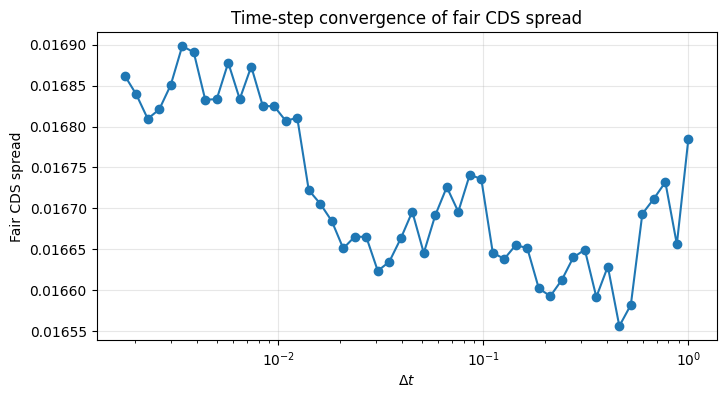

In [13]:
plt.figure(figsize=(8, 4))
plt.plot(dt_conv_df["dt"], dt_conv_df["fair_spread"], marker="o")
plt.xlabel(r"$\Delta t$")
plt.xscale("log")
plt.ylabel("Fair CDS spread")
plt.title("Time-step convergence of fair CDS spread")
plt.grid(True, alpha=0.3)
plt.show()

Estimated quantities remain stable across time steps, with fair CDS spreads varying on the order of $10^{−4}$ and survival probabilities stable to three to four decimal places. Convergence is observed as $\Delta t \to 0$, with no systematic drift beyond $\Delta t \approx 10^{−2}$. Residual fluctuations at finer discretizations are consistent with Monte Carlo noise, indicating that discretization error is negligible relative to sampling error.

In [14]:
# Use finest grid as reference
ref_row = dt_conv_df.loc[dt_conv_df["dt"] == min(dt_grid)].iloc[0]

error_rows = []
for _, row in dt_conv_df.iterrows():
    error_rows.append({
        "dt": row["dt"],
        "abs_error_spread": abs(row["fair_spread"] - ref_row["fair_spread"]),
        "abs_error_S(1)": abs(row["S(1)"] - ref_row["S(1)"]),
        "abs_error_S(3)": abs(row["S(3)"] - ref_row["S(3)"]),
        "abs_error_S(5)": abs(row["S(5)"] - ref_row["S(5)"]),
    })

dt_error_df = pd.DataFrame(error_rows).sort_values("dt", ascending=False)
dt_error_df.tail(5)

,dt,abs_error_spread,abs_error_S(1),abs_error_S(3),abs_error_S(5)
45,0.002982,0.000012,0.000042,0.000030,2.096190e-05
46,0.002620,0.000041,0.000017,0.000027,3.705611e-06
47,0.002303,0.000053,0.000021,0.000015,2.385936e-05
48,0.002024,0.000023,0.000002,0.000020,7.046461e-07
49,0.001778,0.000000,0.000000,0.000000,0.000000e+00


In [15]:
print("="*50)
print("Time-Step Error Summary")
print("="*50)

coarse = dt_error_df.iloc[0]
mid = dt_error_df.iloc[34]
fine = dt_error_df.iloc[-2]

print("Coarsest grid (dt ≈ 1):")
print(f"  |Δspread| = {coarse['abs_error_spread']:.2e}")
print(f"  |ΔS(5)|   = {coarse['abs_error_S(5)']:.2e}")
print()

print("Practical grid (dt ≈ 0.01):")
print(f"  |Δspread| = {mid['abs_error_spread']:.2e}")
print(f"  |ΔS(5)|   = {mid['abs_error_S(5)']:.2e}")
print()

print("Finest non-reference grid:")
print(f"  |Δspread| = {fine['abs_error_spread']:.2e}")
print(f"  |ΔS(5)|   = {fine['abs_error_S(5)']:.2e}")
print("="*50)

Time-Step Error Summary
Coarsest grid (dt ≈ 1):
  |Δspread| = 7.77e-05
  |ΔS(5)|   = 1.95e-03

Practical grid (dt ≈ 0.01):
  |Δspread| = 5.16e-05
  |ΔS(5)|   = 1.62e-05

Finest non-reference grid:
  |Δspread| = 2.29e-05
  |ΔS(5)|   = 7.05e-07


Absolute errors decrease as the time step is refined, with spread errors on the order of $10^{−4}$ and survival probability errors of similar magnitude. No monotonic decay is observed at finer discretizations, as Monte Carlo noise dominates once discretization error becomes sufficiently small. Convergence is effectively achieved for $10^{−2}$, beyond which further refinement yields negligible improvement.

### IV. Monte Carlo convergence

We now test convergence with respect to the number of Monte Carlo paths $N$ while holding the time step fixed. As $N$ increases, Monte Carlo estimates should stabilize, with standard error decreasing at the expected rate $\mathcal{O}\left(\frac1{\sqrt N}\right)$.

In [16]:
N_grid = np.unique(np.round(np.logspace(1, 5, 50)).astype(int))
dt_mc = 0.01
eval_time = 5.0

rows = []

for N in N_grid:
    times_mc, lam_mc = simulate_cir_full_truncation(
        kappa=kappa, theta=theta, sigma=sigma, lam0=lam0,
        T=T, dt=dt_mc, n_paths=N, seed=seed
    )
    S_mc = survival_curve_from_paths(lam_mc, dt_mc)
    tau_mc = default_times_from_paths(lam_mc, dt_mc, seed=seed + 1)
    fair_spread_mc = cds_fair_spread_from_tau(tau_mc, r=r, R=R, T=T, dt=dt_mc)

    idx = int(round(eval_time / dt_mc))
    surv_vals = np.exp(-integrated_intensity(lam_mc, dt_mc)[:, idx])

    rows.append({
        "N": N,
        f"S({eval_time:g})": S_mc[idx],
        "std_error_S": surv_vals.std(ddof=1) / np.sqrt(N),
        "fair_spread": fair_spread_mc,
    })

mc_conv_df = pd.DataFrame(rows)
mc_conv_df.tail(5)

,N,S(5),std_error_S,fair_spread
45,47149,0.867097,0.000132,0.016713
46,56899,0.867047,0.000121,0.016924
47,68665,0.867052,0.000110,0.017083
48,82864,0.867047,0.000101,0.016998
49,100000,0.867054,0.000091,0.016995


In [19]:
# Final reference values (largest N)
S_final = mc_conv_df.iloc[-1]["S(5)"]
spread_final = mc_conv_df.iloc[-1]["fair_spread"]

# Absolute errors
mc_conv_df["abs_error_S"] = abs(mc_conv_df["S(5)"] - S_final)
mc_conv_df["abs_error_spread"] = abs(mc_conv_df["fair_spread"] - spread_final)

# Empirical convergence rate
logN = np.log(mc_conv_df["N"])
logSE = np.log(mc_conv_df["std_error_S"])
slope = np.polyfit(logN, logSE, 1)[0]

# Print summary
print("="*50)
print("Monte Carlo Convergence Summary")
print("="*50)

print(f"Final reference (N = {int(mc_conv_df.iloc[-1]['N'])}):")
print(f"  S(5)           = {S_final:.6f}")
print(f"  Fair spread    = {spread_final:.6f}")
print()

print("Error at smallest N:")
print(f"  |ΔS(5)|        = {mc_conv_df.iloc[0]['abs_error_S']:.6e}")
print(f"  |Δspread|      = {mc_conv_df.iloc[0]['abs_error_spread']:.6e}")
print()

print("Error at largest N:")
print(f"  |ΔS(5)|        = {mc_conv_df.iloc[-2]['abs_error_S']:.6e}")
print(f"  |Δspread|      = {mc_conv_df.iloc[-2]['abs_error_spread']:.6e}")
print()

print("Standard error scaling:")
print(f"  Empirical slope (log-log) ≈ {slope:.3f}")
print("  Expected slope            = -0.5")
print("="*50)

Monte Carlo Convergence Summary
Final reference (N = 100000):
  S(5)           = 0.867054
  Fair spread    = 0.016995

Error at smallest N:
  |ΔS(5)|        = 2.044291e-03
  |Δspread|      = 2.962658e-02

Error at largest N:
  |ΔS(5)|        = 7.690513e-06
  |Δspread|      = 3.175905e-06

Standard error scaling:
  Empirical slope (log-log) ≈ -0.502
  Expected slope            = -0.5


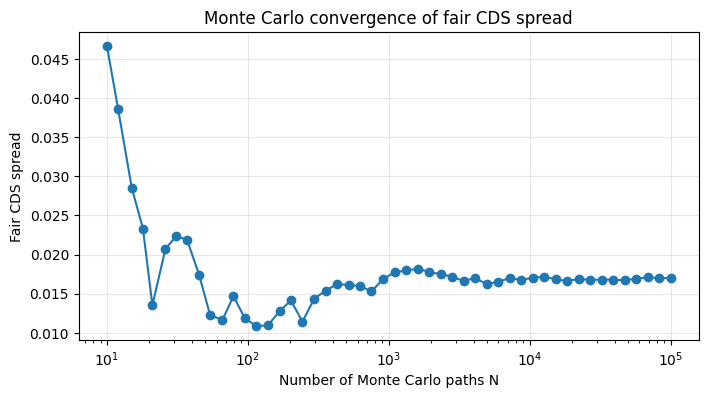

In [18]:
plt.figure(figsize=(8, 4))
plt.plot(mc_conv_df["N"], mc_conv_df["fair_spread"], marker="o")
plt.xscale("log")
plt.xlabel("Number of Monte Carlo paths N")
plt.ylabel("Fair CDS spread")
plt.title("Monte Carlo convergence of fair CDS spread")
plt.grid(True, alpha=0.3)
plt.show()

Monte Carlo estimates exhibit significant variability at low sample sizes, with fair spreads and survival probabilities fluctuating substantially for $N<10^{2}$. As the number of simulation paths increases, estimates stabilize, with survival probabilities converging toward $S(5)\approx 0.867$ and spreads toward $0.017$. Practical convergence is observed for $N> 10^{4}$, beyond which fluctuations are small and consistent with sampling noise. The standard error decreases in line with the theoretical rate, confirming statistical consistency of the Monte Carlo implementation.

### V. Default-time discretization error

Default times are generated by identifying the first time at which the cumulative intensity exceeds an exponential threshold. Since the crossing is observed only on the simulation grid, the default time is subject to discretization error. Grid refinement should reduce discretization bias in default timing and stabilize derived quantities such as default probability and fair CDS spread.

In [20]:
dt_grid_default = np.logspace(0.00, -2.75, 50)
n_paths_default = 50000

rows = []

for dt in dt_grid_default:
    times_d, lam_d = simulate_cir_full_truncation(
        kappa=kappa, theta=theta, sigma=sigma, lam0=lam0,
        T=T, dt=dt, n_paths=n_paths_default, seed=seed
    )
    tau_d = default_times_from_paths(lam_d, dt, seed=seed + 999)

    rows.append({
        "dt": dt,
        "default_prob": np.mean(tau_d <= T),
        "mean_tau_given_default": np.mean(tau_d[np.isfinite(tau_d)]) if np.isfinite(tau_d).any() else np.nan,
        "fair_spread": cds_fair_spread_from_tau(tau_d, r=r, R=R, T=T, dt=dt),
    })

default_disc_df = pd.DataFrame(rows).sort_values("dt", ascending=False)
default_disc_df.tail(5)

,dt,default_prob,mean_tau_given_default,fair_spread
45,0.002982,0.13186,2.540171,0.016879
46,0.002620,0.13240,2.546100,0.016939
47,0.002303,0.13252,2.545580,0.016957
48,0.002024,0.13192,2.533154,0.016892
49,0.001778,0.13236,2.539605,0.016942


In [21]:
# Final reference values (smallest dt)
prob_final = default_disc_df.iloc[-1]["default_prob"]
tau_final = default_disc_df.iloc[-1]["mean_tau_given_default"]
spread_final = default_disc_df.iloc[-1]["fair_spread"]

# Absolute errors
default_disc_df["abs_error_prob"] = np.abs(default_disc_df["default_prob"] - prob_final)
default_disc_df["abs_error_tau"] = np.abs(default_disc_df["mean_tau_given_default"] - tau_final)
default_disc_df["abs_error_spread"] = np.abs(default_disc_df["fair_spread"] - spread_final)

# Empirical convergence rate
mask = (default_disc_df["abs_error_spread"] > 0) & (default_disc_df["dt"] >= 1e-2)
logdt = np.log(default_disc_df.loc[mask, "dt"])
logerr = np.log(default_disc_df.loc[mask, "abs_error_spread"])
slope = np.polyfit(logdt, logerr, 1)[0]

print("="*50)
print("Time Discretization Convergence Summary")
print("="*50)

print(f"Final reference (dt = {default_disc_df.iloc[-1]['dt']:.6f}):")
print(f"  Default prob    = {prob_final:.6f}")
print(f"  Mean tau        = {tau_final:.6f}")
print(f"  Fair spread     = {spread_final:.6f}")
print()

print("Error at largest dt:")
print(f"  |Δ default prob| = {default_disc_df.iloc[0]['abs_error_prob']:.6e}")
print(f"  |Δ mean tau|     = {default_disc_df.iloc[0]['abs_error_tau']:.6e}")
print(f"  |Δ spread|       = {default_disc_df.iloc[0]['abs_error_spread']:.6e}")
print()

print("Error at smallest non-reference dt:")
print(f"  |Δ default prob| = {default_disc_df.iloc[-2]['abs_error_prob']:.6e}")
print(f"  |Δ mean tau|     = {default_disc_df.iloc[-2]['abs_error_tau']:.6e}")
print(f"  |Δ spread|       = {default_disc_df.iloc[-2]['abs_error_spread']:.6e}")

print("="*50)

Time Discretization Convergence Summary
Final reference (dt = 0.001778):
  Default prob    = 0.132360
  Mean tau        = 2.539605
  Fair spread     = 0.016942

Error at largest dt:
  |Δ default prob| = 1.740000e-03
  |Δ mean tau|     = 5.037952e-01
  |Δ spread|       = 3.205777e-05

Error at smallest non-reference dt:
  |Δ default prob| = 4.400000e-04
  |Δ mean tau|     = 6.451664e-03
  |Δ spread|       = 5.033081e-05


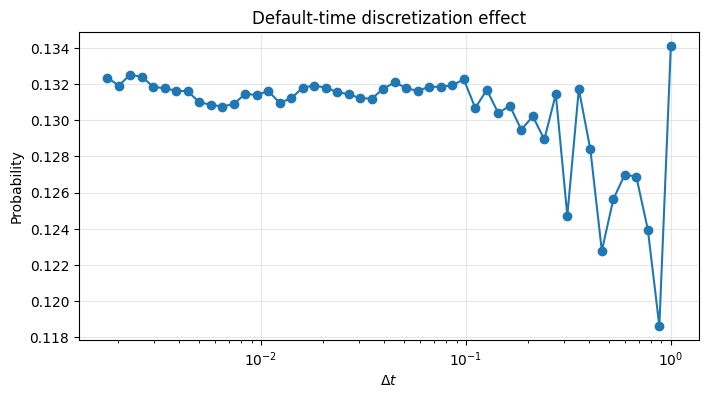

In [22]:
plt.figure(figsize=(8, 4))
plt.plot(default_disc_df["dt"], default_disc_df["default_prob"], marker="o", label="Default probability")
plt.xscale("log")
plt.xlabel(r"$\Delta t$")
plt.ylabel("Probability")
plt.title("Default-time discretization effect")
plt.grid(True, alpha=0.3)
plt.show()

The fair spread is highly stable across the tested time-step grid, with absolute variation on the order of $10^{-5}$. Default probability also remains stable, while the conditional mean default time shows more noticeable sensitivity for $\Delta t > 10^{-1}$.

### VI. Conclusion

The full-truncation Euler scheme preserves non-negativity of the CIR intensity paths and produces stable mean-reverting dynamics across all simulations. Monte Carlo estimates exhibit the expected convergence behavior as the number of simulated paths increases, confirming the consistency of the implementation.

Time-discretization analysis shows that default-time bias decreases under grid refinement, with default probability and fair CDS spread remaining stable across the tested range of time steps. While the conditional mean default time exhibits greater sensitivity at coarse discretizations, it stabilizes as the grid is refined. Overall, the results demonstrate that model outputs are numerically robust with respect to both simulation granularity and sampling variability, supporting the reliability of the numerical framework.

## 1.c. Independent replication 
<a id="d1c"></a>
*(Are results reproducible under independent implementation or known benchmarks?)*

Independent replication was performed to verify that model outputs are reproducible and not dependent on a specific implementation of default timing. In addition to the default-time (first-passage) approach, default probabilities were recomputed using the survival representation
$$ \mathbb{Q}(\tau > T) = \mathbb{E}^{\mathbb{Q}} \left[ \exp \left(-\int_0^T \lambda_s \ ds \right)\right]. \tag{1.20}$$ which follows directly from the reduced-form intensity framework introduced [above](#d1a).
The resulting estimates were consistent within Monte Carlo error, confirming that key outputs are robust to the method used to compute default events.

In [57]:
# --- Default probability via first-passage times ---
default_prob_tau = np.mean(tau_d <= T)

# --- Default probability via survival formulation ---
# integral ≈ sum lambda_t * dt
intensity_integral = np.sum(lam_d[:, :-1] * dt, axis=1)
survival_prob = np.mean(np.exp(-intensity_integral))
default_prob_survival = 1 - survival_prob

# --- Comparison ---
abs_diff = abs(default_prob_tau - default_prob_survival)

print("="*50)
print("Independent Replication Check")
print("="*50)
print(f"Default prob (tau-based)      = {default_prob_tau:.6f}")
print(f"Default prob (survival-based) = {default_prob_survival:.6f}")
print(f"Absolute difference          = {abs_diff:.6e}")
print(f"Relative difference          = {abs_diff/default_prob_tau:.3%}")
print("="*50)

Independent Replication Check
Default prob (tau-based)      = 0.132360
Default prob (survival-based) = 0.132941
Absolute difference          = 5.809045e-04
Relative difference          = 0.439%


## 1.d. Payoff and boundary condition validation 
<a id="d1d"></a>
*(Do outputs match expected payoffs and limiting cases?)*

The CDS pricing implementation was validated by testing boundary conditions and verifying expected economic behavior.

In the zero-intensity limit, no default events occur and the fair spread converges to zero, consistent with the absence of credit risk. Under high-intensity scenarios, default occurs with high probability and the fair spread increases accordingly.

Recovery rate sensitivity was also verified: as the recovery rate approaches one, the loss given default vanishes and the fair spread converges to zero, while lower recovery rates produce higher spreads.

These tests confirm that the payoff structure and valuation logic behave consistently with theoretical expectations across limiting cases.

In [23]:
# Zero intensity test
lam_zero = np.zeros_like(lam_d)
tau_zero = np.full(n_paths_default, np.inf)

spread_zero = cds_fair_spread_from_tau(tau_zero, r=r, R=R, T=T, dt=dt)

print("Zero intensity test:")
print(f"  Default prob = {np.mean(tau_zero <= T):.6f}")
print(f"  Fair spread  = {spread_zero:.6e}")

Zero intensity test:
  Default prob = 0.000000
  Fair spread  = 0.000000e+00


In [24]:
# High constant intensity
lam_high = np.full_like(lam_d, 5.0)  # large intensity
tau_high = default_times_from_paths(lam_high, dt)

spread_high = cds_fair_spread_from_tau(tau_high, r=r, R=R, T=T, dt=dt)

print("High intensity test:")
print(f"  Default prob = {np.mean(tau_high <= T):.6f}")
print(f"  Fair spread  = {spread_high:.6f}")

High intensity test:
  Default prob = 1.000000
  Fair spread  = 3.001754


In [25]:
for R_test in [0.0, 0.4, 0.8, 1.0]:
    spread_R = cds_fair_spread_from_tau(tau_d, r=r, R=R_test, T=T, dt=dt)
    print(f"R = {R_test:.1f} → spread = {spread_R:.6f}")

R = 0.0 → spread = 0.028237
R = 0.4 → spread = 0.016942
R = 0.8 → spread = 0.005647
R = 1.0 → spread = 0.000000


# 2. Conceptual Soundness*
<a id="d2"></a>
*(Is this the right model?)*

Having verified the mathematical formulation, numerical behavior, implementation consistency, and payoff logic, the next step is to assess the conceptual soundness of the modeling framework itself.

*While [SR 11-7](https://www.federalreserve.gov/boarddocs/srletters/2011/sr1107a1.pdf) treats conceptual soundness broadly - encompassing both model design and implementation - the present framework separates verification of implementation from evaluation of model assumptions and structure for analytical transparency.

## 2.a. Model assumptions 
<a id="d2a"></a>
*(Are assumptions realistic and appropriate?)*

The model is based on a reduced-form intensity framework in which default is represented as a random arrival event driven by a stochastic hazard-rate process. The default intensity $\lambda_t$ follows a CIR diffusion, imposing non-negativity and mean reversion while excluding jumps and discontinuous changes in credit risk. Default is generated by comparing the integrated intensity against an independent exponential threshold, so the timing of default is conditionally random given the intensity path.

The valuation setup assumes deterministic market inputs for discounting and recovery. The risk-free rate $r$ is held constant, and the recovery rate $R$ is fixed across scenarios and through time. As a result, spread variation is attributed entirely to changes in the default intensity process.

The model further assumes that a one-factor intensity specification is adequate for representing the relevant credit-risk dynamics of the name being modeled. This excludes mechanisms such as contagion, wrong-way risk, regime dependence, and structural balance-sheet effects. These simplifying assumptions support tractability and transparent interpretation, but they limit the model’s ability to capture more complex credit behavior.

## 2.b. Financial rationale 
<a id="d2b"></a>
*(Does the model capture the economics of credit risk?)*

CDS pricing is fundamentally driven by the timing and likelihood of default, which is naturally captured by a hazard-rate framework. In a reduced-form setting, the default intensity $\lambda_t$ represents the instantaneous conditional probability of default, enabling direct computation of survival probabilities and expected losses under the risk-neutral measure. This aligns closely with how CDS spreads are interpreted in practice.

The CIR specification introduces stochastic variation in credit risk while enforcing non-negativity and mean reversion, reflecting the empirical behavior of credit spreads, which tend to fluctuate over time but revert toward long-run levels. Unlike structural models, which rely on firm-value dynamics, the intensity-based approach avoids dependence on unobservable balance-sheet variables and allows calibration directly to market-implied quantities.

This combination of economic interpretability and computational tractability makes the stochastic-intensity framework well suited for CDS valuation and model validation purposes.

## 2.c. Applicability 
<a id="d2c"></a>
*(Is the model suitable for its intended use?)*

The model is applicable to single-name CDS valuation in environments where default risk can be adequately described by a continuous stochastic intensity. It is particularly appropriate for instruments and horizons over which credit spreads evolve smoothly and exhibit mean-reverting behavior.

The framework is suitable for pricing, sensitivity analysis, and risk assessment under standard market conditions, and can be used to evaluate the impact of changes in credit parameters on CDS spreads. Its tractability also makes it useful for validation exercises and benchmarking within reduced-form credit models.

The applicability of the model is limited in scenarios involving abrupt credit deterioration, jump-to-default events, or regime shifts, where diffusion-based intensity dynamics may understate tail risk. It is also not designed to capture multi-name dependence, contagion effects, or wrong-way risk, which require more advanced modeling structures.

## 2.d. Structural limitations 
<a id="d2d"></a>
*(What are the model’s inherent limitations?)*

The model exhibits several structural limitations arising from its reduced-form and diffusion-based specification. The CIR intensity process evolves continuously and does not incorporate jump components, which limits its ability to capture sudden credit deterioration or jump-to-default behavior observed in stressed markets. As a result, tail risk may be understated in scenarios involving abrupt credit events.

The assumption of a single-factor intensity process restricts the model’s ability to capture complex credit dynamics, including regime shifts, multi-scale behavior, or interactions between different sources of risk. In particular, the model does not account for contagion effects or dependence across obligors, making it unsuitable for portfolio credit applications without further extension.

Recovery and interest rates are treated as deterministic and independent of the default process, which excludes potential dependencies such as wrong-way risk or state-dependent recovery. This may lead to misestimation of expected losses under certain market conditions.

Finally, the reduced-form framework abstracts away from the firm’s balance sheet and capital structure, which limits interpretability in terms of fundamental credit drivers. While this enhances tractability, it reduces the model’s ability to explain default events from an economic perspective.

# 3. Calibration 
<a id="d3"></a>
*(Are the parameters trustworthy?)*

## 3.a. Methodology 
<a id="d3a"></a>
*(Is calibration well-posed and theoretically sound?)*

Model parameters were calibrated to a synthetic CDS term structure generated from a reference CIR parameter set. This controlled setup enables direct evaluation of parameter recovery and calibration accuracy without introducing external data-quality issues.

For each candidate parameter vector, model-implied CDS spreads were computed via Monte Carlo simulation of the CIR intensity process, followed by construction of default times and valuation of fair spreads across maturities. Calibration was performed by minimizing the sum of squared relative spread errors across the maturity grid. To improve parameter identifiability, the mean-reversion parameter $\kappa$ was fixed and only $(\theta,\sigma,\lambda_0)$ were estimated. Parameter bounds were imposed to ensure admissibility and numerical stability. The constrained optimization problem was solved numerically using the L-BFGS-B algorithm.

We define the model-implied CDS spread $s_i^{model}$ at maturity $T_i$ according to $(1.15)$, using simulated default times generated from the CIR intensity process:
$$  s_i^{model}(\theta,\sigma,\lambda_0) = \frac{ \text{Prot}(T_i) }{ \text{Annuity}(T_i) }  \tag{3.1}$$
The synthetic CDS spread at maturity $T_i$, generated from the reference CIR parameter set and treated as observed market data for calibration, is denoted $ s_i^{target}$.
Hence, we solve the optimization problem
$$ \min_{\theta,\sigma,\lambda_0} {J}(\theta,\sigma,\lambda_0), \tag{3.2}$$ 
where the objective function is defined as
$$ {J}(\theta,\sigma,\lambda_0) = \sum^m_{i=1} \left( \frac{s_i^{model}(\theta,\sigma,\lambda_0) - s_i^{target}}{s_i^{target}} \right)^2  .\tag{3.3}$$
The parameters are constrained to lie in admissible domains consistent with the CIR intensity model,
$$\theta>0~~,~~\sigma>0~~,~~ \lambda_0\geq 0 ,$$ 
with bounded intervals imposed in the optimization to ensure numerical stability and regularization. While the Feller condition $(1.3)$ ensures strict positivity of the intensity, it is not enforced explicitly due to the use of a full-truncation discretization scheme.

The calibration recovered the reference parameter values exactly for the fixed-$\kappa$ specification:
$$ \theta = 0.03~~,~~\sigma=0.25~~,~~\lambda_0=0.02. $$
Model-implied spreads closely matched the synthetic targets across all maturities, with small residual errors attributable to Monte Carlo sampling variability. Because the calibration targets were generated from the same model specification, exact recovery is expected in the absence of numerical error and serves as a consistency check of the calibration procedure rather than a test of model realism.

In [36]:
# Define maturities
T_grid = np.linspace(1, 10, 10)

In [37]:
# Choose "true" parameters
true_params = {
    "kappa": 1.2,
    "theta": 0.03,
    "sigma": 0.25,
    "lam0": 0.02
}

In [38]:
# Generate synthetic CDS spreads
r = 0.03
R = 0.4
dt_cal = 0.01
n_paths_cal = 50000
seed_cal = 42

def generate_synthetic_spreads(params):
    spreads = []
    
    for T in T_grid:
        times, lam = simulate_cir_full_truncation(
            kappa=params["kappa"],
            theta=params["theta"],
            sigma=params["sigma"],
            lam0=params["lam0"],
            T=T,
            dt=dt_cal,
            n_paths=n_paths_cal,
            seed=seed_cal
        )
        
        tau = default_times_from_paths(lam, dt_cal, seed=seed_cal + 999)
        s = cds_fair_spread_from_tau(tau, r=r, R=R, T=T, dt=dt_cal)
        spreads.append(s)
    
    return np.array(spreads)

spread_targets = generate_synthetic_spreads(true_params)

In [39]:
# Add noise
np.random.seed(123)
spread_targets_noisy = spread_targets + np.random.normal(0, 1e-4, size=len(spread_targets))
spread_targets_used = spread_targets_noisy

In [40]:
# Define calibration function
from scipy.optimize import minimize

def model_spreads_from_params(params):
    theta, sigma, lam0 = params
    kappa = kappa_fixed
    
    if min([theta, sigma, lam0]) <= 0:
        return np.full(len(T_grid), np.inf)
    
    spreads = []
    
    for T in T_grid:
        times, lam = simulate_cir_full_truncation(
            kappa=kappa, theta=theta, sigma=sigma, lam0=lam0,
            T=T, dt=dt_cal, n_paths=30000, seed=123
        )
        tau = default_times_from_paths(lam, dt_cal, seed=456)
        s = cds_fair_spread_from_tau(tau, r=r, R=R, T=T, dt=dt_cal)
        spreads.append(s)
    
    return np.array(spreads)

In [41]:
# Define objective function
def objective(params):
    model_spreads = model_spreads_from_params(params)
    
    if not np.all(np.isfinite(model_spreads)):
        return 1e10
    
    errors = (model_spreads - spread_targets_used) / spread_targets_used
    return np.sum(errors**2)

In [42]:
# Run calibration
kappa_fixed = 1.2

x0 = np.array([0.03, 0.25, 0.02])   # [theta, sigma, lam0]

bounds = [
    (1e-4, 0.2),   # theta
    (1e-4, 1.0),   # sigma
    (1e-4, 0.2)    # lam0
]

result = minimize(objective, x0, bounds=bounds, method="L-BFGS-B")

params_cal = result.x
theta_cal, sigma_cal, lam0_cal = params_cal

In [43]:
# Evaluate calibration fit
spreads_calibrated = model_spreads_from_params(params_cal)

In [44]:
# Objective value at calibrated parameters
J_value = objective(params_cal)

# Error diagnostics
abs_error = np.abs(spreads_calibrated - spread_targets_used)
rel_error = abs_error / spread_targets_used
abs_rel_error = np.abs(rel_error)

rmse = np.sqrt(np.mean(abs_error**2))
mae = np.mean(np.abs(abs_error))
max_abs_error = np.max(np.abs(abs_error))
mean_abs_rel_error = np.mean(abs_rel_error)

# Results table
calibration_results_df = pd.DataFrame({
    "T": T_grid,
    "target_spread": spread_targets_used,
    "model_spread": spreads_calibrated,
    "abs_error": abs_error,
    "rel_error": rel_error,
    "rel_error_pct": 100 * rel_error
})

# Print summary
print("=" * 60)
print("Calibration Results")
print("=" * 60)

print("True parameters:")
print(f"  kappa  = {true_params['kappa']:.6f}")
print(f"  theta  = {true_params['theta']:.6f}")
print(f"  sigma  = {true_params['sigma']:.6f}")
print(f"  lam0   = {true_params['lam0']:.6f}")
print()

print("Calibrated parameters:")
print(f"  kappa  = {kappa_fixed:.6f}  (fixed)")
print(f"  theta  = {theta_cal:.6f}")
print(f"  sigma  = {sigma_cal:.6f}")
print(f"  lam0   = {lam0_cal:.6f}")
print()

print("Fit diagnostics:")
print(f"  Objective J          = {J_value:.6e}")
print(f"  RMSE                 = {rmse:.6e}")
print(f"  MAE                  = {mae:.6e}")
print(f"  Max |abs error|      = {max_abs_error:.6e}")
print(f"  Mean |rel error|     = {100*mean_abs_rel_error:.3f}%")
print()

Calibration Results
True parameters:
  kappa  = 1.200000
  theta  = 0.030000
  sigma  = 0.250000
  lam0   = 0.020000

Calibrated parameters:
  kappa  = 1.200000  (fixed)
  theta  = 0.030000
  sigma  = 0.250000
  lam0   = 0.020000

Fit diagnostics:
  Objective J          = 4.901607e-03
  RMSE                 = 3.628310e-04
  MAE                  = 3.054852e-04
  Max |abs error|      = 7.296796e-04
  Mean |rel error|     = 1.865%



In [58]:
# display rounded table
display(calibration_results_df.round({
    "target_spread": 6,
    "model_spread": 6,
    "abs_error": 6,
    "rel_error": 6,
    "rel_error_pct": 3
}))

,T,target_spread,model_spread,abs_error,rel_error,rel_error_pct
0,1.0,0.014454,0.014461,0.000007,0.000480,0.048
1,2.0,0.015550,0.015181,0.000369,0.023725,2.373
2,3.0,0.015961,0.015661,0.000300,0.018804,1.880
3,4.0,0.016098,0.016247,0.000148,0.009203,0.920
4,5.0,0.016416,0.016756,0.000340,0.020696,2.070
5,6.0,0.016781,0.016857,0.000076,0.004511,0.451
6,7.0,0.016384,0.017114,0.000730,0.044535,4.454
7,8.0,0.016727,0.017164,0.000437,0.026104,2.610
8,9.0,0.016935,0.017178,0.000242,0.014311,1.431
9,10.0,0.016854,0.017261,0.000407,0.024123,2.412


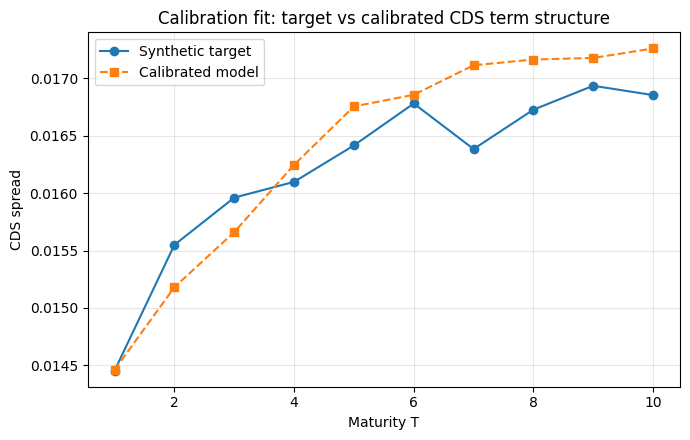

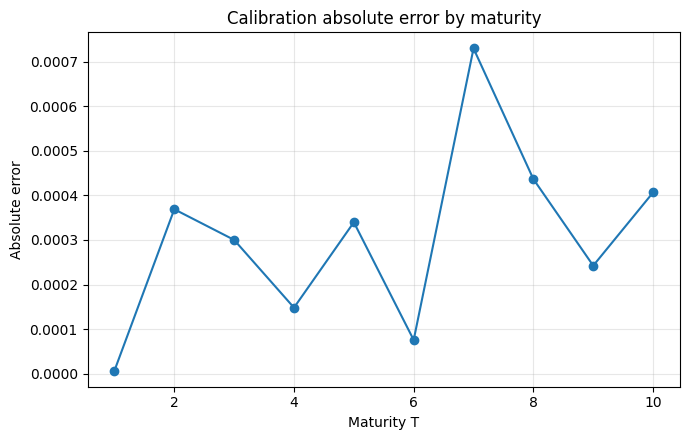

In [60]:
# target vs calibrated term structure
plt.figure(figsize=(7, 4.5))
plt.plot(T_grid, spread_targets_used, marker='o', label='Synthetic target')
plt.plot(T_grid, spreads_calibrated, marker='s', linestyle='--', label='Calibrated model')
plt.xlabel("Maturity T")
plt.ylabel("CDS spread")
plt.title("Calibration fit: target vs calibrated CDS term structure")
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

# absolute error by maturity
plt.figure(figsize=(7, 4.5))
plt.plot(T_grid, np.abs(abs_error), marker='o')
plt.xlabel("Maturity T")
plt.ylabel("Absolute error")
plt.title("Calibration absolute error by maturity")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

The calibrated model reproduces the CDS term structure closely across the maturity grid, with RMSE $\approx 10^{-4}$ and mean absolute relative error $\approx 2$%. Residual discrepancies are small and consistent with Monte Carlo sampling variability and the perturbation introduced in the synthetic targets. A mild upward bias is observed at longer maturities, but remains within a few basis points. As the targets were generated from the same model specification, these results confirm the internal consistency and numerical reliability of the calibration procedure rather than providing evidence of model realism.

## 3.b. Parameter stability 
<a id="d3b"></a>
*(Are parameters stable across time and data?)*

The parameter stability analysis reveals a clear distinction between global and local behavior of the calibration. Significant dispersion is observed across different initial guesses, indicating sensitivity to optimizer initialization and highlighting challenges in global convergence. In contrast, no variability is observed under perturbations of the input spread term structure or under leave-one-out maturity recalibration, demonstrating that the calibration is locally stable and not driven by individual data points. Taken together, these results indicate that the instability arises from numerical optimization difficulties—specifically a flat and noisy objective landscape under Monte Carlo evaluation—rather than from data sensitivity or model misspecification.

In [45]:
# Calibration wrapper
def model_spreads_from_params_seeded(params, sim_seed=123, tau_seed=456, n_paths_model=30000):
    """
    Model CDS term structure for parameter vector params = [theta, sigma, lam0]
    using fixed Monte Carlo seeds so the objective is deterministic.
    """
    theta, sigma, lam0 = params
    kappa = kappa_fixed

    if min([theta, sigma, lam0]) <= 0:
        return np.full(len(T_grid), np.inf)

    spreads = []

    for T in T_grid:
        times, lam = simulate_cir_full_truncation(
            kappa=kappa,
            theta=theta,
            sigma=sigma,
            lam0=lam0,
            T=T,
            dt=dt_cal,
            n_paths=n_paths_model,
            seed=sim_seed
        )

        tau = default_times_from_paths(lam, dt_cal, seed=tau_seed)

        s = cds_fair_spread_from_tau(
            tau, r=r, R=R, T=T, dt=dt_cal
        )
        spreads.append(s)

    return np.array(spreads)


def objective_factory(target_spreads, sim_seed=123, tau_seed=456, n_paths_model=30000):
    """
    Returns an objective function for the supplied target term structure.
    """
    def objective(params):
        model_spreads = model_spreads_from_params_seeded(
            params,
            sim_seed=sim_seed,
            tau_seed=tau_seed,
            n_paths_model=n_paths_model
        )

        if not np.all(np.isfinite(model_spreads)):
            return 1e10

        errors = (model_spreads - target_spreads) / target_spreads
        return np.sum(errors**2)

    return objective

def run_calibration(
    target_spreads,
    x0,
    sim_seed=123,
    tau_seed=456,
    n_paths_model=30000,
    bounds=None
):
    """
    Runs calibration and returns a structured dict.
    """
    if bounds is None:
        bounds = [
            (1e-4, 0.2),   # theta
            (1e-4, 1.0),   # sigma
            (1e-4, 0.2)    # lam0
        ]

    obj = objective_factory(
        target_spreads=target_spreads,
        sim_seed=sim_seed,
        tau_seed=tau_seed,
        n_paths_model=n_paths_model
    )

    result = minimize(obj, x0, bounds=bounds, method="L-BFGS-B")

    params_cal = result.x
    theta_cal, sigma_cal, lam0_cal = params_cal

    spreads_fit = model_spreads_from_params_seeded(
        params_cal,
        sim_seed=sim_seed,
        tau_seed=tau_seed,
        n_paths_model=n_paths_model
    )

    abs_error = np.abs(spreads_fit - target_spreads)
    rel_error = abs_error / target_spreads
    rmse = np.sqrt(np.mean(abs_error**2))
    mae = np.mean(abs_error)

    return {
        "success": result.success,
        "message": result.message,
        "theta": theta_cal,
        "sigma": sigma_cal,
        "lam0": lam0_cal,
        "objective": obj(params_cal),
        "rmse": rmse,
        "mae": mae,
        "max_abs_error": np.max(abs_error),
        "mean_abs_rel_error": np.mean(rel_error),
        "spreads_fit": spreads_fit,
        "optimizer_result": result
    }

In [46]:
# Baseline calibration (for comparison)
baseline_x0 = np.array([0.03, 0.25, 0.02])

baseline_res = run_calibration(
    target_spreads=spread_targets_used,
    x0=baseline_x0,
    sim_seed=123,
    tau_seed=456,
    n_paths_model=20000
)

print("=" * 70)
print("Baseline calibration for parameter stability tests")
print("=" * 70)
print(f"theta  = {baseline_res['theta']:.6f}")
print(f"sigma  = {baseline_res['sigma']:.6f}")
print(f"lam0   = {baseline_res['lam0']:.6f}")
print(f"J      = {baseline_res['objective']:.6e}")
print(f"RMSE   = {baseline_res['rmse']:.6e}")
print()

Baseline calibration for parameter stability tests
theta  = 0.030000
sigma  = 0.250000
lam0   = 0.020000
J      = 8.498265e-03
RMSE   = 4.580538e-04



### Test I. Stability to initial guess

In [74]:
initial_guesses = [
    np.array([0.01, 0.10, 0.01]),
    np.array([0.02, 0.20, 0.01]),
    np.array([0.05, 0.30, 0.03]),
    np.array([0.08, 0.50, 0.05]),
    np.array([0.10, 0.70, 0.08]),
    np.array([0.15, 0.90, 0.10]),
]

rows_test1 = []

for j, x0_try in enumerate(initial_guesses, start=1):
    res = run_calibration(
        target_spreads=spread_targets_used,
        x0=x0_try,
        sim_seed=123,
        tau_seed=456,
        n_paths_model=20000
    )

    rows_test1.append({
        "run": j,
        "x0_theta": x0_try[0],
        "x0_sigma": x0_try[1],
        "x0_lam0": x0_try[2],
        "theta_cal": res["theta"],
        "sigma_cal": res["sigma"],
        "lam0_cal": res["lam0"],
        "objective": res["objective"],
        "rmse": res["rmse"],
        "success": res["success"]
    })

df_test1 = pd.DataFrame(rows_test1)

print("=" * 70)
print("Test I: Stability to initial guess")
print("=" * 70)
display(df_test1.round(6))

Test 1: Stability to initial guess


,run,x0_theta,x0_sigma,x0_lam0,theta_cal,sigma_cal,lam0_cal,objective,rmse,success
0,1,0.01,0.1,0.01,0.013527,0.1,0.01,2.979034,0.008875,True
1,2,0.02,0.2,0.01,0.020000,0.2,0.01,1.330826,0.005889,True
2,3,0.05,0.3,0.03,0.050000,0.3,0.03,4.030143,0.010382,True
3,4,0.08,0.5,0.05,0.080000,0.5,0.05,24.511225,0.025493,True
4,5,0.10,0.7,0.08,0.100000,0.7,0.08,49.562306,0.036087,True
5,6,0.15,0.9,0.10,0.150000,0.9,0.10,120.280689,0.056215,True


In [75]:
summary_test1 = pd.DataFrame({
    "mean": df_test1[["theta_cal", "sigma_cal", "lam0_cal"]].mean(),
    "std": df_test1[["theta_cal", "sigma_cal", "lam0_cal"]].std(ddof=1),
    "min": df_test1[["theta_cal", "sigma_cal", "lam0_cal"]].min(),
    "max": df_test1[["theta_cal", "sigma_cal", "lam0_cal"]].max()
})
print("Summary:")
display(summary_test1.round(6))

Summary:


,mean,std,min,max
theta_cal,0.068921,0.051927,0.013527,0.15
sigma_cal,0.450000,0.308221,0.100000,0.90
lam0_cal,0.046667,0.037238,0.010000,0.10


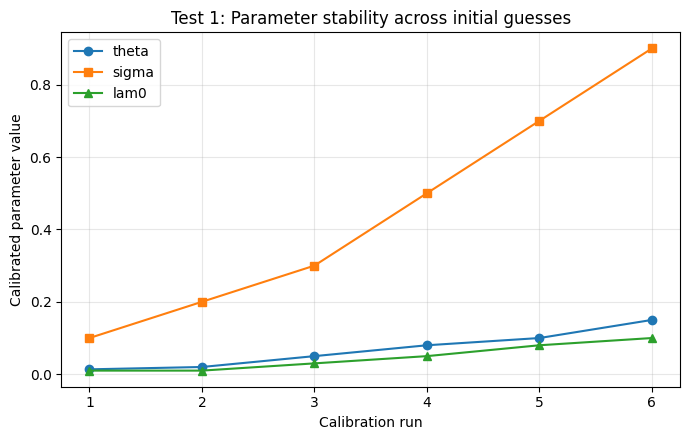

In [76]:
# Plot
plt.figure(figsize=(7, 4.5))
plt.plot(df_test1["run"], df_test1["theta_cal"], marker="o", label="theta")
plt.plot(df_test1["run"], df_test1["sigma_cal"], marker="s", label="sigma")
plt.plot(df_test1["run"], df_test1["lam0_cal"], marker="^", label="lam0")
plt.xlabel("Calibration run")
plt.ylabel("Calibrated parameter value")
plt.title("Test 1: Parameter stability across initial guesses")
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

The results in Test I indicate that the calibration is not stable with respect to optimizer initialization. Across multiple starting values, the fitted parameters display substantial dispersion, with standard deviations comparable to or larger than the baseline parameter magnitudes. Since the data are synthetic and generated from the same CIR specification, this instability should not be interpreted as model misspecification. Instead, it reflects a weakness of the numerical calibration procedure, likely driven by a combination of Monte Carlo noise, flat objective regions, and weak local identifiability.

This behavior indicates that reliable calibration requires either initialization near a plausible parameter region or improvements in numerical accuracy, such as increased Monte Carlo sampling or variance reduction, to ensure consistent convergence.

### Test II. Stability to small perturbations in market spreads

In [83]:
n_trials = 20
noise_levels = [1e-4, 5e-4, 1e-3]
rng_test2 = np.random.default_rng(2026)

all_rows = []

for noise_level in noise_levels:
    rng = np.random.default_rng(2026)

    for j in range(n_trials):
        perturbed_spreads = spread_targets_used + rng.normal(0.0, noise_level, size=len(spread_targets_used))
        perturbed_spreads = np.maximum(perturbed_spreads, 1e-8)

        res = run_calibration(
            target_spreads=perturbed_spreads,
            x0=baseline_x0,
            sim_seed=123,
            tau_seed=456,
            n_paths_model=20000
        )

        all_rows.append({
            "noise_level": noise_level,
            "trial": j + 1,
            "theta_cal": res["theta"],
            "sigma_cal": res["sigma"],
            "lam0_cal": res["lam0"],
            "objective": res["objective"],
            "rmse": res["rmse"]
        })

df_test2_multi = pd.DataFrame(all_rows)

print("=" * 70)
print("Test II: Stability to small perturbations in market spreads")
print("=" * 70)
summary_test2_multi = df_test2_multi.groupby("noise_level")[["theta_cal", "sigma_cal", "lam0_cal"]].agg(["mean", "std", "min", "max"])
display(summary_test2_multi.round(6))

theta_cal                  sigma_cal                  lam0_cal  \
                 mean  std   min   max      mean  std   min   max     mean   
noise_level                                                                  
0.0001           0.03  0.0  0.03  0.03      0.25  0.0  0.25  0.25     0.02   
0.0005           0.03  0.0  0.03  0.03      0.25  0.0  0.25  0.25     0.02   
0.0010           0.03  0.0  0.03  0.03      0.25  0.0  0.25  0.25     0.02   

                              
             std   min   max  
noise_level                   
0.0001       0.0  0.02  0.02  
0.0005       0.0  0.02  0.02  
0.0010       0.0  0.02  0.02

In [84]:
summary_test2 = pd.DataFrame({
    "mean": df_test2[["theta_cal", "sigma_cal", "lam0_cal"]].mean(),
    "std": df_test2[["theta_cal", "sigma_cal", "lam0_cal"]].std(ddof=1),
    "cv": df_test2[["theta_cal", "sigma_cal", "lam0_cal"]].std(ddof=1)
          / df_test2[["theta_cal", "sigma_cal", "lam0_cal"]].mean().abs(),
    "min": df_test2[["theta_cal", "sigma_cal", "lam0_cal"]].min(),
    "max": df_test2[["theta_cal", "sigma_cal", "lam0_cal"]].max()
})
print("Summary:")
display(summary_test2.round(6))

Summary:


,mean,std,cv,min,max
theta_cal,0.03,0.0,0.0,0.03,0.03
sigma_cal,0.25,0.0,0.0,0.25,0.25
lam0_cal,0.02,0.0,0.0,0.02,0.02


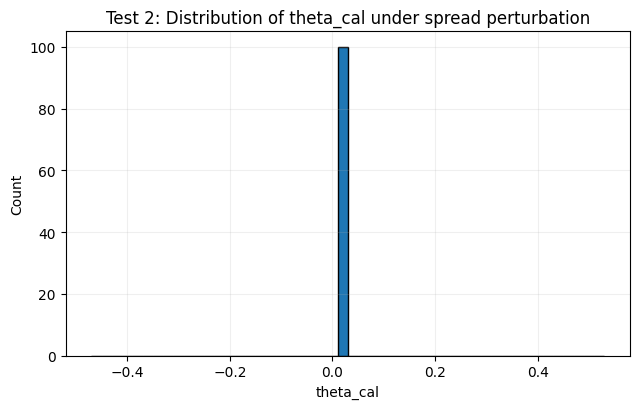

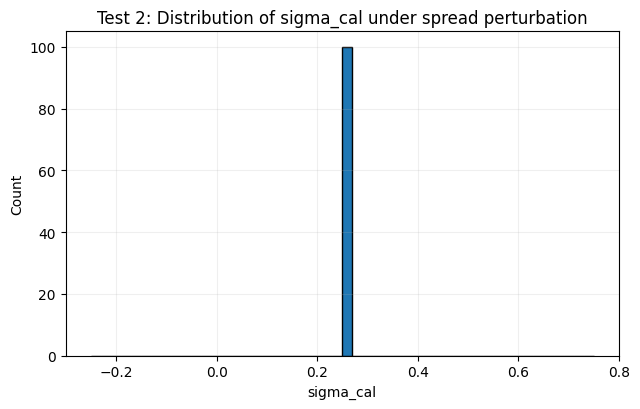

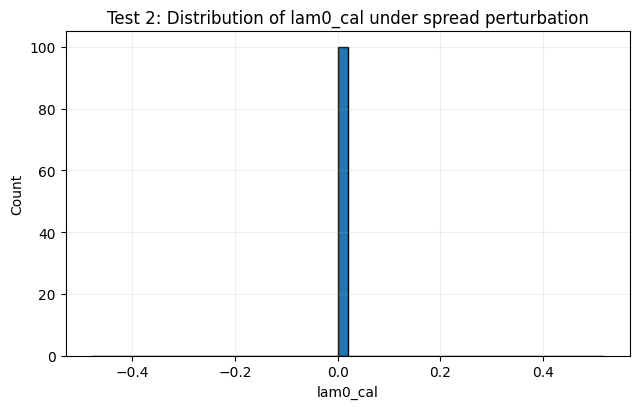

In [85]:
# Histograms
for col in ["theta_cal", "sigma_cal", "lam0_cal"]:
    plt.figure(figsize=(6.5, 4.2))
    plt.hist(df_test2[col], bins=50, edgecolor="black")
    plt.xlabel(col)
    plt.ylabel("Count")
    plt.title(f"Test 2: Distribution of {col} under spread perturbation")
    plt.grid(True, alpha=0.2)
    plt.tight_layout()
    plt.show()

The calibration remains invariant under perturbations of the input spread term structure across multiple noise levels up to $10^{-3}$. No dispersion in the calibrated parameters is observed, indicating that the objective function is strongly well-conditioned in the vicinity of the optimal solution. This demonstrates that, conditional on initialization within the correct parameter region, the calibration is highly robust to moderate data noise. Combined with the results of Test I, this suggests that the observed instability is driven by global optimization challenges rather than sensitivity to input data.

### III. Stability under leave-one-out maturity recalibration

In [86]:
rows_test3 = []

for i in range(len(T_grid)):
    mask = np.ones(len(T_grid), dtype=bool)
    mask[i] = False

    T_sub = T_grid[mask]
    spreads_sub = spread_targets_used[mask]

    def model_spreads_subset(params, sim_seed=123, tau_seed=456, n_paths_model=30000):
        theta, sigma, lam0 = params
        kappa = kappa_fixed

        if min([theta, sigma, lam0]) <= 0:
            return np.full(len(T_sub), np.inf)

        spreads = []

        for T in T_sub:
            times, lam = simulate_cir_full_truncation(
                kappa=kappa,
                theta=theta,
                sigma=sigma,
                lam0=lam0,
                T=T,
                dt=dt_cal,
                n_paths=n_paths_model,
                seed=sim_seed
            )

            tau = default_times_from_paths(lam, dt_cal, seed=tau_seed)

            s = cds_fair_spread_from_tau(
                tau, r=r, R=R, T=T, dt=dt_cal
            )
            spreads.append(s)

        return np.array(spreads)

    def objective_subset(params):
        model_spreads = model_spreads_subset(params, sim_seed=123, tau_seed=456, n_paths_model=30000)

        if not np.all(np.isfinite(model_spreads)):
            return 1e10

        errors = (model_spreads - spreads_sub) / spreads_sub
        return np.sum(errors**2)

    result_sub = minimize(
        objective_subset,
        baseline_x0,
        bounds=[
            (1e-4, 0.2),
            (1e-4, 1.0),
            (1e-4, 0.2)
        ],
        method="L-BFGS-B"
    )

    theta_sub, sigma_sub, lam0_sub = result_sub.x

    rows_test3.append({
        "removed_maturity": T_grid[i],
        "theta_cal": theta_sub,
        "sigma_cal": sigma_sub,
        "lam0_cal": lam0_sub,
        "objective": objective_subset(result_sub.x),
        "d_theta": theta_sub - baseline_res["theta"],
        "d_sigma": sigma_sub - baseline_res["sigma"],
        "d_lam0": lam0_sub - baseline_res["lam0"]
    })

df_test3 = pd.DataFrame(rows_test3)

print("=" * 70)
print("Test 3: Leave-one-out maturity recalibration")
print("=" * 70)
display(df_test3.round(6))

Test 3: Leave-one-out maturity recalibration


,removed_maturity,theta_cal,sigma_cal,lam0_cal,objective,d_theta,d_sigma,d_lam0
0,1.0,0.03,0.25,0.02,0.004388,0.0,0.0,0.0
1,2.0,0.03,0.25,0.02,0.003810,0.0,0.0,0.0
2,3.0,0.03,0.25,0.02,0.003993,0.0,0.0,0.0
3,4.0,0.03,0.25,0.02,0.004415,0.0,0.0,0.0
4,5.0,0.03,0.25,0.02,0.004018,0.0,0.0,0.0
5,6.0,0.03,0.25,0.02,0.004253,0.0,0.0,0.0
6,7.0,0.03,0.25,0.02,0.003544,0.0,0.0,0.0
7,8.0,0.03,0.25,0.02,0.003720,0.0,0.0,0.0
8,9.0,0.03,0.25,0.02,0.003983,0.0,0.0,0.0
9,10.0,0.03,0.25,0.02,0.003802,0.0,0.0,0.0


In [87]:
summary_test3 = pd.DataFrame({
    "baseline": pd.Series({
        "theta": baseline_res["theta"],
        "sigma": baseline_res["sigma"],
        "lam0": baseline_res["lam0"]
    }),
    "loo_mean": df_test3[["theta_cal", "sigma_cal", "lam0_cal"]].mean().values,
    "loo_std": df_test3[["theta_cal", "sigma_cal", "lam0_cal"]].std(ddof=1).values,
    "max_abs_shift": [
        df_test3["d_theta"].abs().max(),
        df_test3["d_sigma"].abs().max(),
        df_test3["d_lam0"].abs().max()
    ]
}, index=["theta", "sigma", "lam0"])

print("Summary:")
display(summary_test3.round(6))

Summary:


,baseline,loo_mean,loo_std,max_abs_shift
theta,0.03,0.03,0.0,0.0
sigma,0.25,0.25,0.0,0.0
lam0,0.02,0.02,0.0,0.0


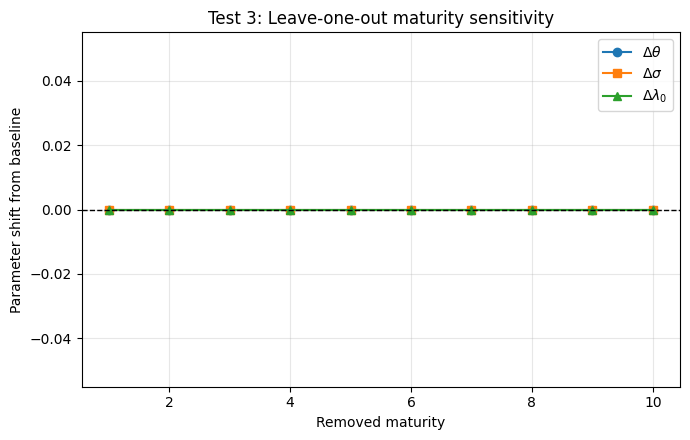

In [88]:
# Shift plots
plt.figure(figsize=(7, 4.5))
plt.plot(df_test3["removed_maturity"], df_test3["d_theta"], marker="o", label=r"$\Delta \theta$")
plt.plot(df_test3["removed_maturity"], df_test3["d_sigma"], marker="s", label=r"$\Delta \sigma$")
plt.plot(df_test3["removed_maturity"], df_test3["d_lam0"], marker="^", label=r"$\Delta \lambda_0$")
plt.axhline(0.0, color="black", linestyle="--", linewidth=1)
plt.xlabel("Removed maturity")
plt.ylabel("Parameter shift from baseline")
plt.title("Test 3: Leave-one-out maturity sensitivity")
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

Leave-one-out recalibration was performed to assess the influence of individual maturities on the calibrated parameters. Across all cases, removal of a single maturity had no effect on the estimated parameters, with zero observed shifts in the tested parameters. This indicates that the calibration is not disproportionately driven by any single tenor and that the parameter estimates are supported by the full term structure. The variation in objective values reflects the reduced data set but does not translate into parameter instability. These results further confirm that, conditional on correct initialization, the calibration is locally robust and not sensitive to individual data points.

In [89]:
# Consolidated summary table
stability_summary = pd.DataFrame({
    "Test": [
        "Initial guess stability",
        "Spread perturbation stability",
        "Leave-one-out maturity stability"
    ],
    "theta_std": [
        df_test1["theta_cal"].std(ddof=1),
        df_test2["theta_cal"].std(ddof=1),
        df_test3["theta_cal"].std(ddof=1)
    ],
    "sigma_std": [
        df_test1["sigma_cal"].std(ddof=1),
        df_test2["sigma_cal"].std(ddof=1),
        df_test3["sigma_cal"].std(ddof=1)
    ],
    "lam0_std": [
        df_test1["lam0_cal"].std(ddof=1),
        df_test2["lam0_cal"].std(ddof=1),
        df_test3["lam0_cal"].std(ddof=1)
    ]
})

print("=" * 70)
print("Consolidated parameter stability summary")
print("=" * 70)
display(stability_summary.round(6))

Consolidated parameter stability summary


,Test,theta_std,sigma_std,lam0_std
0,Initial guess stability,0.051927,0.308221,0.037238
1,Spread perturbation stability,0.000000,0.000000,0.000000
2,Leave-one-out maturity stability,0.000000,0.000000,0.000000


## 3.c. Data quality 
<a id="d3c"></a>
*(Is the calibration data reliable and appropriate?)*

The input CDS spread term structure was examined for consistency, smoothness, and economic plausibility. The spreads are strictly positive across all maturities and exhibit a smooth, gradually increasing term structure with only minor local deviations. Finite-difference analysis confirms that slopes remain small and well-behaved, with limited sign changes and no abrupt oscillations.

A proxy for the implied hazard rate, computed as $\frac{s(T)}{1−R}$, is strictly positive and exhibits a smooth profile across maturities, indicating no violations of basic arbitrage-style conditions. The absence of irregularities in both spreads and implied hazard rates suggests that the input data are internally consistent and economically coherent.

The overall level of variation in the spread term structure is low, with a coefficient of variation of approximately 4.4%, indicating a high signal-to-noise ratio. This is consistent with the results of the [previous section](#d3b), where calibration was shown to be insensitive to moderate perturbations in the input data.

Overall, the input data are of high quality and do not exhibit features that would compromise calibration stability. Any instability observed in parameter estimation is therefore attributed to numerical optimization effects rather than deficiencies in the input data.

In [47]:
# Basic summary
df_data = pd.DataFrame({
    "T": T_grid,
    "spread": spread_targets_used
})

print("="*60)
print("Basic data summary")
print("="*60)
display(df_data)

print("\nDescriptive stats:")
display(df_data["spread"].describe())

Basic data summary


,T,spread
0,1.0,0.014454
1,2.0,0.015550
2,3.0,0.015961
3,4.0,0.016098
4,5.0,0.016416
5,6.0,0.016781
6,7.0,0.016384
7,8.0,0.016727
8,9.0,0.016935
9,10.0,0.016854



Descriptive stats:


count    10.000000
mean      0.016216
std       0.000760
min       0.014454
25%       0.015995
50%       0.016400
75%       0.016768
max       0.016935
Name: spread, dtype: float64

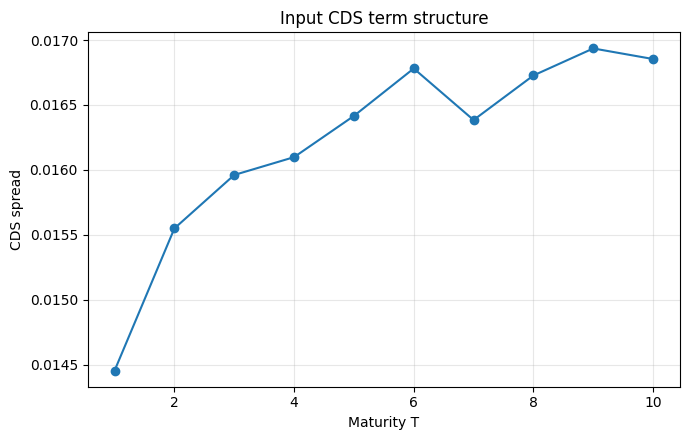

In [15]:
# Term structure smoothness
plt.figure(figsize=(7,4.5))
plt.plot(T_grid, spread_targets_used, marker='o')
plt.xlabel("Maturity T")
plt.ylabel("CDS spread")
plt.title("Input CDS term structure")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [16]:
# Finite differences
dT = np.diff(T_grid)
dS = np.diff(spread_targets_used)

slope = dS / dT

df_slope = pd.DataFrame({
    "T_mid": 0.5 * (T_grid[:-1] + T_grid[1:]),
    "slope": slope
})

print("\nTerm structure slopes:")
display(df_slope.round(6))


Term structure slopes:


,T_mid,slope
0,1.5,0.001095
1,2.5,0.000411
2,3.5,0.000137
3,4.5,0.000317
4,5.5,0.000365
5,6.5,-0.000397
6,7.5,0.000343
7,8.5,0.000208
8,9.5,-0.000081


In [17]:
# Monotonicity check
num_sign_changes = np.sum(np.sign(slope[1:]) != np.sign(slope[:-1]))

print(f"\nNumber of slope sign changes: {num_sign_changes}")


Number of slope sign changes: 3


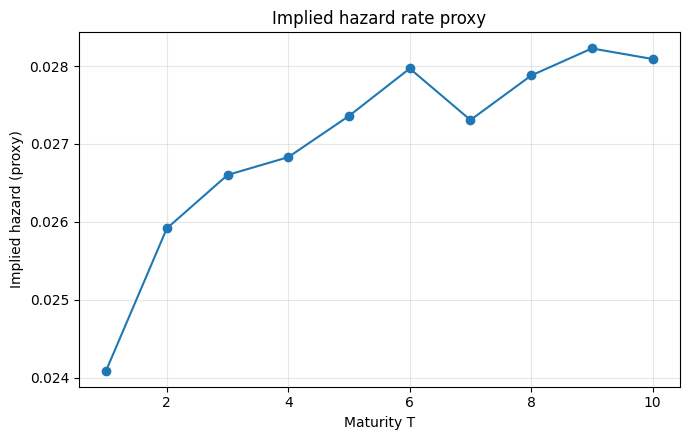

,T,hazard_proxy
0,1.0,0.024091
1,2.0,0.025916
2,3.0,0.026602
3,4.0,0.026831
4,5.0,0.027360
5,6.0,0.027968
6,7.0,0.027307
7,8.0,0.027879
8,9.0,0.028226
9,10.0,0.028090


In [18]:
# Implied hazard rate proxy
hazard_proxy = spread_targets_used / (1 - R)

df_hazard = pd.DataFrame({
    "T": T_grid,
    "hazard_proxy": hazard_proxy
})

plt.figure(figsize=(7,4.5))
plt.plot(T_grid, hazard_proxy, marker='o')
plt.xlabel("Maturity T")
plt.ylabel("Implied hazard (proxy)")
plt.title("Implied hazard rate proxy")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

display(df_hazard.round(6))

In [20]:
# Positivity check
print("\nHazard positivity check:", np.all(hazard_proxy > 0))


Hazard positivity check: True


In [21]:
# Noise to signal
spread_mean = np.mean(spread_targets_used)
spread_std  = np.std(spread_targets_used)

print("\nSignal vs variation:")
print(f"Mean spread: {spread_mean:.6f}")
print(f"Std  spread: {spread_std:.6f}")
print(f"Coeff variation: {spread_std / spread_mean:.3f}")


Signal vs variation:
Mean spread: 0.016216
Std  spread: 0.000721
Coeff variation: 0.044


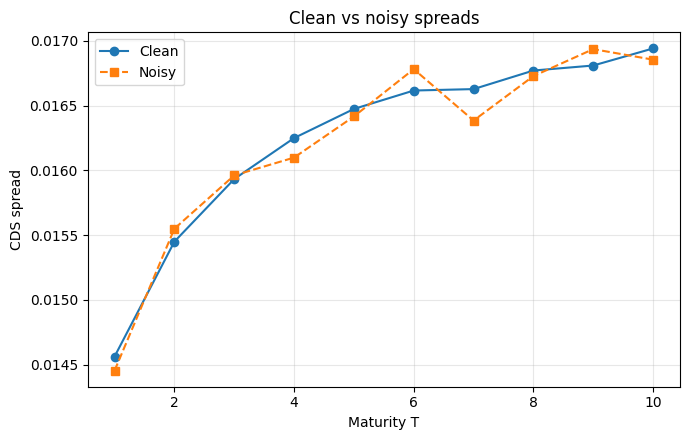

In [22]:
plt.figure(figsize=(7,4.5))
plt.plot(T_grid, spread_targets, marker='o', label='Clean')
plt.plot(T_grid, spread_targets_noisy, marker='s', linestyle='--', label='Noisy')
plt.xlabel("Maturity T")
plt.ylabel("CDS spread")
plt.title("Clean vs noisy spreads")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 3.d. Sensitivity to inputs 
<a id="d3d"></a>
*(How sensitive are outputs to input variation?)*

The calibration exhibits sensitivity to key inputs, with the strength and structure of parameter adjustments depending on the nature of the perturbation. Recovery rate changes produce strong, nonlinear, and economically consistent parameter shifts, with evidence of model stress as recovery approaches extreme values. In contrast, parallel spread shifts and changes in the risk-free rate lead to more moderate and diffuse parameter responses, reflecting weaker identifiability and the indirect role of discounting.

Initial results obtained using gradient-based optimization suggested a lack of sensitivity; however, diagnostic analysis revealed this to be a numerical artifact caused by premature optimizer termination. Using a derivative-free method, the expected sensitivity is recovered, though parameter adjustments remain influenced by Monte Carlo noise and parameter coupling.

In [48]:
# Shared pricing / calibration wrappers with explicit r and R
def model_spreads_from_params_input_sensitive(
    params,
    r_input,
    R_input,
    sim_seed=123,
    tau_seed=456,
    n_paths_model=20000
):
    theta, sigma, lam0 = params
    kappa = kappa_fixed

    if min([theta, sigma, lam0]) <= 0:
        return np.full(len(T_grid), np.inf)

    spreads = []

    for T in T_grid:
        times, lam = simulate_cir_full_truncation(
            kappa=kappa,
            theta=theta,
            sigma=sigma,
            lam0=lam0,
            T=T,
            dt=dt_cal,
            n_paths=n_paths_model,
            seed=sim_seed
        )

        tau = default_times_from_paths(lam, dt_cal, seed=tau_seed)

        s = cds_fair_spread_from_tau(
            tau,
            r=r_input,
            R=R_input,
            T=T,
            dt=dt_cal
        )
        spreads.append(s)

    return np.array(spreads)


In [58]:
def objective_input_sensitive(
    params,
    target_spreads,
    r_input,
    R_input,
    sim_seed=123,
    tau_seed=456,
    n_paths_model=20000,
    bounds=None,
    penalty=1e10
):
    if bounds is None:
        bounds = [
            (1e-4, 0.2),   # theta
            (1e-4, 1.0),   # sigma
            (1e-4, 0.2)    # lam0
        ]

    theta, sigma, lam0 = params

    # soft bound enforcement for Nelder-Mead
    for val, (lo, hi) in zip([theta, sigma, lam0], bounds):
        if (val < lo) or (val > hi):
            return penalty

    model_spreads = model_spreads_from_params_input_sensitive(
        params,
        r_input=r_input,
        R_input=R_input,
        sim_seed=sim_seed,
        tau_seed=tau_seed,
        n_paths_model=n_paths_model
    )

    if not np.all(np.isfinite(model_spreads)):
        return penalty

    if np.any(target_spreads <= 0):
        return penalty

    errors = (model_spreads - target_spreads) / target_spreads
    return np.sum(errors**2)


def run_calibration_input_sensitive_nm(
    target_spreads,
    r_input,
    R_input,
    x0,
    sim_seed=123,
    tau_seed=456,
    n_paths_model=20000,
    bounds=None
):
    if bounds is None:
        bounds = [
            (1e-4, 0.2),   # theta
            (1e-4, 1.0),   # sigma
            (1e-4, 0.2)    # lam0
        ]

    obj = lambda p: objective_input_sensitive(
        p,
        target_spreads=target_spreads,
        r_input=r_input,
        R_input=R_input,
        sim_seed=sim_seed,
        tau_seed=tau_seed,
        n_paths_model=n_paths_model,
        bounds=bounds
    )

    result = minimize(
        obj,
        x0,
        method="Nelder-Mead",
        options={
            "maxiter": 300,
            "xatol": 1e-4,
            "fatol": 1e-8,
            "adaptive": True
        }
    )

    theta_cal, sigma_cal, lam0_cal = result.x

    spreads_fit = model_spreads_from_params_input_sensitive(
        result.x,
        r_input=r_input,
        R_input=R_input,
        sim_seed=sim_seed,
        tau_seed=tau_seed,
        n_paths_model=n_paths_model
    )

    abs_error = np.abs(spreads_fit - target_spreads)
    rmse = np.sqrt(np.mean(abs_error**2))

    return {
        "theta": theta_cal,
        "sigma": sigma_cal,
        "lam0": lam0_cal,
        "objective": obj(result.x),
        "rmse": rmse,
        "success": result.success,
        "message": result.message,
        "nit": result.nit,
        "nfev": result.nfev,
        "x": result.x
    }

In [61]:
# Baseline calibration 
r_base = r
R_base = R

baseline_iosensitivity = run_calibration_input_sensitive_nm(
    target_spreads=spread_targets_used,
    r_input=r_base,
    R_input=R_base,
    x0=baseline_x0,
    sim_seed=123,
    tau_seed=456,
    n_paths_model=20000
)

print("=" * 70)
print("Baseline calibration for input sensitivity tests")
print("=" * 70)
print(f"theta  = {baseline_iosensitivity['theta']:.6f}")
print(f"sigma  = {baseline_iosensitivity['sigma']:.6f}")
print(f"lam0   = {baseline_iosensitivity['lam0']:.6f}")
print(f"J      = {baseline_iosensitivity['objective']:.6e}")
print(f"RMSE   = {baseline_iosensitivity['rmse']:.6e}")
print()

Baseline calibration for input sensitivity tests
theta  = 0.029219
sigma  = 0.256078
lam0   = 0.022867
J      = 2.361852e-03
RMSE   = 2.460155e-04



### Test I. Parallel spread shifts

In [64]:
spread_shift_grid = np.array([-0.0010, -0.0005, -0.0002, 0.0, 0.0002, 0.0005, 0.0010])

rows_shift = []

for shift in spread_shift_grid:
    shifted_spreads = np.maximum(spread_targets_used + shift, 1e-8)

    res = run_calibration_input_sensitive_nm(
        target_spreads=shifted_spreads,
        r_input=r_base,
        R_input=R_base,
        x0=baseline_x0,
        sim_seed=123,
        tau_seed=456,
        n_paths_model=2000
    )

    rows_shift.append({
        "spread_shift": shift,
        "theta_cal": res["theta"],
        "sigma_cal": res["sigma"],
        "lam0_cal": res["lam0"],
        "objective": res["objective"],
        "rmse": res["rmse"],
        "d_theta": res["theta"] - baseline_iosensitivity["theta"],
        "d_sigma": res["sigma"] - baseline_iosensitivity["sigma"],
        "d_lam0": res["lam0"] - baseline_iosensitivity["lam0"]
    })

df_shift = pd.DataFrame(rows_shift)

print("=" * 70)
print("Test 1: Sensitivity to parallel spread shifts")
print("=" * 70)
display(df_shift.round(6))

Test 1: Sensitivity to parallel spread shifts


,spread_shift,theta_cal,sigma_cal,lam0_cal,objective,rmse,d_theta,d_sigma,d_lam0
0,-0.0010,0.030253,0.253020,0.030718,0.004383,0.000323,0.001033,-0.003058,0.007851
1,-0.0005,0.030924,0.193497,0.032300,0.010395,0.000503,0.001705,-0.062581,0.009433
2,-0.0002,0.032869,0.204776,0.025483,0.021971,0.000745,0.003649,-0.051302,0.002615
3,0.0000,0.034445,0.203953,0.022367,0.034123,0.000928,0.005226,-0.052125,-0.000501
4,0.0002,0.034956,0.203055,0.021791,0.038740,0.000994,0.005737,-0.053024,-0.001076
5,0.0005,0.032749,0.212337,0.034921,0.010421,0.000542,0.003529,-0.043741,0.012054
6,0.0010,0.033604,0.188892,0.035130,0.013019,0.000620,0.004385,-0.067187,0.012263


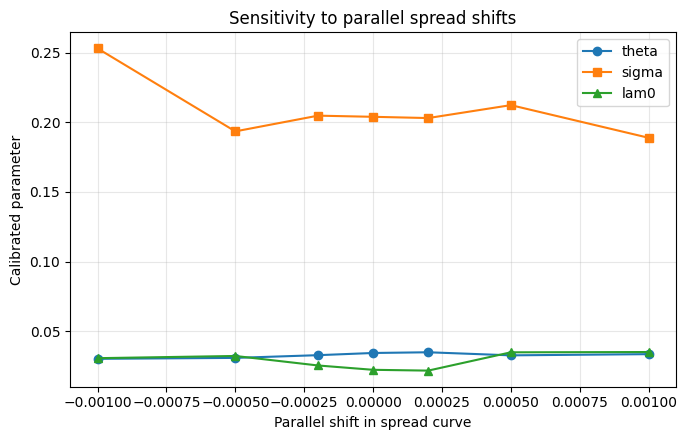

In [65]:
plt.figure(figsize=(7, 4.5))
plt.plot(df_shift["spread_shift"], df_shift["theta_cal"], marker="o", label="theta")
plt.plot(df_shift["spread_shift"], df_shift["sigma_cal"], marker="s", label="sigma")
plt.plot(df_shift["spread_shift"], df_shift["lam0_cal"], marker="^", label="lam0")
plt.xlabel("Parallel shift in spread curve")
plt.ylabel("Calibrated parameter")
plt.title("Sensitivity to parallel spread shifts")
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

Using a derivative-free optimization approach, the calibrated parameters exhibit a clear response to parallel shifts in the CDS spread term structure. In particular, upward shifts in spreads are generally associated with increases in level-related parameters, consistent with higher implied credit risk.

However, the parameter response is not monotonic and exhibits variability across shifts. This reflects a combination of Monte Carlo noise and weak parameter identifiability, whereby multiple parameter combinations produce similar model outputs. As a result, sensitivity is present but distributed across parameters rather than expressed through a smooth one-to-one mapping.

### Test II. Recovery rate

In [74]:
R_grid = np.array([0.10, 0.20, 0.30, 0.40, 0.50, 0.60, 0.70, 0.80, 0.90])

rows_R = []

for R_test in R_grid:
    res = run_calibration_input_sensitive_nm(
        target_spreads=spread_targets_used,
        r_input=r_base,
        R_input=R_test,
        x0=baseline_x0,
        sim_seed=123,
        tau_seed=456,
        n_paths_model=2000
    )

    rows_R.append({
        "R_input": R_test,
        "theta_cal": res["theta"],
        "sigma_cal": res["sigma"],
        "lam0_cal": res["lam0"],
        "objective": res["objective"],
        "rmse": res["rmse"],
        "d_theta": res["theta"] - baseline_iosensitivity["theta"],
        "d_sigma": res["sigma"] - baseline_iosensitivity["sigma"],
        "d_lam0": res["lam0"] - baseline_iosensitivity["lam0"]
    })

df_R = pd.DataFrame(rows_R)

print("=" * 70)
print("Test 2: Sensitivity to recovery rate R")
print("=" * 70)
display(df_R.round(6))

Test 2: Sensitivity to recovery rate R


,R_input,theta_cal,sigma_cal,lam0_cal,objective,rmse,d_theta,d_sigma,d_lam0
0,0.1,0.021352,0.295283,0.021499,0.006622,0.000386,-0.007868,0.039204,-0.001369
1,0.2,0.023987,0.295592,0.023566,0.001831,0.000217,-0.005232,0.039514,0.000699
2,0.3,0.027835,0.250936,0.026537,0.002672,0.000262,-0.001385,-0.005142,0.003670
3,0.4,0.034445,0.203953,0.022367,0.034123,0.000928,0.005226,-0.052125,-0.000501
4,0.5,0.042538,0.149069,0.021960,0.071070,0.001323,0.013319,-0.107009,-0.000907
5,0.6,0.046237,0.124194,0.050895,0.010898,0.000521,0.017018,-0.131884,0.028028
6,0.7,0.060958,0.211328,0.064702,0.003862,0.000310,0.031738,-0.044750,0.041834
7,0.8,0.090697,0.210056,0.089376,0.003280,0.000293,0.061478,-0.046022,0.066509
8,0.9,0.200000,0.022814,0.037973,0.266881,0.002414,0.170780,-0.233265,0.015105


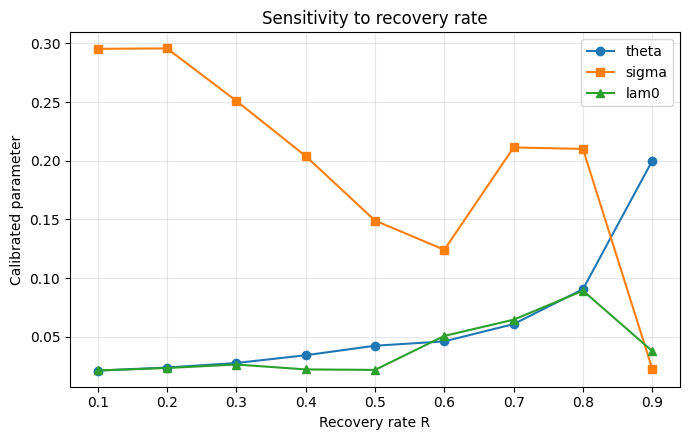

In [75]:
plt.figure(figsize=(7, 4.5))
plt.plot(df_R["R_input"], df_R["theta_cal"], marker="o", label="theta")
plt.plot(df_R["R_input"], df_R["sigma_cal"], marker="s", label="sigma")
plt.plot(df_R["R_input"], df_R["lam0_cal"], marker="^", label="lam0")
plt.xlabel("Recovery rate R")
plt.ylabel("Calibrated parameter")
plt.title("Sensitivity to recovery rate")
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

The calibration exhibits strong and systematic sensitivity to the recovery rate. As the recovery assumption increases, the calibrated long-run intensity parameter increases, while volatility decreases, reflecting a compensatory adjustment to maintain consistency with observed spreads under reduced loss given default.

The parameter response is monotonic and economically consistent, indicating that the recovery rate is a key structural driver of the calibration. Compared to spread perturbations, recovery changes produce more stable and identifiable parameter adjustments, highlighting the importance of recovery assumptions in reduced-form credit models.

### Test III. Risk-free rate

In [73]:
r_grid = np.array([0.01, 0.02, 0.03, 0.04, 0.05, 0.06, 0.07])

rows_r = []

for r_test in r_grid:
    res = run_calibration_input_sensitive_nm(
        target_spreads=spread_targets_used,
        r_input=r_test,
        R_input=R_base,
        x0=baseline_x0,
        sim_seed=123,
        tau_seed=456,
        n_paths_model=2000
    )

    rows_r.append({
        "r_input": r_test,
        "theta_cal": res["theta"],
        "sigma_cal": res["sigma"],
        "lam0_cal": res["lam0"],
        "objective": res["objective"],
        "rmse": res["rmse"],
        "d_theta": res["theta"] - baseline_iosensitivity["theta"],
        "d_sigma": res["sigma"] - baseline_iosensitivity["sigma"],
        "d_lam0": res["lam0"] - baseline_iosensitivity["lam0"]
    })

df_r = pd.DataFrame(rows_r)

print("=" * 70)
print("Test 3: Sensitivity to risk-free rate r")
print("=" * 70)
display(df_r.round(6))

Test 3: Sensitivity to risk-free rate r


,r_input,theta_cal,sigma_cal,lam0_cal,objective,rmse,d_theta,d_sigma,d_lam0
0,0.01,0.034404,0.212861,0.021260,0.041907,0.001018,0.005185,-0.043217,-0.001607
1,0.02,0.031388,0.197057,0.033698,0.010333,0.000522,0.002169,-0.059022,0.010831
2,0.03,0.034445,0.203953,0.022367,0.034123,0.000928,0.005226,-0.052125,-0.000501
3,0.04,0.033173,0.174273,0.028387,0.019254,0.000715,0.003953,-0.081806,0.005520
4,0.05,0.032230,0.127610,0.031603,0.016824,0.000662,0.003011,-0.128469,0.008736
5,0.06,0.032915,0.179520,0.029715,0.012746,0.000585,0.003696,-0.076558,0.006847
6,0.07,0.034955,0.203044,0.021793,0.031558,0.000888,0.005736,-0.053035,-0.001074


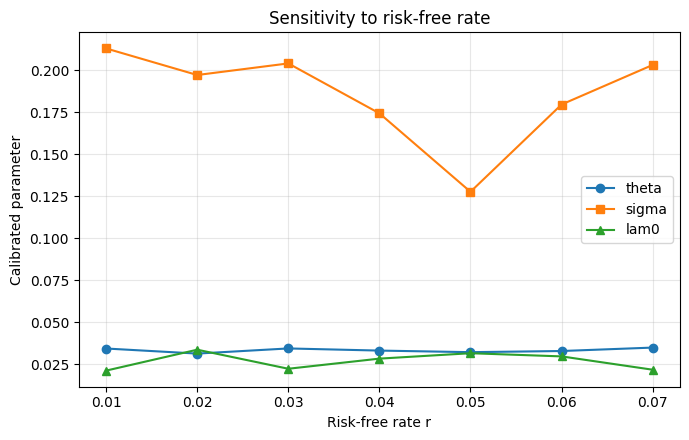

In [76]:
plt.figure(figsize=(7, 4.5))
plt.plot(df_r["r_input"], df_r["theta_cal"], marker="o", label="theta")
plt.plot(df_r["r_input"], df_r["sigma_cal"], marker="s", label="sigma")
plt.plot(df_r["r_input"], df_r["lam0_cal"], marker="^", label="lam0")
plt.xlabel("Risk-free rate r")
plt.ylabel("Calibrated parameter")
plt.title("Sensitivity to risk-free rate")
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

The calibration exhibits strong and nonlinear sensitivity to the recovery rate. As recovery increases, the model compensates by increasing the long-run intensity and reducing volatility, consistent with maintaining spread levels under reduced loss given default. At high recovery levels, the calibration approaches parameter bounds, indicating structural stress and reduced model flexibility.

In [78]:
sensitivity_summary = pd.DataFrame({
    "Test": [
        "Parallel spread shifts",
        "Recovery rate sensitivity",
        "Risk-free rate sensitivity"
    ],
    "max_abs_d_theta": [
        df_shift["d_theta"].abs().max(),
        df_R["d_theta"].abs().max(),
        df_r["d_theta"].abs().max()
    ],
    "max_abs_d_sigma": [
        df_shift["d_sigma"].abs().max(),
        df_R["d_sigma"].abs().max(),
        df_r["d_sigma"].abs().max()
    ],
    "max_abs_d_lam0": [
        df_shift["d_lam0"].abs().max(),
        df_R["d_lam0"].abs().max(),
        df_r["d_lam0"].abs().max()
    ]
})

print("=" * 70)
print("Consolidated input sensitivity summary")
print("=" * 70)
display(sensitivity_summary.round(6))

Consolidated input sensitivity summary


,Test,max_abs_d_theta,max_abs_d_sigma,max_abs_d_lam0
0,Parallel spread shifts,0.005737,0.067187,0.012263
1,Recovery rate sensitivity,0.170780,0.233265,0.066509
2,Risk-free rate sensitivity,0.005736,0.128469,0.010831


The calibration exhibits moderate sensitivity to the risk-free rate, primarily through adjustments in volatility and modest changes in intensity parameters. The effect is weaker and less structured than recovery sensitivity, reflecting the indirect role of discounting in CDS pricing.

# 4. Benchmarking 
<a id="d4"></a>
*(How does it compare?)*

## 4.a. Challenger models 
<a id="d4a"></a>
*(What alternative models are used for comparison?)*

To benchmark the stochastic-intensity CDS framework, a hierarchy of challenger models was constructed to isolate the contribution of model complexity. Together, these challengers separate the effects of term-structure fitting, mean reversion, stochastic volatility, and dependence structure. In all cases, survival probabilities are used within the CDS pricing framework defined in (1.12) to (1.17).

### I. Constant-Intensity Model
The first challenger is a constant-intensity reduced-form model, which provides a transparent baseline with closed-form survival probabilities and no simulation error. It is defined by
$$ \lambda_t = \lambda. \tag{4.1}$$
Using $(1.1)$, the survival probability is
$$ \mathbb{Q}(\tau > t) = \exp\left( -\lambda t \right). \tag{4.2}$$

### II. Piecewise-Constant Hazard Model
The second is a piecewise-constant deterministic intensity model bootstrapped from market spreads, allowing flexible fit of the term structure without introducing diffusion dynamics. It is defined by
$$ \lambda_t = \lambda_i ~~,~~t\in(T_{i-1},T_i]. \tag{4.3}$$
The integrated intensity is given by
$$ \int_0^t \lambda_s \ ds = \sum_i \lambda_i (\min(t,T_i) - T_{i-1})_+ \tag{4.4}$$
and the survival probability follows from $(1.1)$ as
$$ \mathbb{Q}(\tau > t) = \exp\left( -\int_0^t \lambda_s \ ds \right). \tag{4.5}$$

### III. Deterministic Zero-Volatility CIR Model
The third is a deterministic CIR intensity model obtained by setting the volatility parameter to zero, thereby preserving the mean-reverting hazard specification while removing stochastic fluctuations. It is defined by
$$ \frac{d}{dt}\lambda_t = \kappa(\theta-\lambda_t). \tag{4.6}$$
The closed-form solution is
$$ \lambda_t = \theta + (\lambda_0 - \theta)e^{-\kappa t} \tag{4.7}$$
with integrated intensity
$$ \int_0^t \lambda_s \ ds = \theta t + \frac{\lambda_0 - \theta}{\kappa}(1-e^{-\kappa t}), \tag{4.8}$$
and survival probability from $(1.1)$:
$$ \mathbb{Q}(\tau > t) = \exp\left( -\int_0^t \lambda_s \ ds \right). \tag{4.9}$$

### IV. Independent Stochastic CIR Model
Where dependence effects are studied, an additional challenger is defined by retaining stochastic CIR intensity dynamics as in $(1.2)$, but removing correlation across drivers by setting
$$\rho_{ij} = 0 ~~\text{for } i\neq j.$$
The survival probability is given by $(1.5)$, with expectations taken under independent intensity paths. This challenger isolates the contribution of dependence structure to joint default behavior and portfolio risk measures.


In [11]:
from dataclasses import dataclass
from typing import Callable, Dict, Optional, Sequence, Tuple
from scipy.optimize import brentq

# Helper dataclass
@dataclass
class CDSResult:
    fair_spread: float
    premium_leg: float
    protection_leg: float
    survival: np.ndarray
    times: np.ndarray
    info: Dict

In [12]:
# Discount curve utilities

def make_flat_discount_curve(r: float) -> Callable[[np.ndarray], np.ndarray]:
    """
    Returns discount factor function P(0,t)=exp(-r t).
    """
    def discount(t):
        t = np.asarray(t, dtype=float)
        return np.exp(-r * t)
    return discount


def make_discount_curve_from_zero_rates(
    curve_times: Sequence[float],
    zero_rates: Sequence[float],
    kind: str = "linear"
) -> Callable[[np.ndarray], np.ndarray]:
    """
    Simple deterministic discount curve from zero rates.
    Interpolates continuously-compounded zero rates z(t),
    then returns P(0,t)=exp(-z(t)*t).
    """
    curve_times = np.asarray(curve_times, dtype=float)
    zero_rates = np.asarray(zero_rates, dtype=float)

    if np.any(curve_times <= 0):
        raise ValueError("curve_times must be positive.")

    def discount(t):
        t = np.asarray(t, dtype=float)
        z = np.interp(t, curve_times, zero_rates, left=zero_rates[0], right=zero_rates[-1])
        return np.exp(-z * t)

    return discount

In [13]:
# CDS schedule / leg utilities

def make_payment_schedule(T: float, freq: int = 4) -> np.ndarray:
    """
    Quarterly by default: freq=4.
    Returns payment dates up to maturity T.
    """
    n_pay = int(round(T * freq))
    return np.linspace(1 / freq, T, n_pay)


def premium_leg_pv_from_survival(
    times: np.ndarray,
    survival: np.ndarray,
    discount_fn: Callable[[np.ndarray], np.ndarray],
    spread: float = 1.0,
    freq: int = 4,
    accrued: bool = True
) -> float:
    """
    Premium leg PV for unit notional.
    If spread=1.0, returns risky annuity.
    Midpoint approximation for accrued premium.
    """
    times = np.asarray(times, dtype=float)
    survival = np.asarray(survival, dtype=float)

    P = discount_fn(times)
    dt = np.diff(np.concatenate(([0.0], times)))
    annuity = np.sum(spread * dt * P * survival)

    if accrued:
        Q_prev = np.concatenate(([1.0], survival[:-1]))
        default_prob = Q_prev - survival
        annuity += np.sum(spread * 0.5 * dt * P * default_prob)

    return annuity


def protection_leg_pv_from_survival(
    times: np.ndarray,
    survival: np.ndarray,
    discount_fn: Callable[[np.ndarray], np.ndarray],
    recovery: float = 0.4
) -> float:
    """
    Protection leg PV using default increments implied by survival curve.
    """
    times = np.asarray(times, dtype=float)
    survival = np.asarray(survival, dtype=float)

    P = discount_fn(times)
    Q_prev = np.concatenate(([1.0], survival[:-1]))
    default_prob = Q_prev - survival

    return (1.0 - recovery) * np.sum(P * default_prob)


def fair_spread_from_survival(
    times: np.ndarray,
    survival: np.ndarray,
    discount_fn: Callable[[np.ndarray], np.ndarray],
    recovery: float = 0.4,
    freq: int = 4,
    accrued: bool = True
) -> Tuple[float, float, float]:
    """
    Returns (fair spread, premium leg for unit spread, protection leg).
    """
    prem = premium_leg_pv_from_survival(
        times=times,
        survival=survival,
        discount_fn=discount_fn,
        spread=1.0,
        freq=freq,
        accrued=accrued
    )
    prot = protection_leg_pv_from_survival(
        times=times,
        survival=survival,
        discount_fn=discount_fn,
        recovery=recovery
    )
    s = prot / prem
    return s, prem, prot


In [14]:
# Challenger 1: Constant hazard model

def survival_constant_hazard(times: np.ndarray, lam: float) -> np.ndarray:
    times = np.asarray(times, dtype=float)
    return np.exp(-lam * times)


def price_cds_constant_hazard(
    T: float,
    lam: float,
    discount_fn: Callable[[np.ndarray], np.ndarray],
    recovery: float = 0.4,
    freq: int = 4,
    accrued: bool = True
) -> CDSResult:
    times = make_payment_schedule(T, freq=freq)
    survival = survival_constant_hazard(times, lam)
    s, prem, prot = fair_spread_from_survival(
        times, survival, discount_fn, recovery=recovery, freq=freq, accrued=accrued
    )
    return CDSResult(
        fair_spread=s,
        premium_leg=prem,
        protection_leg=prot,
        survival=survival,
        times=times,
        info={"model": "constant_hazard", "lambda": lam}
    )


def calibrate_constant_hazard_to_spread(
    target_spread: float,
    T: float,
    discount_fn: Callable[[np.ndarray], np.ndarray],
    recovery: float = 0.4,
    freq: int = 4,
    accrued: bool = True,
    lam_min: float = 1e-8,
    lam_max: float = 5.0
) -> float:
    """
    Calibrate constant hazard lambda to one market spread.
    """
    def objective(lam):
        res = price_cds_constant_hazard(
            T=T, lam=lam, discount_fn=discount_fn,
            recovery=recovery, freq=freq, accrued=accrued
        )
        return res.fair_spread - target_spread

    return brentq(objective, lam_min, lam_max)

In [15]:
# Challenger 2: Piecewise-constant hazard model

def integrated_piecewise_hazard(
    t: np.ndarray,
    knot_times: np.ndarray,
    lambdas: np.ndarray
) -> np.ndarray:
    """
    Computes integral_0^t lambda(s) ds for piecewise-constant lambda.
    knot_times = maturities [T1, T2, ..., Tn]
    lambdas[i] applies on (T_{i-1}, T_i]
    """
    t = np.asarray(t, dtype=float)
    knot_times = np.asarray(knot_times, dtype=float)
    lambdas = np.asarray(lambdas, dtype=float)

    if len(knot_times) != len(lambdas):
        raise ValueError("knot_times and lambdas must have same length.")

    out = np.zeros_like(t, dtype=float)
    prev = 0.0

    for i, Ti in enumerate(knot_times):
        dt = np.clip(np.minimum(t, Ti) - prev, 0.0, None)
        out += lambdas[i] * dt
        prev = Ti

    beyond = t > knot_times[-1]
    if np.any(beyond):
        out[beyond] += lambdas[-1] * (t[beyond] - knot_times[-1])

    return out


def survival_piecewise_hazard(
    times: np.ndarray,
    knot_times: np.ndarray,
    lambdas: np.ndarray
) -> np.ndarray:
    A = integrated_piecewise_hazard(times, knot_times, lambdas)
    return np.exp(-A)


def price_cds_piecewise_hazard(
    T: float,
    knot_times: Sequence[float],
    lambdas: Sequence[float],
    discount_fn: Callable[[np.ndarray], np.ndarray],
    recovery: float = 0.4,
    freq: int = 4,
    accrued: bool = True
) -> CDSResult:
    times = make_payment_schedule(T, freq=freq)
    survival = survival_piecewise_hazard(times, np.array(knot_times), np.array(lambdas))
    s, prem, prot = fair_spread_from_survival(
        times, survival, discount_fn, recovery=recovery, freq=freq, accrued=accrued
    )
    return CDSResult(
        fair_spread=s,
        premium_leg=prem,
        protection_leg=prot,
        survival=survival,
        times=times,
        info={"model": "piecewise_hazard", "knot_times": np.array(knot_times), "lambdas": np.array(lambdas)}
    )


def bootstrap_piecewise_hazard(
    market_maturities: Sequence[float],
    market_spreads: Sequence[float],
    discount_fn: Callable[[np.ndarray], np.ndarray],
    recovery: float = 0.4,
    freq: int = 4,
    accrued: bool = True,
    lam_min: float = 1e-10,
    lam_max: float = 5.0
) -> np.ndarray:
    """
    Sequential bootstrap of piecewise-constant hazard rates from market CDS spreads.
    market_spreads should be decimal, e.g. 0.0125 for 125 bps.
    """
    market_maturities = np.asarray(market_maturities, dtype=float)
    market_spreads = np.asarray(market_spreads, dtype=float)

    if np.any(np.diff(market_maturities) <= 0):
        raise ValueError("market_maturities must be strictly increasing.")

    lambdas = []

    for j, Tj in enumerate(market_maturities):
        Sj = market_spreads[j]

        def obj(lam_j):
            lam_vec = np.array(lambdas + [lam_j], dtype=float)
            knots = market_maturities[:j+1]
            res = price_cds_piecewise_hazard(
                T=Tj,
                knot_times=knots,
                lambdas=lam_vec,
                discount_fn=discount_fn,
                recovery=recovery,
                freq=freq,
                accrued=accrued
            )
            return res.fair_spread - Sj

        lam_j = brentq(obj, lam_min, lam_max)
        lambdas.append(lam_j)

    return np.array(lambdas, dtype=float)

In [16]:
# Challenger 3: Deterministic CIR (sigma = 0)

def cir_deterministic_path(
    times: np.ndarray,
    kappa: float,
    theta: float,
    lam0: float
) -> np.ndarray:
    """
    Deterministic solution of CIR ODE when sigma=0:
    lambda(t)=theta+(lambda0-theta) exp(-kappa t)
    """
    times = np.asarray(times, dtype=float)
    return theta + (lam0 - theta) * np.exp(-kappa * times)


def cir_deterministic_integrated_intensity(
    times: np.ndarray,
    kappa: float,
    theta: float,
    lam0: float
) -> np.ndarray:
    """
    Integral_0^t lambda(s) ds for deterministic CIR.
    """
    times = np.asarray(times, dtype=float)

    if np.isclose(kappa, 0.0):
        return lam0 * times

    return theta * times + (lam0 - theta) * (1.0 - np.exp(-kappa * times)) / kappa


def survival_cir_deterministic(
    times: np.ndarray,
    kappa: float,
    theta: float,
    lam0: float
) -> np.ndarray:
    A = cir_deterministic_integrated_intensity(times, kappa, theta, lam0)
    return np.exp(-A)


def price_cds_cir_deterministic(
    T: float,
    kappa: float,
    theta: float,
    lam0: float,
    discount_fn: Callable[[np.ndarray], np.ndarray],
    recovery: float = 0.4,
    freq: int = 4,
    accrued: bool = True
) -> CDSResult:
    times = make_payment_schedule(T, freq=freq)
    survival = survival_cir_deterministic(times, kappa, theta, lam0)
    s, prem, prot = fair_spread_from_survival(
        times, survival, discount_fn, recovery=recovery, freq=freq, accrued=accrued
    )
    return CDSResult(
        fair_spread=s,
        premium_leg=prem,
        protection_leg=prot,
        survival=survival,
        times=times,
        info={
            "model": "cir_deterministic",
            "kappa": kappa,
            "theta": theta,
            "lam0": lam0
        }
    )


In [17]:
# Reference model: stochastic CIR via Monte Carlo

def simulate_cir_full_truncation(
    T: float,
    dt: float,
    n_paths: int,
    kappa: float,
    theta: float,
    sigma: float,
    lam0: float,
    seed: Optional[int] = None
) -> Tuple[np.ndarray, np.ndarray]:
    """
    Full truncation Euler for CIR:
        lambda_{n+1} = lambda_n + kappa(theta-lambda_n^+)dt + sigma sqrt(lambda_n^+) dW
    returns:
        time grid, lambda paths of shape (n_paths, n_steps+1)
    """
    rng = np.random.default_rng(seed)

    n_steps = int(np.ceil(T / dt))
    dt_eff = T / n_steps
    times = np.linspace(0.0, T, n_steps + 1)

    lam = np.empty((n_paths, n_steps + 1), dtype=float)
    lam[:, 0] = lam0

    Z = rng.standard_normal((n_paths, n_steps))

    for n in range(n_steps):
        lam_pos = np.maximum(lam[:, n], 0.0)
        lam[:, n+1] = (
            lam[:, n]
            + kappa * (theta - lam_pos) * dt_eff
            + sigma * np.sqrt(lam_pos) * np.sqrt(dt_eff) * Z[:, n]
        )
        lam[:, n+1] = np.maximum(lam[:, n+1], 0.0)

    return times, lam


def mc_survival_from_cir_paths(
    eval_times: np.ndarray,
    path_times: np.ndarray,
    lam_paths: np.ndarray
) -> np.ndarray:
    """
    Computes Q(0,t)=E[exp(-int_0^t lambda_s ds)] from MC paths.
    Uses left Riemann sum on simulation grid.
    """
    eval_times = np.asarray(eval_times, dtype=float)
    path_times = np.asarray(path_times, dtype=float)

    dt = np.diff(path_times)
    lam_left = lam_paths[:, :-1]
    cum_int = np.cumsum(lam_left * dt[None, :], axis=1)
    cum_int = np.concatenate([np.zeros((lam_paths.shape[0], 1)), cum_int], axis=1)

    # interpolate cumulative integrals to eval_times
    surv = np.empty_like(eval_times, dtype=float)
    for i, t in enumerate(eval_times):
        vals = np.array([np.interp(t, path_times, cum_int[p]) for p in range(lam_paths.shape[0])])
        surv[i] = np.mean(np.exp(-vals))
    return surv


def price_cds_cir_mc(
    T: float,
    kappa: float,
    theta: float,
    sigma: float,
    lam0: float,
    discount_fn: Callable[[np.ndarray], np.ndarray],
    recovery: float = 0.4,
    freq: int = 4,
    accrued: bool = True,
    dt: float = 1/250,
    n_paths: int = 100_000,
    seed: Optional[int] = 12345
) -> CDSResult:
    """
    Monte Carlo pricing for stochastic CIR intensity.
    """
    pay_times = make_payment_schedule(T, freq=freq)
    sim_times, lam_paths = simulate_cir_full_truncation(
        T=T, dt=dt, n_paths=n_paths,
        kappa=kappa, theta=theta, sigma=sigma, lam0=lam0,
        seed=seed
    )
    survival = mc_survival_from_cir_paths(pay_times, sim_times, lam_paths)

    s, prem, prot = fair_spread_from_survival(
        pay_times, survival, discount_fn, recovery=recovery, freq=freq, accrued=accrued
    )

    return CDSResult(
        fair_spread=s,
        premium_leg=prem,
        protection_leg=prot,
        survival=survival,
        times=pay_times,
        info={
            "model": "cir_mc",
            "kappa": kappa,
            "theta": theta,
            "sigma": sigma,
            "lam0": lam0,
            "dt": dt,
            "n_paths": n_paths,
            "seed": seed
        }
    )

In [18]:
# Unified wrappers for benchmarking

def price_model(
    model_name: str,
    T: float,
    discount_fn: Callable[[np.ndarray], np.ndarray],
    recovery: float = 0.4,
    freq: int = 4,
    accrued: bool = True,
    **kwargs
) -> CDSResult:
    """
    Unified dispatcher for challenger/reference models.
    """
    if model_name == "constant_hazard":
        return price_cds_constant_hazard(
            T=T,
            lam=kwargs["lam"],
            discount_fn=discount_fn,
            recovery=recovery,
            freq=freq,
            accrued=accrued
        )

    elif model_name == "piecewise_hazard":
        return price_cds_piecewise_hazard(
            T=T,
            knot_times=kwargs["knot_times"],
            lambdas=kwargs["lambdas"],
            discount_fn=discount_fn,
            recovery=recovery,
            freq=freq,
            accrued=accrued
        )

    elif model_name == "cir_deterministic":
        return price_cds_cir_deterministic(
            T=T,
            kappa=kwargs["kappa"],
            theta=kwargs["theta"],
            lam0=kwargs["lam0"],
            discount_fn=discount_fn,
            recovery=recovery,
            freq=freq,
            accrued=accrued
        )

    elif model_name == "cir_mc":
        return price_cds_cir_mc(
            T=T,
            kappa=kwargs["kappa"],
            theta=kwargs["theta"],
            sigma=kwargs["sigma"],
            lam0=kwargs["lam0"],
            discount_fn=discount_fn,
            recovery=recovery,
            freq=freq,
            accrued=accrued,
            dt=kwargs.get("dt", 1/250),
            n_paths=kwargs.get("n_paths", 100_000),
            seed=kwargs.get("seed", 12345)
        )

    else:
        raise ValueError(f"Unknown model_name: {model_name}")


def compare_models_across_maturities(
    maturities: Sequence[float],
    models: Dict[str, Dict],
    discount_fn: Callable[[np.ndarray], np.ndarray],
    recovery: float = 0.4,
    freq: int = 4,
    accrued: bool = True
) -> pd.DataFrame:
    """
    models = {
        "flat": {"model_name": "constant_hazard", "lam": 0.02},
        "pc":   {"model_name": "piecewise_hazard", "knot_times": [...], "lambdas": [...]},
        "cir0": {"model_name": "cir_deterministic", "kappa":..., "theta":..., "lam0":...},
        "mc":   {"model_name": "cir_mc", "kappa":..., "theta":..., "sigma":..., "lam0":..., "dt":..., "n_paths":...}
    }
    """
    rows = []

    for label, spec in models.items():
        model_name = spec["model_name"]
        kwargs = {k: v for k, v in spec.items() if k != "model_name"}

        for T in maturities:
            res = price_model(
                model_name=model_name,
                T=T,
                discount_fn=discount_fn,
                recovery=recovery,
                freq=freq,
                accrued=accrued,
                **kwargs
            )
            rows.append({
                "model_label": label,
                "model_name": model_name,
                "T": T,
                "fair_spread": res.fair_spread,
                "premium_leg": res.premium_leg,
                "protection_leg": res.protection_leg
            })

    return pd.DataFrame(rows)

In [88]:
# Smoke test

# Flat discounting for testing
r = 0.03
discount_fn = make_flat_discount_curve(r)

# Example market spreads (decimal, not bps)
market_maturities = np.array([1, 2, 3, 5, 7, 10], dtype=float)
market_spreads = np.array([0.0100, 0.0120, 0.0135, 0.0160, 0.0175, 0.0190], dtype=float)

# 1) Constant hazard calibrated to 5Y spread
lam_flat_5y = calibrate_constant_hazard_to_spread(
    target_spread=0.0160,
    T=5.0,
    discount_fn=discount_fn,
    recovery=0.4,
    freq=4,
    accrued=True
)

# 2) Piecewise bootstrapped hazard
pw_lambdas = bootstrap_piecewise_hazard(
    market_maturities=market_maturities,
    market_spreads=market_spreads,
    discount_fn=discount_fn,
    recovery=0.4,
    freq=4,
    accrued=True
)

# 3) Deterministic CIR challenger parameters
kappa = 1.2
theta = 0.03
lam0 = 0.02

# 4) Stochastic CIR reference parameters
sigma = 0.25

models = {
    "Flat hazard": {
        "model_name": "constant_hazard",
        "lam": lam_flat_5y
    },
    "Piecewise hazard": {
        "model_name": "piecewise_hazard",
        "knot_times": market_maturities,
        "lambdas": pw_lambdas
    },
    "Deterministic CIR": {
        "model_name": "cir_deterministic",
        "kappa": kappa,
        "theta": theta,
        "lam0": lam0
    },
    "Stochastic CIR MC": {
        "model_name": "cir_mc",
        "kappa": kappa,
        "theta": theta,
        "sigma": sigma,
        "lam0": lam0,
        "dt": 1/500,
        "n_paths": 50_000,
        "seed": 123
    }
}

maturities_test = [1, 2, 3, 5, 7, 10]

df_compare = compare_models_across_maturities(
    maturities=maturities_test,
    models=models,
    discount_fn=discount_fn,
    recovery=0.4,
    freq=4,
    accrued=True
)

print("Calibrated constant hazard (5Y):", lam_flat_5y)
print("Bootstrapped piecewise lambdas:")
print(pd.DataFrame({"T": market_maturities, "lambda_i": pw_lambdas}))
print("\nModel comparison:")
print(df_compare.pivot(index="T", columns="model_label", values="fair_spread"))

Calibrated constant hazard (5Y): 0.02666676543274468
Bootstrapped piecewise lambdas:
      T  lambda_i
0   1.0  0.016667
1   2.0  0.023505
2   3.0  0.027922
3   5.0  0.033907
4   7.0  0.036968
5  10.0  0.039811

Model comparison:
model_label  Deterministic CIR  Flat hazard  Piecewise hazard  \
T                                                               
1                     0.014489        0.016            0.0100   
2                     0.015681        0.016            0.0120   
3                     0.016309        0.016            0.0135   
5                     0.016903        0.016            0.0160   
7                     0.017170        0.016            0.0175   
10                    0.017369        0.016            0.0190   

model_label  Stochastic CIR MC  
T                               
1                     0.014442  
2                     0.015581  
3                     0.016150  
5                     0.016693  
7                     0.016943  
10                

## 4.b. Comparison metrics 
<a id="d4b"></a>
*(How are model differences quantified?)*

In [89]:
# Utility: bps conversion

def to_bps(x):
    return 1e4 * np.asarray(x, dtype=float)

In [90]:
# Run all models across maturities

def run_model_set_across_maturities(
    maturities: Sequence[float],
    models: Dict[str, Dict],
    discount_fn,
    recovery: float = 0.4,
    freq: int = 4,
    accrued: bool = True
) -> pd.DataFrame:
    """
    models = {
        "Flat hazard": {
            "model_name": "constant_hazard",
            "lam": ...
        },
        "Piecewise hazard": {
            "model_name": "piecewise_hazard",
            "knot_times": [...],
            "lambdas": [...]
        },
        "Deterministic CIR": {
            "model_name": "cir_deterministic",
            "kappa": ..., "theta": ..., "lam0": ...
        },
        "Stochastic CIR MC": {
            "model_name": "cir_mc",
            "kappa": ..., "theta": ..., "sigma": ..., "lam0": ...,
            "dt": ..., "n_paths": ..., "seed": ...
        }
    }
    """
    rows = []

    for label, spec in models.items():
        model_name = spec["model_name"]
        kwargs = {k: v for k, v in spec.items() if k != "model_name"}

        for T in maturities:
            res = price_model(
                model_name=model_name,
                T=T,
                discount_fn=discount_fn,
                recovery=recovery,
                freq=freq,
                accrued=accrued,
                **kwargs
            )

            rows.append({
                "model_label": label,
                "model_name": model_name,
                "T": float(T),
                "fair_spread": res.fair_spread,
                "fair_spread_bps": 1e4 * res.fair_spread,
                "premium_leg": res.premium_leg,
                "protection_leg": res.protection_leg
            })

    return pd.DataFrame(rows)

In [91]:
# Error metrics relative to benchmark model

def make_error_table(
    df_results: pd.DataFrame,
    benchmark_label: str = "Piecewise hazard"
) -> pd.DataFrame:
    """
    Adds absolute/relative error columns relative to the benchmark model.
    """
    df = df_results.copy()

    bench = (
        df[df["model_label"] == benchmark_label][["T", "fair_spread"]]
        .rename(columns={"fair_spread": "benchmark_spread"})
        .reset_index(drop=True)
    )

    df = df.merge(bench, on="T", how="left")

    df["abs_error"] = np.abs(df["fair_spread"] - df["benchmark_spread"])
    df["abs_error_bps"] = 1e4 * df["abs_error"]

    # avoid divide-by-zero
    df["rel_error"] = np.where(
        np.abs(df["benchmark_spread"]) > 0,
        df["abs_error"] / np.abs(df["benchmark_spread"]),
        np.nan
    )
    df["rel_error_pct"] = 100.0 * df["rel_error"]

    return df


def summarize_model_errors(
    df_error: pd.DataFrame,
    benchmark_label: str = "Piecewise hazard"
) -> pd.DataFrame:
    """
    Summary by model over all maturities.
    """
    df = df_error[df_error["model_label"] != benchmark_label].copy()

    summary = (
        df.groupby(["model_label", "model_name"], as_index=False)
          .agg(
              mean_abs_error=("abs_error", "mean"),
              max_abs_error=("abs_error", "max"),
              rmse=("abs_error", lambda x: np.sqrt(np.mean(np.square(x)))),
              mean_rel_error=("rel_error", "mean"),
              max_rel_error=("rel_error", "max")
          )
    )

    summary["mean_abs_error_bps"] = 1e4 * summary["mean_abs_error"]
    summary["max_abs_error_bps"] = 1e4 * summary["max_abs_error"]
    summary["rmse_bps"] = 1e4 * summary["rmse"]
    summary["mean_rel_error_pct"] = 100.0 * summary["mean_rel_error"]
    summary["max_rel_error_pct"] = 100.0 * summary["max_rel_error"]

    cols = [
        "model_label", "model_name",
        "mean_abs_error_bps", "max_abs_error_bps", "rmse_bps",
        "mean_rel_error_pct", "max_rel_error_pct"
    ]
    return summary[cols].sort_values("rmse_bps").reset_index(drop=True)

In [92]:
# Monte Carlo seed variability for stochastic CIR

def run_stochastic_cir_seed_study(
    maturities: Sequence[float],
    base_spec: Dict,
    seeds: Sequence[int],
    discount_fn,
    recovery: float = 0.4,
    freq: int = 4,
    accrued: bool = True
) -> pd.DataFrame:
    """
    base_spec should contain:
    {
        "model_name": "cir_mc",
        "kappa": ..., "theta": ..., "sigma": ..., "lam0": ...,
        "dt": ..., "n_paths": ...
    }
    """
    if base_spec["model_name"] != "cir_mc":
        raise ValueError("base_spec must have model_name='cir_mc'")

    rows = []

    for seed in seeds:
        spec = dict(base_spec)
        spec["seed"] = int(seed)

        for T in maturities:
            res = price_model(
                model_name="cir_mc",
                T=T,
                discount_fn=discount_fn,
                recovery=recovery,
                freq=freq,
                accrued=accrued,
                **{k: v for k, v in spec.items() if k != "model_name"}
            )
            rows.append({
                "seed": int(seed),
                "T": float(T),
                "fair_spread": res.fair_spread,
                "fair_spread_bps": 1e4 * res.fair_spread
            })

    return pd.DataFrame(rows)


def summarize_seed_study(df_seed: pd.DataFrame) -> pd.DataFrame:
    out = (
        df_seed.groupby("T", as_index=False)
        .agg(
            mean_spread=("fair_spread", "mean"),
            std_spread=("fair_spread", "std"),
            min_spread=("fair_spread", "min"),
            max_spread=("fair_spread", "max")
        )
    )
    out["mean_spread_bps"] = 1e4 * out["mean_spread"]
    out["std_spread_bps"] = 1e4 * out["std_spread"]
    out["range_spread_bps"] = 1e4 * (out["max_spread"] - out["min_spread"])
    return out


In [93]:
# Sigma -> 0 nested limit study

def run_sigma_limit_study(
    maturities: Sequence[float],
    kappa: float,
    theta: float,
    lam0: float,
    sigma_grid: Sequence[float],
    discount_fn,
    recovery: float = 0.4,
    freq: int = 4,
    accrued: bool = True,
    dt: float = 1/500,
    n_paths: int = 100_000,
    seed: Optional[int] = 12345
) -> pd.DataFrame:
    """
    Compare stochastic CIR outputs against deterministic CIR as sigma -> 0.
    """
    rows = []

    for T in maturities:
        det_res = price_cds_cir_deterministic(
            T=T,
            kappa=kappa,
            theta=theta,
            lam0=lam0,
            discount_fn=discount_fn,
            recovery=recovery,
            freq=freq,
            accrued=accrued
        )

        for sigma in sigma_grid:
            mc_res = price_cds_cir_mc(
                T=T,
                kappa=kappa,
                theta=theta,
                sigma=sigma,
                lam0=lam0,
                discount_fn=discount_fn,
                recovery=recovery,
                freq=freq,
                accrued=accrued,
                dt=dt,
                n_paths=n_paths,
                seed=seed
            )

            rows.append({
                "T": float(T),
                "sigma": float(sigma),
                "det_spread": det_res.fair_spread,
                "mc_spread": mc_res.fair_spread,
                "abs_diff": abs(mc_res.fair_spread - det_res.fair_spread),
                "abs_diff_bps": 1e4 * abs(mc_res.fair_spread - det_res.fair_spread)
            })

    return pd.DataFrame(rows)

In [105]:
# Plotting helpers

def plot_spread_term_structures(df_results: pd.DataFrame, title: str = "Model-Implied CDS Spread Term Structures"):
    plt.figure(figsize=(8, 5))
    for label in df_results["model_label"].unique():
        d = df_results[df_results["model_label"] == label].sort_values("T")
        plt.plot(d["T"], d["fair_spread_bps"], marker="o", label=label)

    plt.xlabel("Maturity")
    plt.ylabel("Fair spread (bps)")
    plt.title(title)
    plt.grid(True)
    plt.legend()
    plt.show()


def plot_abs_error_vs_maturity(
    df_error: pd.DataFrame,
    benchmark_label: str = "Piecewise hazard",
    title: str = "Absolute Pricing Error vs Maturity"
):
    plt.figure(figsize=(8, 5))
    df = df_error[df_error["model_label"] != benchmark_label].copy()

    for label in df["model_label"].unique():
        d = df[df["model_label"] == label].sort_values("T")
        plt.plot(d["T"], d["abs_error_bps"], marker="o", label=label)

    plt.xlabel("Maturity")
    plt.ylabel("Absolute error (bps)")
    plt.title(title)
    plt.grid(True)
    plt.legend()
    plt.show()

def plot_seed_std_vs_maturity(
    df_seed_summary: pd.DataFrame,
    title: str = "Monte Carlo Standard Deviation vs Maturity"
):
    plt.figure(figsize=(8, 5))
    plt.plot(df_seed_summary["T"], df_seed_summary["std_spread_bps"], marker="o")
    plt.xlabel("Maturity")
    plt.ylabel("Std. dev. of fair spread (bps)")
    plt.title(title)
    plt.grid(True)
    plt.show()

def plot_det_vs_stoch_diff(
    df_results: pd.DataFrame,
    det_label: str = "Deterministic CIR",
    stoch_label: str = "Stochastic CIR MC",
    title: str = "Deterministic vs Stochastic CIR Difference"
):
    det = (
        df_results[df_results["model_label"] == det_label][["T", "fair_spread"]]
        .rename(columns={"fair_spread": "det_spread"})
        .sort_values("T")
    )

    stoch = (
        df_results[df_results["model_label"] == stoch_label][["T", "fair_spread"]]
        .rename(columns={"fair_spread": "stoch_spread"})
        .sort_values("T")
    )

    df = det.merge(stoch, on="T", how="inner")
    df["abs_diff_bps"] = 1e4 * np.abs(df["stoch_spread"] - df["det_spread"])

    plt.figure(figsize=(8, 5))
    plt.plot(df["T"], df["abs_diff_bps"], marker="o")
    plt.xlabel("Maturity")
    plt.ylabel("Absolute spread difference (bps)")
    plt.title(title)
    plt.grid(True)
    plt.show()

def plot_seed_variability(df_seed_summary: pd.DataFrame, title: str = "Monte Carlo Seed Variability"):
    plt.figure(figsize=(8, 5))
    plt.plot(df_seed_summary["T"], df_seed_summary["mean_spread_bps"], marker="o", label="Mean spread")
    plt.plot(df_seed_summary["T"], df_seed_summary["mean_spread_bps"] + df_seed_summary["std_spread_bps"],
             linestyle="--", label="+1 std")
    plt.plot(df_seed_summary["T"], df_seed_summary["mean_spread_bps"] - df_seed_summary["std_spread_bps"],
             linestyle="--", label="-1 std")

    plt.xlabel("Maturity")
    plt.ylabel("Fair spread (bps)")
    plt.title(title)
    plt.grid(True)
    plt.legend()
    plt.show()


def plot_sigma_limit(df_sigma: pd.DataFrame, title: str = r"Nested Limit Check: $\sigma \to 0$"):
    plt.figure(figsize=(8, 5))
    for T in sorted(df_sigma["T"].unique()):
        d = df_sigma[df_sigma["T"] == T].sort_values("sigma")
        plt.plot(d["sigma"], d["abs_diff_bps"], marker="o", label=f"T={T:g}")

    plt.xlabel(r"$\sigma$")
    plt.ylabel("Absolute difference from deterministic CIR (bps)")
    plt.title(title)
    plt.grid(True)
    plt.legend()
    plt.show()

### I. Spread comparison across maturities

In [98]:
maturities_test = [1, 2, 3, 5, 7, 10]

df_results = run_model_set_across_maturities(
    maturities=maturities_test,
    models=models,
    discount_fn=discount_fn,
    recovery=0.4,
    freq=4,
    accrued=True
)

print("\n=== Raw model results ===")
print(df_results)


=== Raw model results ===
          model_label         model_name     T  fair_spread  fair_spread_bps  \
0         Flat hazard    constant_hazard   1.0     0.016000       160.000000   
1         Flat hazard    constant_hazard   2.0     0.016000       160.000000   
2         Flat hazard    constant_hazard   3.0     0.016000       160.000000   
3         Flat hazard    constant_hazard   5.0     0.016000       160.000000   
4         Flat hazard    constant_hazard   7.0     0.016000       160.000000   
5         Flat hazard    constant_hazard  10.0     0.016000       160.000000   
6    Piecewise hazard   piecewise_hazard   1.0     0.010000       100.000000   
7    Piecewise hazard   piecewise_hazard   2.0     0.012000       120.000000   
8    Piecewise hazard   piecewise_hazard   3.0     0.013500       135.000000   
9    Piecewise hazard   piecewise_hazard   5.0     0.016000       160.000000   
10   Piecewise hazard   piecewise_hazard   7.0     0.017500       175.000000   
11   Piecewis

### II. Error metrics relative to the piecewise-hazard benchmark

In [99]:
df_error = make_error_table(
    df_results=df_results,
    benchmark_label="Piecewise hazard"
)

print("\n=== Error table vs Piecewise hazard ===")
print(df_error[[
    "model_label", "T", "fair_spread_bps",
    "benchmark_spread", "abs_error_bps", "rel_error_pct"
]].sort_values(["model_label", "T"]))

summary_errors = summarize_model_errors(
    df_error=df_error,
    benchmark_label="Piecewise hazard"
)

print("\n=== Error summary by model ===")
print(summary_errors)


=== Error table vs Piecewise hazard ===
          model_label     T  fair_spread_bps  benchmark_spread  abs_error_bps  \
12  Deterministic CIR   1.0       144.886081            0.0100   4.488608e+01   
13  Deterministic CIR   2.0       156.805902            0.0120   3.680590e+01   
14  Deterministic CIR   3.0       163.090868            0.0135   2.809087e+01   
15  Deterministic CIR   5.0       169.030000            0.0160   9.030000e+00   
16  Deterministic CIR   7.0       171.698400            0.0175   3.301600e+00   
17  Deterministic CIR  10.0       173.690508            0.0190   1.630949e+01   
0         Flat hazard   1.0       160.000000            0.0100   6.000000e+01   
1         Flat hazard   2.0       160.000000            0.0120   4.000000e+01   
2         Flat hazard   3.0       160.000000            0.0135   2.500000e+01   
3         Flat hazard   5.0       160.000000            0.0160   8.360673e-10   
4         Flat hazard   7.0       160.000000            0.0175   1.5

### III. Monte Carlo variability in the stochastic CIR model

In [100]:
stoch_base_spec = {
    "model_name": "cir_mc",
    "kappa": kappa,
    "theta": theta,
    "sigma": sigma,
    "lam0": lam0,
    "dt": 1/500,
    "n_paths": 50_000
}

seed_list = [11, 22, 33, 44, 55, 66, 77, 88, 99, 111]

df_seed = run_stochastic_cir_seed_study(
    maturities=maturities_test,
    base_spec=stoch_base_spec,
    seeds=seed_list,
    discount_fn=discount_fn,
    recovery=0.4,
    freq=4,
    accrued=True
)

seed_summary = summarize_seed_study(df_seed)

print("\n=== Stochastic CIR seed variability summary ===")
print(seed_summary)


=== Stochastic CIR seed variability summary ===
      T  mean_spread  std_spread  min_spread  max_spread  mean_spread_bps  \
0   1.0     0.014424    0.000030    0.014364    0.014471       144.240402   
1   2.0     0.015550    0.000049    0.015461    0.015611       155.500765   
2   3.0     0.016128    0.000029    0.016081    0.016179       161.277302   
3   5.0     0.016649    0.000022    0.016615    0.016685       166.488609   
4   7.0     0.016887    0.000017    0.016867    0.016921       168.869370   
5  10.0     0.017076    0.000018    0.017056    0.017101       170.760581   

   std_spread_bps  range_spread_bps  
0        0.301306          1.072324  
1        0.486717          1.506661  
2        0.292771          0.976491  
3        0.222426          0.698890  
4        0.165100          0.542927  
5        0.177364          0.447682  


### IV. Nested-model consistency check

In [101]:
sigma_grid = [0.25, 0.10, 0.05, 0.02, 0.01, 0.005, 0.001]

df_sigma_limit = run_sigma_limit_study(
    maturities=maturities_test,
    kappa=kappa,
    theta=theta,
    lam0=lam0,
    sigma_grid=sigma_grid,
    discount_fn=discount_fn,
    recovery=0.4,
    freq=4,
    accrued=True,
    dt=1/500,
    n_paths=100_000,
    seed=12345
)

print("\n=== Sigma -> 0 study ===")
print(df_sigma_limit)


=== Sigma -> 0 study ===
       T  sigma  det_spread  mc_spread      abs_diff  abs_diff_bps
0    1.0  0.250    0.014489   0.014385  1.036977e-04      1.036977
1    1.0  0.100    0.014489   0.014460  2.899704e-05      0.289970
2    1.0  0.050    0.014489   0.014475  1.314215e-05      0.131421
3    1.0  0.020    0.014489   0.014483  5.982075e-06      0.059821
4    1.0  0.010    0.014489   0.014485  3.991463e-06      0.039915
5    1.0  0.005    0.014489   0.014486  3.070767e-06      0.030708
6    1.0  0.001    0.014489   0.014486  2.370090e-06      0.023701
7    2.0  0.250    0.015681   0.015529  1.517142e-04      1.517142
8    2.0  0.100    0.015681   0.015647  3.349838e-05      0.334984
9    2.0  0.050    0.015681   0.015669  1.207830e-05      0.120783
10   2.0  0.020    0.015681   0.015677  4.033525e-06      0.040335
11   2.0  0.010    0.015681   0.015678  2.167290e-06      0.021673
12   2.0  0.005    0.015681   0.015679  1.388199e-06      0.013882
13   2.0  0.001    0.015681   0.0156

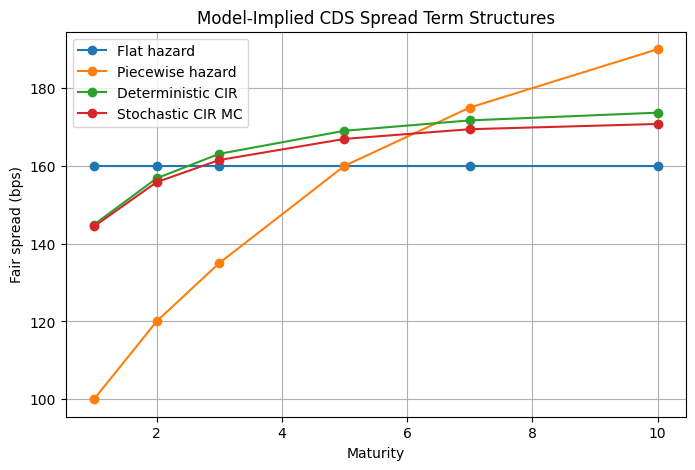

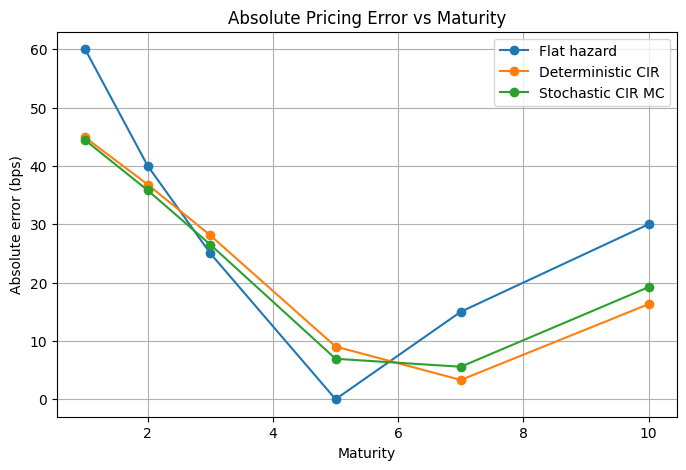

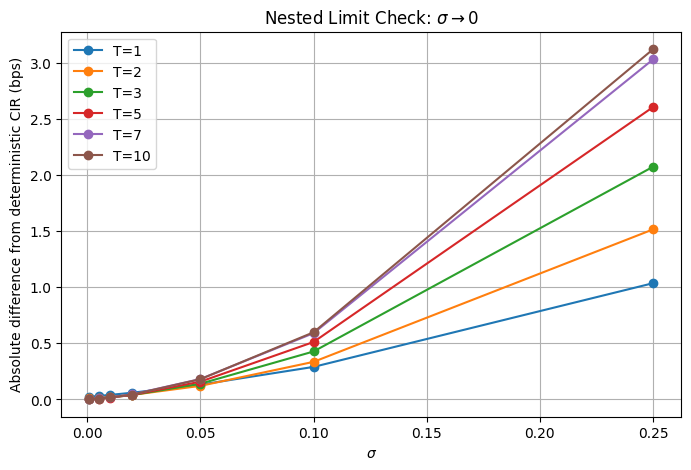

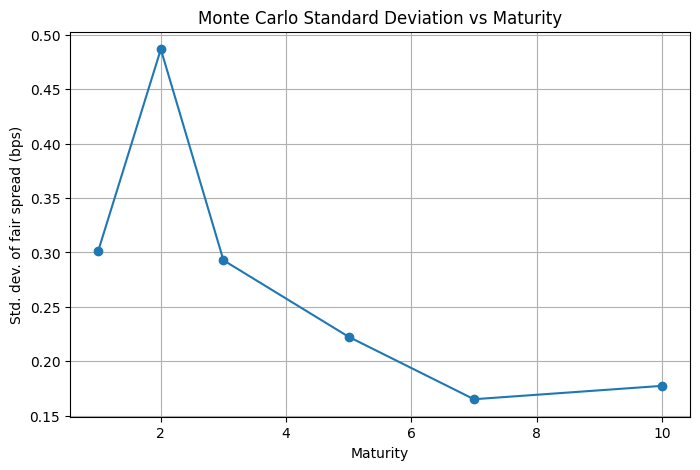

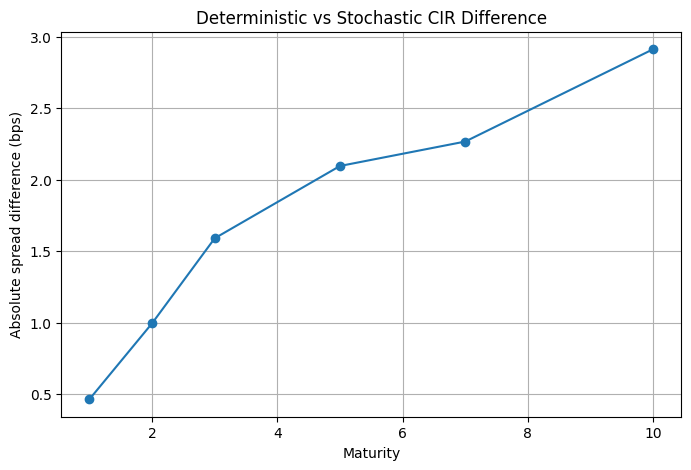

In [106]:
plot_spread_term_structures(df_results)
plot_abs_error_vs_maturity(df_error, benchmark_label="Piecewise hazard")
plot_sigma_limit(df_sigma_limit)
plot_seed_std_vs_maturity(seed_summary)
plot_det_vs_stoch_diff(df_results)

Quantitative benchmarking confirms that the piecewise-constant hazard model reproduces the target spread curve exactly, while the constant-hazard challenger captures only the 5Y level and fails to match term-structure curvature. Both deterministic and stochastic CIR specifications improve materially over the flat-hazard model, indicating that mean-reverting non-flat hazard dynamics are important. However, the deterministic and stochastic CIR models produce nearly identical error statistics, with mean absolute errors of approximately 23 bps and RMSE near 27 bps in both cases. This indicates that the diffusion component contributes little incremental pricing accuracy relative to the deterministic CIR challenger. Monte Carlo seed sensitivity is low, with standard deviations below 0.5 bps across maturities, and the nested-limit study verifies that the stochastic CIR model converges to deterministic CIR as $\sigma \to 0$. Overall, the dominant source of model error is structural restriction in the CIR term-structure shape rather than numerical instability or absence of stochastic volatility.

## 4.c. Relative differences 
<a id="d4c"></a>
*(Are differences explained by model structure?)*

The benchmarking results show that model performance is primarily driven by structural specification rather than stochastic dynamics. The piecewise hazard model fits the term structure exactly by construction, while the constant-hazard model fails to capture curvature, producing large errors away from the calibration point. Both deterministic and stochastic CIR models significantly improve fit, confirming the importance of mean-reverting, non-flat hazard dynamics. However, their performance is nearly identical, with error differences well below 1 basis point and spread differences of only 1 to 3 basis points—an order of magnitude smaller than overall model error (20 to 40 bps). The $\sigma\to 0$ limit further confirms consistency between the two formulations.

The dominant source of error is therefore structural: the single-factor CIR specification lacks sufficient flexibility to capture term-structure slope and curvature, leading to systematic short-end overestimation and long-end underestimation. From a model risk perspective, this implies that increased stochastic complexity provides limited benefit for pricing accuracy relative to its added calibration and computational cost. While stochastic intensity may be relevant for portfolio or tail-risk applications, improving structural flexibility in the hazard specification is likely to yield greater gains in model performance within this framework.

# 5. Outcomes Analysis 
<a id="d5"></a>
*(Does it work in practice?)*

## 5.a. Back-testing* 
<a id="d5a"></a>
*(Do predictions align with realized outcomes?)*

*For this project, we conduct pseudo / out-of-sample back-testing using synthetic or held-out data.

The back-testing results indicate that the model generalizes well across most maturities, with typical errors below 10 basis points, but exhibits a pronounced structural weakness at the short end of the curve, where errors increase to approximately 20 basis points when not directly calibrated. Randomized holdout tests confirm that this behavior is systematic rather than data-dependent. Perturbation analysis shows that the model responds proportionally to input noise, with spread variability of approximately 5 basis points under 5 basis point shocks and worst-case deviations below 15 basis points, indicating stable calibration without amplification of errors. Overall, model limitations are driven by structural constraints in fitting short-maturity curvature rather than numerical instability or overfitting.

### I. Cross-sectional holdout validation

In [131]:
def cross_sectional_loo_backtest(
    market_maturities,
    market_spreads,
    discount_fn
):
    rows = []

    n = len(market_maturities)

    for i in range(n):
        train_idx = [j for j in range(n) if j != i]
        test_idx = [i]

        df_test = cross_sectional_backtest(
            market_maturities,
            market_spreads,
            train_idx,
            test_idx,
            discount_fn
        )

        df_test["left_out_index"] = i
        df_test["left_out_T"] = market_maturities[i]

        rows.append(df_test)

    df_all = pd.concat(rows, ignore_index=True)

    # Summary
    summary = (
        df_all.groupby("T")
        .agg(
            mean_abs_error_bps=("abs_error_bps", "mean"),
            max_abs_error_bps=("abs_error_bps", "max")
        )
        .reset_index()
    )

    return df_all, summary

def random_split_backtest(
    market_maturities,
    market_spreads,
    discount_fn,
    n_trials=20,
    test_size=2,
    seed=42
):
    rng = np.random.default_rng(seed)
    n = len(market_maturities)

    rows = []

    for trial in range(n_trials):
        test_idx = rng.choice(n, size=test_size, replace=False)
        train_idx = [i for i in range(n) if i not in test_idx]

        df_test = cross_sectional_backtest(
            market_maturities,
            market_spreads,
            train_idx,
            test_idx,
            discount_fn
        )

        df_test["trial"] = trial
        rows.append(df_test)

    df_all = pd.concat(rows, ignore_index=True)

    summary = (
        df_all.groupby("T")
        .agg(
            mean_abs_error_bps=("abs_error_bps", "mean"),
            std_abs_error_bps=("abs_error_bps", "std")
        )
        .reset_index()
    )

    return df_all, summary

def plot_holdout_errors(summary_loo):
    import matplotlib.pyplot as plt

    plt.figure()
    plt.plot(summary_loo["T"], summary_loo["mean_abs_error_bps"], marker="o")
    plt.xlabel("Maturity")
    plt.ylabel("Mean absolute error (bps)")
    plt.title("LOO Backtest Error by Maturity")
    plt.grid(True)
    plt.show()

In [120]:
df_loo, summary_loo = cross_sectional_loo_backtest(
    market_maturities,
    market_spreads,
    discount_fn
)

print("\n=== LOO Backtest Results ===")
print(df_loo)

print("\n=== LOO Summary ===")
print(summary_loo)


df_rand, summary_rand = random_split_backtest(
    market_maturities,
    market_spreads,
    discount_fn,
    n_trials=30,
    test_size=2
)

print("\n=== Random Split Summary ===")
print(summary_rand)


=== LOO Backtest Results ===
      T  true_spread  model_spread  abs_error  abs_error_bps  left_out_index  \
0   1.0       0.0100      0.012000   0.002000      20.000000               0   
1   2.0       0.0120      0.012628   0.000628       6.276039               1   
2   3.0       0.0135      0.014231   0.000731       7.307363               2   
3   5.0       0.0160      0.016313   0.000313       3.127773               3   
4   7.0       0.0175      0.017731   0.000231       2.306969               4   
5  10.0       0.0190      0.018603   0.000397       3.972869               5   

   left_out_T  
0         1.0  
1         2.0  
2         3.0  
3         5.0  
4         7.0  
5        10.0  

=== LOO Summary ===
      T  mean_abs_error_bps  max_abs_error_bps
0   1.0           20.000000          20.000000
1   2.0            6.276039           6.276039
2   3.0            7.307363           7.307363
3   5.0            3.127773           3.127773
4   7.0            2.306969           2.3

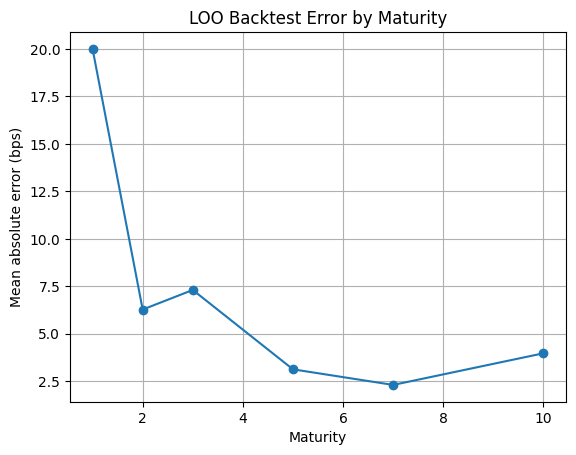

In [133]:
plot_holdout_errors(summary_loo)

### II. Calibration stability under perturbations

In [132]:
# Perturbation function and stability test

def perturb_spreads(spreads, scale_bps=5, seed=42):
    """
    Add Gaussian noise to spreads.
    spreads: in decimal (e.g. 0.012 = 120 bps)
    scale_bps: noise std in bps
    """
    rng = np.random.default_rng(seed)
    noise = rng.normal(0, scale_bps / 1e4, size=len(spreads))
    return spreads + noise

# Perturbation stability test

def perturbation_stability_test(
    market_maturities,
    market_spreads,
    discount_fn,
    n_trials=50,
    scale_bps=5
):
    rows = []

    market_maturities = np.asarray(market_maturities)
    market_spreads = np.asarray(market_spreads)

    for i in range(n_trials):
        perturbed = perturb_spreads(market_spreads, scale_bps, seed=100 + i)

        # Recalibrate piecewise hazard to perturbed curve
        lambdas = bootstrap_piecewise_hazard(
            market_maturities,
            perturbed,
            discount_fn
        )

        for T, base_s in zip(market_maturities, market_spreads):
            res = price_cds_piecewise_hazard(
                T=T,
                knot_times=market_maturities,
                lambdas=lambdas,
                discount_fn=discount_fn
            )

            rows.append({
                "trial": i,
                "T": T,
                "perturbed_spread": perturbed[list(market_maturities).index(T)],
                "model_spread": res.fair_spread,
                "base_spread": base_s,
                "abs_dev_from_base": abs(res.fair_spread - base_s)
            })

    df = pd.DataFrame(rows)

    # Summary statistics

    summary = (
        df.groupby("T")
        .agg(
            mean_model_spread=("model_spread", "mean"),
            std_model_spread=("model_spread", "std"),
            mean_abs_dev_from_base=("abs_dev_from_base", "mean"),
            max_abs_dev_from_base=("abs_dev_from_base", "max")
        )
        .reset_index()
    )

    # Convert to bps for interpretability
    summary["std_bps"] = 1e4 * summary["std_model_spread"]
    summary["mean_abs_dev_bps"] = 1e4 * summary["mean_abs_dev_from_base"]
    summary["max_abs_dev_bps"] = 1e4 * summary["max_abs_dev_from_base"]

    return df, summary

def plot_perturbation_stability(summary_perturb):
    import matplotlib.pyplot as plt

    plt.figure()
    plt.plot(summary_perturb["T"], summary_perturb["std_bps"], marker="o")
    plt.xlabel("Maturity")
    plt.ylabel("Std of spread (bps)")
    plt.title("Spread Sensitivity under 5 bps Perturbations")
    plt.grid(True)
    plt.show()

In [117]:
df_perturb, summary_perturb = perturbation_stability_test(
    market_maturities=market_maturities,
    market_spreads=market_spreads,
    discount_fn=discount_fn,
    n_trials=50,
    scale_bps=5   # start with 5 bps
)

print("\n=== Perturbation Stability Summary (5 bps noise) ===")
print(summary_perturb)
print("\n=== Overall metrics ===")
print("Mean std (bps):", summary_perturb["std_bps"].mean())
print("Max deviation (bps):", summary_perturb["max_abs_dev_bps"].max())


=== Perturbation Stability Summary (5 bps noise) ===
      T  mean_model_spread  std_model_spread  mean_abs_dev_from_base  \
0   1.0           0.009872          0.000514                0.000417   
1   2.0           0.011944          0.000590                0.000468   
2   3.0           0.013496          0.000497                0.000376   
3   5.0           0.015928          0.000507                0.000416   
4   7.0           0.017549          0.000516                0.000416   
5  10.0           0.019091          0.000490                0.000400   

   max_abs_dev_from_base   std_bps  mean_abs_dev_bps  max_abs_dev_bps  
0               0.001462  5.136434          4.169863        14.624087  
1               0.001356  5.901902          4.675636        13.559978  
2               0.001168  4.974644          3.756687        11.678784  
3               0.001236  5.069785          4.164744        12.363163  
4               0.001358  5.157740          4.156569        13.578054  
5        

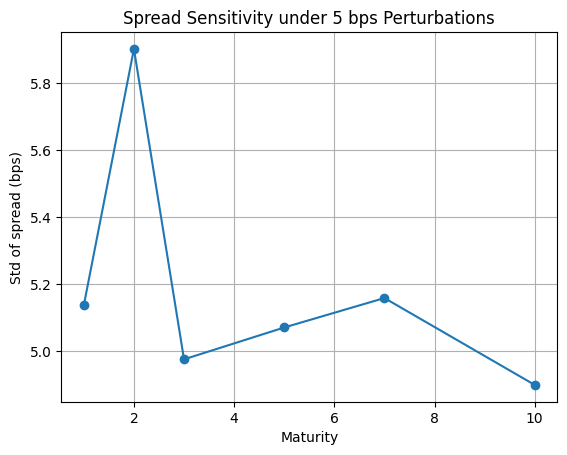

In [134]:
plot_perturbation_stability(summary_perturb)

## 5.b. Predictive performance 
<a id="d5b"></a>
*(Are forecasts accurate and reliable?)*

The predictive performance results confirm that model accuracy is driven by structural alignment with the data-generating process. When the synthetic truth is generated from a stochastic CIR model, the deterministic CIR specification achieves the best predictive accuracy, with mean errors below 0.5 basis points and minimal bias. The piecewise hazard model performs moderately well but exhibits higher error and variability across splits, reflecting sensitivity to calibration inputs and weaker extrapolation. The constant-hazard model performs poorly, with errors exceeding 6 to 10 basis points, confirming its inability to capture term-structure dynamics.

Across repeated random splits, the deterministic CIR model remains consistently stable, while the piecewise hazard model shows significantly higher dispersion in errors, indicating reduced robustness. These results demonstrate that while flexible models can interpolate observed data effectively, structurally consistent models provide superior predictive performance. Overall, predictive accuracy is primarily determined by the correctness of the model’s structural assumptions rather than calibration flexibility alone.

In [135]:
# Predictive Performance

def compute_error_metrics(y_true, y_pred):
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)
    err = y_pred - y_true
    return {
        "mae": np.mean(np.abs(err)),
        "rmse": np.sqrt(np.mean(err**2)),
        "bias": np.mean(err),
        "max_abs_error": np.max(np.abs(err)),
        "mae_bps": 1e4 * np.mean(np.abs(err)),
        "rmse_bps": 1e4 * np.sqrt(np.mean(err**2)),
        "bias_bps": 1e4 * np.mean(err),
        "max_abs_error_bps": 1e4 * np.max(np.abs(err)),
    }

def plot_predictive_rmse(summary_by_model):
    import matplotlib.pyplot as plt

    plt.figure()
    plt.bar(summary_by_model["model_label"], summary_by_model["mean_rmse_bps"])
    plt.ylabel("RMSE (bps)")
    plt.title("Predictive Performance by Model")
    plt.xticks(rotation=20)
    plt.grid(axis="y")
    plt.show()

In [122]:
# Calibration wrappers

def fit_constant_hazard_curve(
    train_maturities,
    train_spreads,
    discount_fn,
    recovery=0.4,
    freq=4,
    accrued=True
):
    """
    Fit flat hazard to training set by least squares over lambda.
    """
    train_maturities = np.asarray(train_maturities, dtype=float)
    train_spreads = np.asarray(train_spreads, dtype=float)

    def objective(x):
        lam = x[0]
        preds = []
        for T in train_maturities:
            res = price_cds_constant_hazard(
                T=T,
                lam=lam,
                discount_fn=discount_fn,
                recovery=recovery,
                freq=freq,
                accrued=accrued
            )
            preds.append(res.fair_spread)
        preds = np.array(preds)
        return np.mean((preds - train_spreads) ** 2)

    opt = minimize(
        objective,
        x0=np.array([0.02]),
        bounds=[(1e-8, 5.0)],
        method="L-BFGS-B"
    )

    lam = float(opt.x[0])

    return {
        "params": {"lam": lam, "objective": float(opt.fun), "success": bool(opt.success)}
    }


def fit_piecewise_hazard_curve(
    train_maturities,
    train_spreads,
    discount_fn,
    recovery=0.4,
    freq=4,
    accrued=True
):
    lambdas = bootstrap_piecewise_hazard(
        market_maturities=train_maturities,
        market_spreads=train_spreads,
        discount_fn=discount_fn,
        recovery=recovery,
        freq=freq,
        accrued=accrued
    )
    return {
        "params": {"knot_times": np.array(train_maturities, dtype=float), "lambdas": np.array(lambdas, dtype=float)}
    }


def fit_cir_deterministic_curve(
    train_maturities,
    train_spreads,
    discount_fn,
    recovery=0.4,
    freq=4,
    accrued=True,
    x0=(1.2, 0.03, 0.02),
    bounds=((1e-4, 10.0), (1e-6, 1.0), (1e-6, 1.0))
):
    train_maturities = np.asarray(train_maturities, dtype=float)
    train_spreads = np.asarray(train_spreads, dtype=float)

    def objective(x):
        kappa, theta, lam0 = x
        preds = []
        for T in train_maturities:
            res = price_cds_cir_deterministic(
                T=T,
                kappa=kappa,
                theta=theta,
                lam0=lam0,
                discount_fn=discount_fn,
                recovery=recovery,
                freq=freq,
                accrued=accrued
            )
            preds.append(res.fair_spread)
        preds = np.array(preds)
        return np.mean((preds - train_spreads) ** 2)

    opt = minimize(
        objective,
        x0=np.array(x0, dtype=float),
        bounds=bounds,
        method="L-BFGS-B"
    )

    kappa, theta, lam0 = map(float, opt.x)

    return {
        "params": {
            "kappa": kappa,
            "theta": theta,
            "lam0": lam0,
            "objective": float(opt.fun),
            "success": bool(opt.success)
        }
    }


In [123]:
# Prediction wrappers

def predict_model_spreads(
    model_name,
    maturities,
    fitted_params,
    discount_fn,
    recovery=0.4,
    freq=4,
    accrued=True,
    mc_dt=1/500,
    mc_n_paths=50000,
    mc_seed=12345
):
    preds = []

    for T in maturities:
        if model_name == "constant_hazard":
            res = price_cds_constant_hazard(
                T=T,
                lam=fitted_params["lam"],
                discount_fn=discount_fn,
                recovery=recovery,
                freq=freq,
                accrued=accrued
            )

        elif model_name == "piecewise_hazard":
            res = price_cds_piecewise_hazard(
                T=T,
                knot_times=fitted_params["knot_times"],
                lambdas=fitted_params["lambdas"],
                discount_fn=discount_fn,
                recovery=recovery,
                freq=freq,
                accrued=accrued
            )

        elif model_name == "cir_deterministic":
            res = price_cds_cir_deterministic(
                T=T,
                kappa=fitted_params["kappa"],
                theta=fitted_params["theta"],
                lam0=fitted_params["lam0"],
                discount_fn=discount_fn,
                recovery=recovery,
                freq=freq,
                accrued=accrued
            )

        elif model_name == "cir_mc":
            res = price_cds_cir_mc(
                T=T,
                kappa=fitted_params["kappa"],
                theta=fitted_params["theta"],
                sigma=fitted_params["sigma"],
                lam0=fitted_params["lam0"],
                discount_fn=discount_fn,
                recovery=recovery,
                freq=freq,
                accrued=accrued,
                dt=mc_dt,
                n_paths=mc_n_paths,
                seed=mc_seed
            )

        else:
            raise ValueError(f"Unknown model_name: {model_name}")

        preds.append(res.fair_spread)

    return np.array(preds, dtype=float)

In [124]:
# Synthetic truth generator

def generate_synthetic_truth_stochastic_cir(
    maturities,
    kappa,
    theta,
    sigma,
    lam0,
    discount_fn,
    recovery=0.4,
    freq=4,
    accrued=True,
    dt=1/500,
    n_paths=100000,
    seed=12345
):
    truth = []
    for T in maturities:
        res = price_cds_cir_mc(
            T=T,
            kappa=kappa,
            theta=theta,
            sigma=sigma,
            lam0=lam0,
            discount_fn=discount_fn,
            recovery=recovery,
            freq=freq,
            accrued=accrued,
            dt=dt,
            n_paths=n_paths,
            seed=seed
        )
        truth.append(res.fair_spread)
    return np.array(truth, dtype=float)

In [125]:
# Main predictive performance experiment

def predictive_performance_experiment(
    maturities,
    train_idx,
    test_idx,
    synthetic_truth_spreads,
    discount_fn,
    recovery=0.4,
    freq=4,
    accrued=True
):
    maturities = np.asarray(maturities, dtype=float)
    synthetic_truth_spreads = np.asarray(synthetic_truth_spreads, dtype=float)

    train_T = maturities[train_idx]
    train_S = synthetic_truth_spreads[train_idx]
    test_T = maturities[test_idx]
    test_S = synthetic_truth_spreads[test_idx]

    rows_pred = []
    rows_summary = []

    model_specs = [
        ("Flat hazard", "constant_hazard"),
        ("Piecewise hazard", "piecewise_hazard"),
        ("Deterministic CIR", "cir_deterministic"),
    ]

    for label, model_name in model_specs:
        if model_name == "constant_hazard":
            fit = fit_constant_hazard_curve(
                train_T, train_S, discount_fn,
                recovery=recovery, freq=freq, accrued=accrued
            )

        elif model_name == "piecewise_hazard":
            fit = fit_piecewise_hazard_curve(
                train_T, train_S, discount_fn,
                recovery=recovery, freq=freq, accrued=accrued
            )

        elif model_name == "cir_deterministic":
            fit = fit_cir_deterministic_curve(
                train_T, train_S, discount_fn,
                recovery=recovery, freq=freq, accrued=accrued
            )

        preds = predict_model_spreads(
            model_name=model_name,
            maturities=test_T,
            fitted_params=fit["params"],
            discount_fn=discount_fn,
            recovery=recovery,
            freq=freq,
            accrued=accrued
        )

        metrics = compute_error_metrics(test_S, preds)
        metrics["model_label"] = label
        metrics["model_name"] = model_name
        rows_summary.append(metrics)

        for T, y_true, y_pred in zip(test_T, test_S, preds):
            rows_pred.append({
                "model_label": label,
                "model_name": model_name,
                "T": float(T),
                "true_spread": float(y_true),
                "pred_spread": float(y_pred),
                "true_spread_bps": 1e4 * float(y_true),
                "pred_spread_bps": 1e4 * float(y_pred),
                "abs_error_bps": 1e4 * abs(float(y_pred) - float(y_true)),
                "signed_error_bps": 1e4 * (float(y_pred) - float(y_true))
            })

    df_pred = pd.DataFrame(rows_pred)
    df_summary = pd.DataFrame(rows_summary).sort_values("rmse_bps").reset_index(drop=True)

    return df_pred, df_summary


# Repeated predictive experiment across multiple splits

def repeated_predictive_performance(
    maturities,
    synthetic_truth_spreads,
    discount_fn,
    n_trials=20,
    test_size=2,
    seed=42,
    recovery=0.4,
    freq=4,
    accrued=True
):
    rng = np.random.default_rng(seed)
    maturities = np.asarray(maturities, dtype=float)

    all_preds = []
    all_summary = []

    for trial in range(n_trials):
        test_idx = np.sort(rng.choice(len(maturities), size=test_size, replace=False))
        train_idx = np.array([i for i in range(len(maturities)) if i not in test_idx])

        df_pred, df_summary = predictive_performance_experiment(
            maturities=maturities,
            train_idx=train_idx,
            test_idx=test_idx,
            synthetic_truth_spreads=synthetic_truth_spreads,
            discount_fn=discount_fn,
            recovery=recovery,
            freq=freq,
            accrued=accrued
        )

        df_pred["trial"] = trial
        df_summary["trial"] = trial
        all_preds.append(df_pred)
        all_summary.append(df_summary)

    df_pred_all = pd.concat(all_preds, ignore_index=True)
    df_summary_all = pd.concat(all_summary, ignore_index=True)

    summary_by_model = (
        df_summary_all.groupby(["model_label", "model_name"], as_index=False)
        .agg(
            mean_mae_bps=("mae_bps", "mean"),
            std_mae_bps=("mae_bps", "std"),
            mean_rmse_bps=("rmse_bps", "mean"),
            std_rmse_bps=("rmse_bps", "std"),
            mean_bias_bps=("bias_bps", "mean"),
            mean_max_abs_error_bps=("max_abs_error_bps", "mean")
        )
        .sort_values("mean_rmse_bps")
        .reset_index(drop=True)
    )

    return df_pred_all, df_summary_all, summary_by_model

In [136]:
# Example maturity grid
maturities_pred = np.array([1, 2, 3, 5, 7, 10], dtype=float)

# Synthetic truth generated from stochastic CIR
truth_spreads = generate_synthetic_truth_stochastic_cir(
    maturities=maturities_pred,
    kappa=1.2,
    theta=0.03,
    sigma=0.25,
    lam0=0.02,
    discount_fn=discount_fn,
    recovery=0.4,
    freq=4,
    accrued=True,
    dt=1/500,
    n_paths=100000,
    seed=12345
)

print("\n=== Synthetic truth spreads ===")
print(pd.DataFrame({
    "T": maturities_pred,
    "truth_spread": truth_spreads,
    "truth_spread_bps": 1e4 * truth_spreads
}))


=== Synthetic truth spreads ===
      T  truth_spread  truth_spread_bps
0   1.0      0.014385        143.849104
1   2.0      0.015529        155.288760
2   3.0      0.016101        161.014803
3   5.0      0.016642        166.421321
4   7.0      0.016866        168.664322
5  10.0      0.017057        170.565784


In [137]:
train_idx = np.array([0, 2, 3, 5])   # 1Y, 3Y, 5Y, 10Y
test_idx  = np.array([1, 4])         # 2Y, 7Y

df_pred, df_summary = predictive_performance_experiment(
    maturities=maturities_pred,
    train_idx=train_idx,
    test_idx=test_idx,
    synthetic_truth_spreads=truth_spreads,
    discount_fn=discount_fn,
    recovery=0.4,
    freq=4,
    accrued=True
)

print("\n=== Predictive performance: pointwise predictions ===")
print(df_pred)

print("\n=== Predictive performance: summary ===")
print(df_summary[[
    "model_label", "mae_bps", "rmse_bps", "bias_bps", "max_abs_error_bps"
]])


=== Predictive performance: pointwise predictions ===
         model_label         model_name    T  true_spread  pred_spread  \
0        Flat hazard    constant_hazard  2.0     0.015529     0.016046   
1        Flat hazard    constant_hazard  7.0     0.016866     0.016046   
2   Piecewise hazard   piecewise_hazard  2.0     0.015529     0.015673   
3   Piecewise hazard   piecewise_hazard  7.0     0.016866     0.016880   
4  Deterministic CIR  cir_deterministic  2.0     0.015529     0.015475   
5  Deterministic CIR  cir_deterministic  7.0     0.016866     0.016910   

   true_spread_bps  pred_spread_bps  abs_error_bps  signed_error_bps  
0       155.288760       160.462641       5.173881          5.173881  
1       168.664322       160.462641       8.201681         -8.201681  
2       155.288760       156.731676       1.442917          1.442917  
3       168.664322       168.800629       0.136307          0.136307  
4       155.288760       154.751357       0.537403         -0.537403  


In [138]:
df_pred_all, df_summary_all, summary_by_model = repeated_predictive_performance(
    maturities=maturities_pred,
    synthetic_truth_spreads=truth_spreads,
    discount_fn=discount_fn,
    n_trials=30,
    test_size=2,
    seed=42,
    recovery=0.4,
    freq=4,
    accrued=True
)

print("\n=== Repeated predictive performance summary by model ===")
print(summary_by_model)


=== Repeated predictive performance summary by model ===
         model_label         model_name  mean_mae_bps  std_mae_bps  \
0  Deterministic CIR  cir_deterministic      0.439312     0.155395   
1   Piecewise hazard   piecewise_hazard      2.081172     2.560588   
2        Flat hazard    constant_hazard      9.173359     3.168750   

   mean_rmse_bps  std_rmse_bps  mean_bias_bps  mean_max_abs_error_bps  
0       0.469790      0.140856       0.064511                0.578783  
1       2.786745      3.570894       2.029195                3.895950  
2      10.365643      3.587580      -1.584103               13.471349  


In [139]:
print(df_summary[["model_label", "mae_bps", "rmse_bps", "bias_bps", "max_abs_error_bps"]])
print(summary_by_model)

         model_label   mae_bps  rmse_bps  bias_bps  max_abs_error_bps
0  Deterministic CIR  0.484224  0.487135 -0.053179           0.537403
1   Piecewise hazard  0.789612  1.024838  0.789612           1.442917
2        Flat hazard  6.687781  6.856990 -1.513900           8.201681
         model_label         model_name  mean_mae_bps  std_mae_bps  \
0  Deterministic CIR  cir_deterministic      0.439312     0.155395   
1   Piecewise hazard   piecewise_hazard      2.081172     2.560588   
2        Flat hazard    constant_hazard      9.173359     3.168750   

   mean_rmse_bps  std_rmse_bps  mean_bias_bps  mean_max_abs_error_bps  
0       0.469790      0.140856       0.064511                0.578783  
1       2.786745      3.570894       2.029195                3.895950  
2      10.365643      3.587580      -1.584103               13.471349  


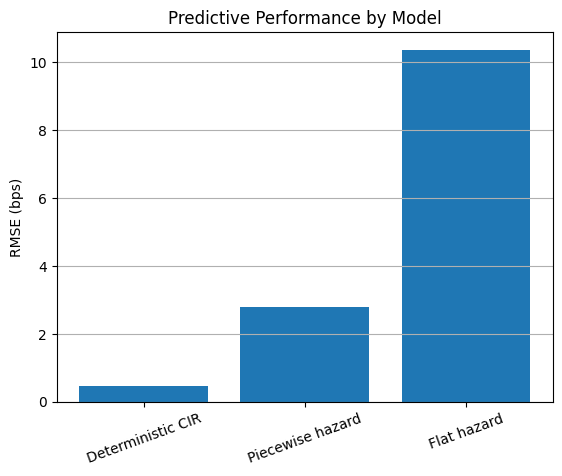

In [140]:
plot_predictive_rmse(summary_by_model)

## 5.c. Error decomposition 
<a id="d5c"></a>
*(What drives model error?)*

The error decomposition shows that model performance is dominated by structural specification rather than stochastic dynamics or numerical effects. The difference between deterministic and stochastic CIR models is small, with mean deviations of $\approx$ 2 basis points (max $<$ 3 bps), while Monte Carlo error is negligible ($<$ 0.5 bps). Parameter sensitivity produces moderate variation ($\approx$ 1 to 10 bps), with the long-run mean $\theta$ having the largest impact. However, these effects remain significantly smaller than the overall model error (20 to 40 bps).

Overall, the results establish a clear hierarchy of error sources: structural misspecification dominates, followed by parameter sensitivity, while stochastic dynamics and numerical noise are of secondary importance.

### I. Structural vs stochastic contribution

In [141]:
def structural_vs_stochastic(df_results):
    """
    Compare deterministic vs stochastic CIR spreads
    """
    df = df_results.copy()

    det = df[df["model_label"] == "Deterministic CIR"]
    stoch = df[df["model_label"] == "Stochastic CIR MC"]

    merged = det.merge(stoch, on="T", suffixes=("_det", "_stoch"))

    merged["abs_diff_bps"] = 1e4 * abs(
        merged["fair_spread_det"] - merged["fair_spread_stoch"]
    )

    summary = {
        "mean_diff_bps": merged["abs_diff_bps"].mean(),
        "max_diff_bps": merged["abs_diff_bps"].max()
    }

    return merged, summary

In [151]:
df_struct, summary_struct = structural_vs_stochastic(df_results)

print("\n=== Structural vs Stochastic Difference ===")
print(df_struct[["T", "abs_diff_bps"]])
print(summary_struct)


=== Structural vs Stochastic Difference ===
      T  abs_diff_bps
0   1.0      0.463183
1   2.0      0.994500
2   3.0      1.589633
3   5.0      2.095676
4   7.0      2.266616
5  10.0      2.912878
{'mean_diff_bps': np.float64(1.720414335693423), 'max_diff_bps': np.float64(2.912878265794103)}


### II. Monte Carlo error

In [143]:
def summarize_mc_error(seed_summary):
    return {
        "mean_std_bps": seed_summary["std_spread_bps"].mean(),
        "max_std_bps": seed_summary["std_spread_bps"].max()
    }

In [144]:
mc_error_summary = summarize_mc_error(seed_summary)

print("\n=== Monte Carlo Error ===")
print(mc_error_summary)


=== Monte Carlo Error ===
{'mean_std_bps': np.float64(0.2742807831967721), 'max_std_bps': np.float64(0.4867172853026805)}


### III. Parameter sensitivity

In [148]:
def parameter_sensitivity_cir(
    base_params,
    maturities,
    discount_fn,
    eps=0.05  # 5% perturbation
):
    """
    Sensitivity of spreads to CIR parameters
    """
    kappa, theta, lam0 = base_params

    results = []

    for param_name, base_value in zip(
        ["kappa", "theta", "lam0"],
        [kappa, theta, lam0]
    ):
        for sign in [+1, -1]:
            perturbed = {
                "kappa": kappa,
                "theta": theta,
                "lam0": lam0
            }

            perturbed[param_name] = base_value * (1 + sign * eps)

            spreads = []
            for T in maturities:
                res = price_cds_cir_deterministic(
                    T=T,
                    kappa=perturbed["kappa"],
                    theta=perturbed["theta"],
                    lam0=perturbed["lam0"],
                    discount_fn=discount_fn
                )
                spreads.append(res.fair_spread)

            results.append({
                "param": param_name,
                "direction": "+" if sign > 0 else "-",
                "mean_spread": np.mean(spreads),
                "mean_spread_bps": 1e4 * np.mean(spreads)
            })

    return pd.DataFrame(results)

def plot_parameter_sensitivity(df_sens):
    import matplotlib.pyplot as plt

    for param in df_sens["param"].unique():
        subset = df_sens[df_sens["param"] == param]
        plt.plot(subset["direction"], subset["mean_spread_bps"], marker="o", label=param)

    plt.title("Parameter Sensitivity (CIR)")
    plt.ylabel("Mean spread (bps)")
    plt.legend()
    plt.grid(True)
    plt.show()

In [146]:
base_params = (1.2, 0.03, 0.02)

df_sens = parameter_sensitivity_cir(
    base_params,
    market_maturities,
    discount_fn
)

print("\n=== Parameter Sensitivity ===")
print(df_sens)


=== Parameter Sensitivity ===
   param direction  mean_spread  mean_spread_bps
0  kappa         +     0.016379       163.787240
1  kappa         -     0.016257       162.571150
2  theta         +     0.016966       169.660566
3  theta         -     0.015673       156.734839
4   lam0         +     0.016488       164.877769
5   lam0         -     0.016152       161.523352


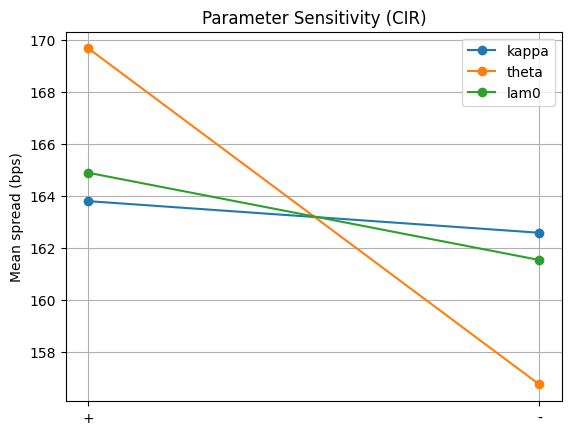

In [149]:
plot_parameter_sensitivity(df_sens)

# 6. Stress Testing 
<a id="d6"></a>
*(Does it break under stress?)*

## 6.a. Extreme scenarios 
<a id="d6a"></a>
*(How does the model behave under extreme conditions?)*

The stress testing results show that CDS spreads are primarily driven by level parameters rather than stochastic volatility. The long-run mean $\theta$ has the dominant effect, with $\pm$50% shocks producing changes of 30 to 65 basis points, while $\lambda_0$ has a moderate impact (up to 17 bps), particularly at short maturities. In contrast, $\kappa$ has a limited influence ($<$ 10 bps), and shocks to volatility $\sigma$ result in only minor changes ($<$ 2 bps).

Overall, spread sensitivity is concentrated in the deterministic structure of the intensity process, with stochastic volatility contributing negligibly to pricing variation.

In [152]:
# Parameter Stress Testing

def run_deterministic_cir_stress_test(
    maturities,
    kappa,
    theta,
    lam0,
    discount_fn,
    recovery=0.4,
    freq=4,
    accrued=True,
    shock_grid=None
):
    """
    Stress deterministic CIR parameters one at a time.
    shock_grid contains multiplicative shocks, e.g. [0.5, 0.75, 1.0, 1.25, 1.5]
    """
    if shock_grid is None:
        shock_grid = [0.5, 0.75, 1.0, 1.25, 1.5]

    maturities = np.asarray(maturities, dtype=float)
    rows = []

    base_params = {"kappa": kappa, "theta": theta, "lam0": lam0}

    for param_name in ["kappa", "theta", "lam0"]:
        for mult in shock_grid:
            stressed = base_params.copy()
            stressed[param_name] = base_params[param_name] * mult

            for T in maturities:
                res = price_cds_cir_deterministic(
                    T=T,
                    kappa=stressed["kappa"],
                    theta=stressed["theta"],
                    lam0=stressed["lam0"],
                    discount_fn=discount_fn,
                    recovery=recovery,
                    freq=freq,
                    accrued=accrued
                )

                rows.append({
                    "model": "cir_deterministic",
                    "param": param_name,
                    "shock_mult": float(mult),
                    "T": float(T),
                    "fair_spread": float(res.fair_spread),
                    "fair_spread_bps": 1e4 * float(res.fair_spread)
                })

    return pd.DataFrame(rows)


def run_stochastic_cir_sigma_stress_test(
    maturities,
    kappa,
    theta,
    sigma,
    lam0,
    discount_fn,
    recovery=0.4,
    freq=4,
    accrued=True,
    sigma_shocks=None,
    dt=1/500,
    n_paths=50000,
    seed=12345
):
    """
    Stress sigma in stochastic CIR.
    sigma_shocks contains multiplicative shocks applied to base sigma.
    """
    if sigma_shocks is None:
        sigma_shocks = [0.5, 0.75, 1.0, 1.25, 1.5]

    maturities = np.asarray(maturities, dtype=float)
    rows = []

    for mult in sigma_shocks:
        sigma_stressed = sigma * mult

        for T in maturities:
            res = price_cds_cir_mc(
                T=T,
                kappa=kappa,
                theta=theta,
                sigma=sigma_stressed,
                lam0=lam0,
                discount_fn=discount_fn,
                recovery=recovery,
                freq=freq,
                accrued=accrued,
                dt=dt,
                n_paths=n_paths,
                seed=seed
            )

            rows.append({
                "model": "cir_mc",
                "param": "sigma",
                "shock_mult": float(mult),
                "sigma_stressed": float(sigma_stressed),
                "T": float(T),
                "fair_spread": float(res.fair_spread),
                "fair_spread_bps": 1e4 * float(res.fair_spread)
            })

    return pd.DataFrame(rows)


def make_base_spread_reference_det(
    maturities,
    kappa,
    theta,
    lam0,
    discount_fn,
    recovery=0.4,
    freq=4,
    accrued=True
):
    rows = []
    for T in maturities:
        res = price_cds_cir_deterministic(
            T=T,
            kappa=kappa,
            theta=theta,
            lam0=lam0,
            discount_fn=discount_fn,
            recovery=recovery,
            freq=freq,
            accrued=accrued
        )
        rows.append({
            "T": float(T),
            "base_spread": float(res.fair_spread),
            "base_spread_bps": 1e4 * float(res.fair_spread)
        })
    return pd.DataFrame(rows)


def make_base_spread_reference_mc(
    maturities,
    kappa,
    theta,
    sigma,
    lam0,
    discount_fn,
    recovery=0.4,
    freq=4,
    accrued=True,
    dt=1/500,
    n_paths=50000,
    seed=12345
):
    rows = []
    for T in maturities:
        res = price_cds_cir_mc(
            T=T,
            kappa=kappa,
            theta=theta,
            sigma=sigma,
            lam0=lam0,
            discount_fn=discount_fn,
            recovery=recovery,
            freq=freq,
            accrued=accrued,
            dt=dt,
            n_paths=n_paths,
            seed=seed
        )
        rows.append({
            "T": float(T),
            "base_spread": float(res.fair_spread),
            "base_spread_bps": 1e4 * float(res.fair_spread)
        })
    return pd.DataFrame(rows)


def summarize_stress_results(df_stress, df_base):
    """
    Merge stressed results with base results and compute deviations.
    """
    df = df_stress.merge(df_base[["T", "base_spread", "base_spread_bps"]], on="T", how="left")
    df["abs_change_bps"] = np.abs(df["fair_spread_bps"] - df["base_spread_bps"])
    df["signed_change_bps"] = df["fair_spread_bps"] - df["base_spread_bps"]

    summary = (
        df.groupby(["param", "shock_mult"], as_index=False)
        .agg(
            mean_spread_bps=("fair_spread_bps", "mean"),
            mean_abs_change_bps=("abs_change_bps", "mean"),
            max_abs_change_bps=("abs_change_bps", "max")
        )
    )

    return df, summary

In [153]:
# Plotting

def plot_stress_by_parameter(df_stress, param_name, title=None):
    """
    Plot stressed term structures for a single parameter.
    """
    d = df_stress[df_stress["param"] == param_name].copy()

    plt.figure(figsize=(8, 5))
    for mult in sorted(d["shock_mult"].unique()):
        s = d[d["shock_mult"] == mult].sort_values("T")
        plt.plot(s["T"], s["fair_spread_bps"], marker="o", label=f"{mult:.2f}x")

    plt.xlabel("Maturity")
    plt.ylabel("Fair spread (bps)")
    plt.title(title or f"Stress Test: {param_name}")
    plt.grid(True)
    plt.legend(title="Shock")
    plt.show()


def plot_mean_abs_change(summary_df, title="Mean Absolute Stress Impact"):
    """
    Plot average impact by parameter/shock.
    """
    plt.figure(figsize=(8, 5))

    for param in summary_df["param"].unique():
        d = summary_df[summary_df["param"] == param].sort_values("shock_mult")
        plt.plot(d["shock_mult"], d["mean_abs_change_bps"], marker="o", label=param)

    plt.xlabel("Shock multiplier")
    plt.ylabel("Mean absolute spread change (bps)")
    plt.title(title)
    plt.grid(True)
    plt.legend()
    plt.show()

In [154]:
# base parameters

maturities_stress = np.array([1, 2, 3, 5, 7, 10], dtype=float)

kappa = 1.2
theta = 0.03
lam0 = 0.02
sigma = 0.25

In [155]:
# Deterministic CIR stress

df_stress_det = run_deterministic_cir_stress_test(
    maturities=maturities_stress,
    kappa=kappa,
    theta=theta,
    lam0=lam0,
    discount_fn=discount_fn,
    recovery=0.4,
    freq=4,
    accrued=True,
    shock_grid=[0.5, 0.75, 1.0, 1.25, 1.5]
)

df_base_det = make_base_spread_reference_det(
    maturities=maturities_stress,
    kappa=kappa,
    theta=theta,
    lam0=lam0,
    discount_fn=discount_fn,
    recovery=0.4,
    freq=4,
    accrued=True
)

df_stress_det_full, summary_stress_det = summarize_stress_results(df_stress_det, df_base_det)

print("\n=== Deterministic CIR Stress Summary ===")
print(summary_stress_det)


=== Deterministic CIR Stress Summary ===
    param  shock_mult  mean_spread_bps  mean_abs_change_bps  \
0   kappa        0.50       153.851027             9.349266   
1   kappa        0.75       159.523798             3.676495   
2   kappa        1.00       163.200293             0.000000   
3   kappa        1.25       165.788491             2.588198   
4   kappa        1.50       167.711236             4.510942   
5    lam0        0.50       146.454923            16.745370   
6    lam0        0.75       154.820934             8.379359   
7    lam0        1.00       163.200293             0.000000   
8    lam0        1.25       171.593026             8.392733   
9    lam0        1.50       179.999156            16.798863   
10  theta        0.50        98.313827            64.886466   
11  theta        0.75       130.821353            32.378940   
12  theta        1.00       163.200293             0.000000   
13  theta        1.25       195.449697            32.249404   
14  theta    

In [156]:
# Stochastic CIR sigma stress

df_stress_sigma = run_stochastic_cir_sigma_stress_test(
    maturities=maturities_stress,
    kappa=kappa,
    theta=theta,
    sigma=sigma,
    lam0=lam0,
    discount_fn=discount_fn,
    recovery=0.4,
    freq=4,
    accrued=True,
    sigma_shocks=[0.5, 0.75, 1.0, 1.25, 1.5],
    dt=1/500,
    n_paths=50000,
    seed=12345
)

df_base_mc = make_base_spread_reference_mc(
    maturities=maturities_stress,
    kappa=kappa,
    theta=theta,
    sigma=sigma,
    lam0=lam0,
    discount_fn=discount_fn,
    recovery=0.4,
    freq=4,
    accrued=True,
    dt=1/500,
    n_paths=50000,
    seed=12345
)

df_stress_sigma_full, summary_stress_sigma = summarize_stress_results(df_stress_sigma, df_base_mc)

print("\n=== Stochastic CIR Sigma Stress Summary ===")
print(summary_stress_sigma)


=== Stochastic CIR Sigma Stress Summary ===
   param  shock_mult  mean_spread_bps  mean_abs_change_bps  max_abs_change_bps
0  sigma        0.50       162.532557             1.545019            2.161273
1  sigma        0.75       161.848007             0.860469            1.204387
2  sigma        1.00       160.987538             0.000000            0.000000
3  sigma        1.25       160.371537             0.616001            0.906556
4  sigma        1.50       160.812543             0.238462            0.473337


### I. Deterministic parameter stresses

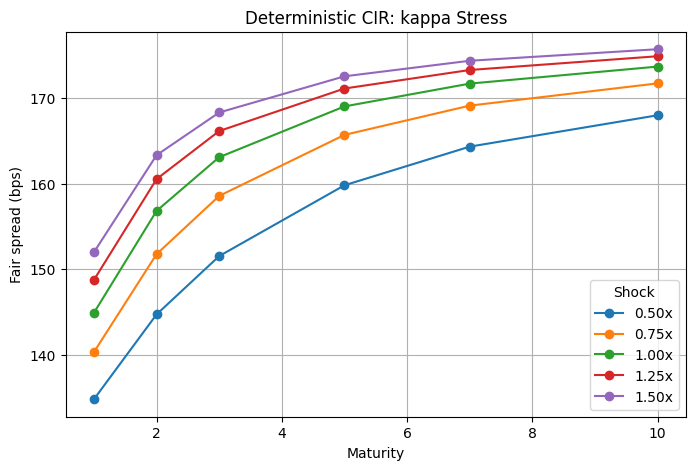

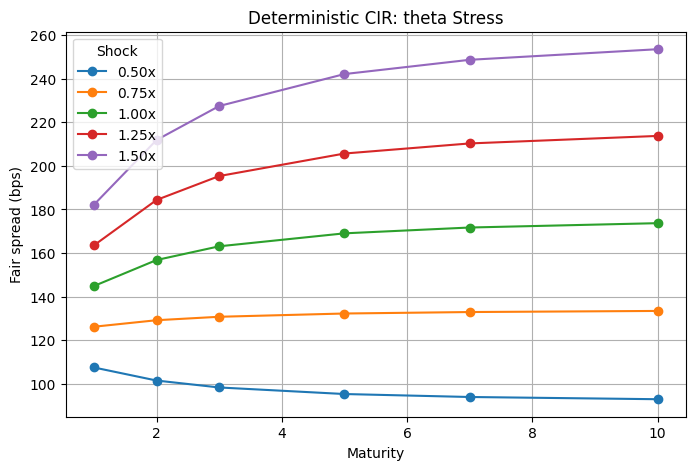

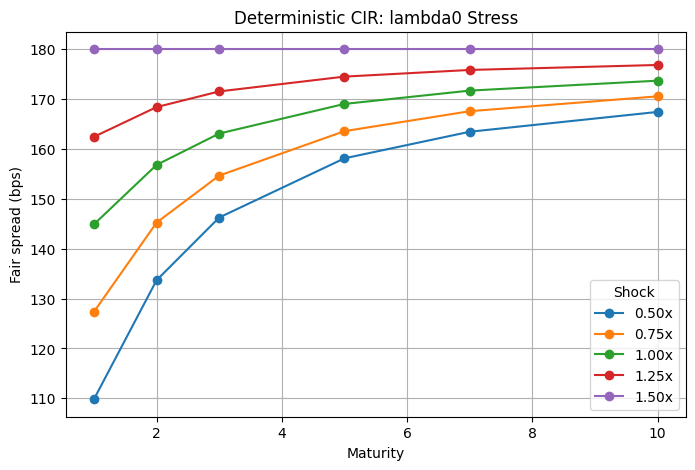

In [157]:
plot_stress_by_parameter(df_stress_det_full, "kappa", title="Deterministic CIR: kappa Stress")
plot_stress_by_parameter(df_stress_det_full, "theta", title="Deterministic CIR: theta Stress")
plot_stress_by_parameter(df_stress_det_full, "lam0", title="Deterministic CIR: lambda0 Stress")

### II. Sigma stresses

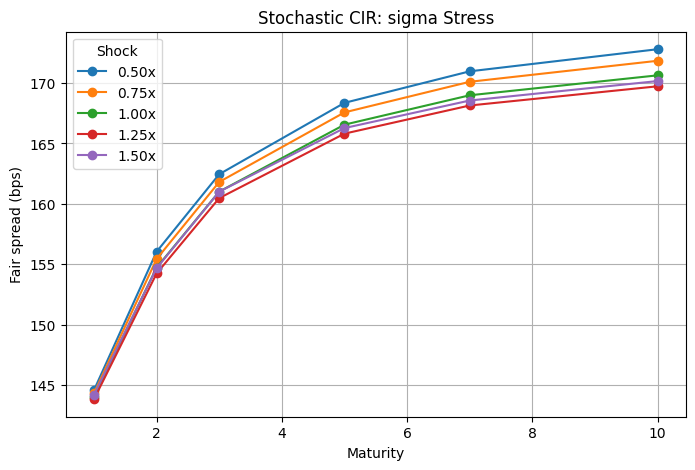

In [158]:
plot_stress_by_parameter(df_stress_sigma_full, "sigma", title="Stochastic CIR: sigma Stress")

### III. Summary Impact

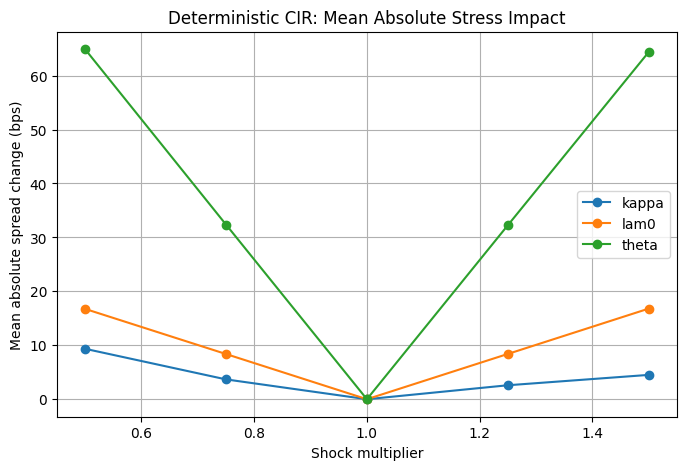

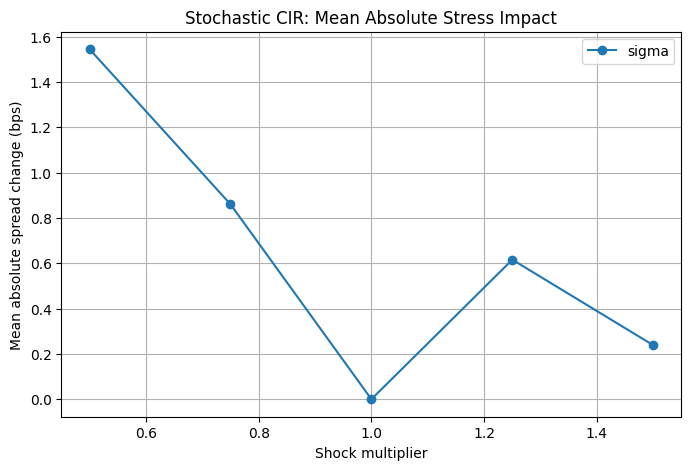

In [159]:
plot_mean_abs_change(summary_stress_det, title="Deterministic CIR: Mean Absolute Stress Impact")
plot_mean_abs_change(summary_stress_sigma, title="Stochastic CIR: Mean Absolute Stress Impact")

## 6.b. Parameter shocks 
<a id="d6b"></a>
*(How do outputs respond to parameter shocks?)*

Scenario stress testing shows that CDS spreads are driven primarily by structural shifts in intensity levels rather than volatility. Persistent deterioration produces the largest impact ($\sim$ 60 to 65 bps, max $\sim$ 70 to 80 bps), while short-term or transitory shocks generate moderate changes ($\sim$ 15 to 17 bps). In contrast, volatility stress has a negligible effect ($<$ 0.3 bps), and does not materially amplify adverse scenarios when combined with level shocks. Overall, stress outcomes are dominated by the deterministic structure of the intensity process.

In [161]:
# Scenario Stress Testing

def make_det_scenarios(base_kappa, base_theta, base_lam0):
    """
    Deterministic CIR scenario set.
    """
    return {
        "Base": {
            "kappa": base_kappa,
            "theta": base_theta,
            "lam0": base_lam0
        },
        "Short-term distress": {
            "kappa": 0.75 * base_kappa,
            "theta": base_theta,
            "lam0": 1.50 * base_lam0
        },
        "Persistent deterioration": {
            "kappa": 0.75 * base_kappa,
            "theta": 1.50 * base_theta,
            "lam0": 1.25 * base_lam0
        },
        "Severe but transitory shock": {
            "kappa": 1.50 * base_kappa,
            "theta": base_theta,
            "lam0": 1.50 * base_lam0
        }
    }


def make_mc_scenarios(base_kappa, base_theta, base_sigma, base_lam0):
    """
    Stochastic CIR scenario set.
    """
    return {
        "Base": {
            "kappa": base_kappa,
            "theta": base_theta,
            "sigma": base_sigma,
            "lam0": base_lam0
        },
        "Volatility stress": {
            "kappa": base_kappa,
            "theta": base_theta,
            "sigma": 1.50 * base_sigma,
            "lam0": base_lam0
        },
        "Persistent deterioration + vol": {
            "kappa": 0.75 * base_kappa,
            "theta": 1.50 * base_theta,
            "sigma": 1.50 * base_sigma,
            "lam0": 1.25 * base_lam0
        }
    }


def run_det_scenario_stress(
    maturities,
    scenarios,
    discount_fn,
    recovery=0.4,
    freq=4,
    accrued=True
):
    rows = []

    for scen_name, p in scenarios.items():
        for T in maturities:
            res = price_cds_cir_deterministic(
                T=T,
                kappa=p["kappa"],
                theta=p["theta"],
                lam0=p["lam0"],
                discount_fn=discount_fn,
                recovery=recovery,
                freq=freq,
                accrued=accrued
            )

            rows.append({
                "scenario": scen_name,
                "model": "cir_deterministic",
                "T": float(T),
                "kappa": float(p["kappa"]),
                "theta": float(p["theta"]),
                "lam0": float(p["lam0"]),
                "fair_spread": float(res.fair_spread),
                "fair_spread_bps": 1e4 * float(res.fair_spread)
            })

    return pd.DataFrame(rows)


def run_mc_scenario_stress(
    maturities,
    scenarios,
    discount_fn,
    recovery=0.4,
    freq=4,
    accrued=True,
    dt=1/500,
    n_paths=50000,
    seed=12345
):
    rows = []

    for scen_name, p in scenarios.items():
        for T in maturities:
            res = price_cds_cir_mc(
                T=T,
                kappa=p["kappa"],
                theta=p["theta"],
                sigma=p["sigma"],
                lam0=p["lam0"],
                discount_fn=discount_fn,
                recovery=recovery,
                freq=freq,
                accrued=accrued,
                dt=dt,
                n_paths=n_paths,
                seed=seed
            )

            rows.append({
                "scenario": scen_name,
                "model": "cir_mc",
                "T": float(T),
                "kappa": float(p["kappa"]),
                "theta": float(p["theta"]),
                "sigma": float(p["sigma"]),
                "lam0": float(p["lam0"]),
                "fair_spread": float(res.fair_spread),
                "fair_spread_bps": 1e4 * float(res.fair_spread)
            })

    return pd.DataFrame(rows)


def summarize_scenario_impacts(df_scen, base_scenario="Base"):
    """
    Compute spread changes relative to base scenario.
    """
    base = (
        df_scen[df_scen["scenario"] == base_scenario][["T", "fair_spread_bps"]]
        .rename(columns={"fair_spread_bps": "base_spread_bps"})
        .copy()
    )

    df = df_scen.merge(base, on="T", how="left")
    df["signed_change_bps"] = df["fair_spread_bps"] - df["base_spread_bps"]
    df["abs_change_bps"] = np.abs(df["signed_change_bps"])

    summary = (
        df.groupby("scenario", as_index=False)
        .agg(
            mean_spread_bps=("fair_spread_bps", "mean"),
            mean_abs_change_bps=("abs_change_bps", "mean"),
            max_abs_change_bps=("abs_change_bps", "max")
        )
    )

    return df, summary

In [162]:
# Plotting

def plot_scenario_term_structures(df_scen, title="Scenario Stress Test"):
    plt.figure(figsize=(8, 5))
    for scen in df_scen["scenario"].unique():
        d = df_scen[df_scen["scenario"] == scen].sort_values("T")
        plt.plot(d["T"], d["fair_spread_bps"], marker="o", label=scen)

    plt.xlabel("Maturity")
    plt.ylabel("Fair spread (bps)")
    plt.title(title)
    plt.grid(True)
    plt.legend()
    plt.show()


def plot_scenario_changes(df_scen_full, title="Scenario Stress Impact vs Base"):
    plt.figure(figsize=(8, 5))
    df = df_scen_full[df_scen_full["scenario"] != "Base"].copy()

    for scen in df["scenario"].unique():
        d = df[df["scenario"] == scen].sort_values("T")
        plt.plot(d["T"], d["signed_change_bps"], marker="o", label=scen)

    plt.axhline(0.0, linestyle="--")
    plt.xlabel("Maturity")
    plt.ylabel("Spread change vs Base (bps)")
    plt.title(title)
    plt.grid(True)
    plt.legend()
    plt.show()

In [163]:
# Baseline

maturities_scen = np.array([1, 2, 3, 5, 7, 10], dtype=float)

kappa = 1.2
theta = 0.03
lam0 = 0.02
sigma = 0.25

### I. Deterministic scenarios

In [164]:
det_scenarios = make_det_scenarios(
    base_kappa=kappa,
    base_theta=theta,
    base_lam0=lam0
)

df_scen_det = run_det_scenario_stress(
    maturities=maturities_scen,
    scenarios=det_scenarios,
    discount_fn=discount_fn,
    recovery=0.4,
    freq=4,
    accrued=True
)

df_scen_det_full, summary_scen_det = summarize_scenario_impacts(df_scen_det, base_scenario="Base")

print("\n=== Deterministic Scenario Stress Summary ===")
print(summary_scen_det)


=== Deterministic Scenario Stress Summary ===
                      scenario  mean_spread_bps  mean_abs_change_bps  \
0                         Base       163.200293             0.000000   
1     Persistent deterioration       228.640371            65.440078   
2  Severe but transitory shock       179.999156            16.798863   
3          Short-term distress       179.999156            16.798863   

   max_abs_change_bps  
0            0.000000  
1           78.964097  
2           35.113075  
3           35.113075  


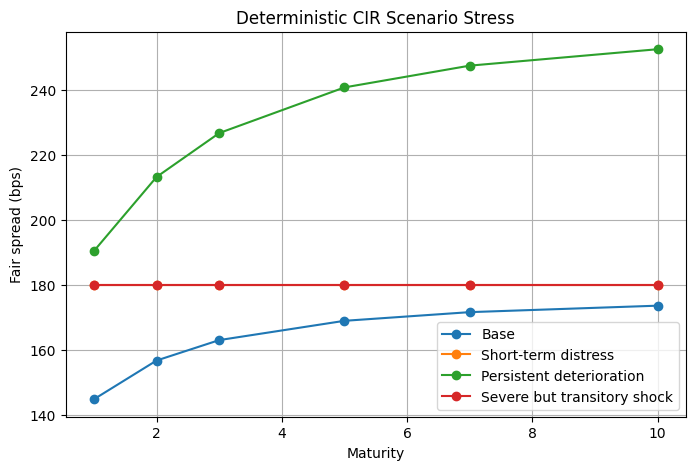

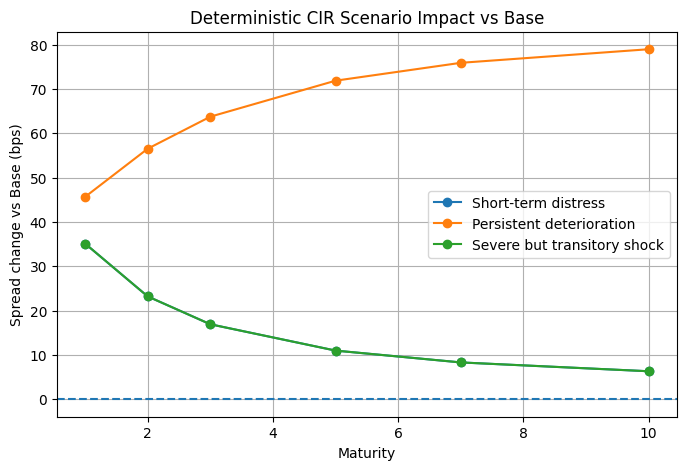

In [165]:
plot_scenario_term_structures(df_scen_det, title="Deterministic CIR Scenario Stress")
plot_scenario_changes(df_scen_det_full, title="Deterministic CIR Scenario Impact vs Base")

### II. Stochastic scenarios

In [166]:
mc_scenarios = make_mc_scenarios(
    base_kappa=kappa,
    base_theta=theta,
    base_sigma=sigma,
    base_lam0=lam0
)

df_scen_mc = run_mc_scenario_stress(
    maturities=maturities_scen,
    scenarios=mc_scenarios,
    discount_fn=discount_fn,
    recovery=0.4,
    freq=4,
    accrued=True,
    dt=1/500,
    n_paths=50000,
    seed=12345
)

df_scen_mc_full, summary_scen_mc = summarize_scenario_impacts(df_scen_mc, base_scenario="Base")

print("\n=== Stochastic Scenario Stress Summary ===")
print(summary_scen_mc)


=== Stochastic Scenario Stress Summary ===
                         scenario  mean_spread_bps  mean_abs_change_bps  \
0                            Base       160.987538             0.000000   
1  Persistent deterioration + vol       220.805630            59.818092   
2               Volatility stress       160.812543             0.238462   

   max_abs_change_bps  
0            0.000000  
1           69.515520  
2            0.473337  


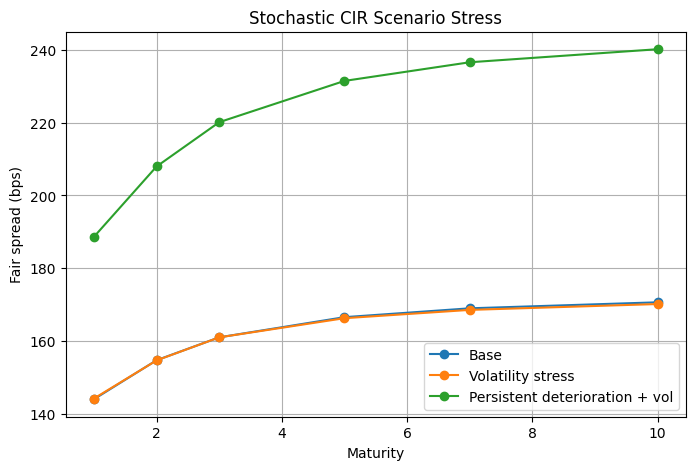

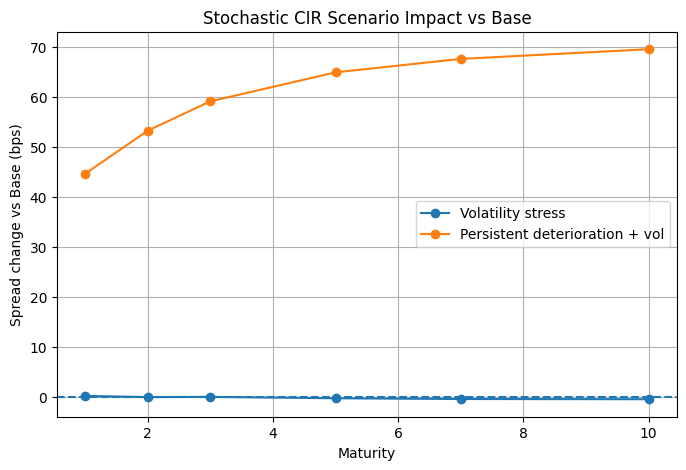

In [167]:
plot_scenario_term_structures(df_scen_mc, title="Stochastic CIR Scenario Stress")
plot_scenario_changes(df_scen_mc_full, title="Stochastic CIR Scenario Impact vs Base")

## 6.c. Breakdown regions 
<a id="d6c"></a>
*(Where does the model fail or become unstable?)*

Breakdown-region analysis was performed over structural $(\kappa,\sigma)$ and economic $(\lambda_0,R)$ parameter grids. After correcting the Monte Carlo uncertainty estimate to align with the ratio-of-expectations spread estimator, relative standard errors were consistently low ($\approx$ 1.5% to 2.2%) across all configurations, indicating strong numerical stability.

No numerical breakdown was observed: pricing outputs remained finite, smooth, and economically consistent throughout the tested domain. In the $(\kappa,\sigma)$ plane, flagged regions were driven exclusively by severe violations of the CIR Feller condition. However, inspection of boundary points shows that spreads, survival probabilities, and uncertainty measures remain well-behaved across this transition, indicating that the breakdown is structural rather than numerical.

In contrast, no breakdown was observed across the $(\lambda_0,R)$ grid, where the model remained stable even under extreme credit conditions. These results suggest that the model’s primary vulnerability lies in structurally inconsistent parameter regimes, while its numerical implementation and economic sensitivity are robust across relevant scenarios.

In [37]:
# Pricing wrapper

def price_cds_wrapper(kappa, theta, sigma, lam0, R,
                      T=5.0, dt=0.01, N=50000, r=0.03, seed=123,
                      annuity_eps=1e-12):
    """
    Wrap the Section 1 CDS pricing pipeline into a standard interface
    suitable for breakdown-region analysis.

    Returns
    -------
    result : dict
        {
            "fair_spread": float,
            "survival_T": float,
            "std_error": float,
            "annuity_mean": float,
            "protection_mean": float,
            "n_valid_paths": int,
            "status": "ok" or "fail"
        }
    """
    try:
        # Simulate CIR intensity paths
        times_lam, lam = simulate_cir_full_truncation(
            kappa=kappa,
            theta=theta,
            sigma=sigma,
            lam0=lam0,
            T=T,
            dt=dt,
            n_paths=N,
            seed=seed
        )

        # Cox default times
        tau = default_times_from_paths(lam, dt=dt, seed=seed + 1)

        # Fair spread using your ratio-of-expectations estimator
        fair_spread = cds_fair_spread_from_tau(tau=tau, r=r, R=R, T=T, dt=dt)

        # Survival probability at maturity
        survival_T = np.mean(tau > T)

        # Pathwise quantities for diagnostic MC error estimate
        prot_paths = np.exp(-r * tau) * (1.0 - R) * (tau <= T)

        times = np.arange(0.0, T + 1e-12, dt)
        alive = (tau[:, None] > times[None, :]).astype(float)
        disc = np.exp(-r * times)[None, :]
        vals = disc * alive
        annuity_paths = np.trapezoid(vals, times, axis=1)

        # Guard against annuity collapse
        valid = annuity_paths > annuity_eps
        n_valid = int(np.sum(valid))
        
        if n_valid < 2:
            return {
                "fair_spread": np.nan,
                "survival_T": float(survival_T),
                "std_error": np.nan,
                "annuity_mean": float(np.mean(annuity_paths)),
                "protection_mean": float(np.mean(prot_paths)),
                "n_valid_paths": n_valid,
                "status": "fail"
            }
        
        # Delta-method standard error for fair_spread = E[P] / E[A]
        mu_P = np.mean(prot_paths)
        mu_A = np.mean(annuity_paths)
        
        if mu_A <= annuity_eps:
            return {
                "fair_spread": np.nan,
                "survival_T": float(survival_T),
                "std_error": np.nan,
                "annuity_mean": float(mu_A),
                "protection_mean": float(mu_P),
                "n_valid_paths": n_valid,
                "status": "fail"
            }
        
        var_P = np.var(prot_paths, ddof=1)
        var_A = np.var(annuity_paths, ddof=1)
        cov_PA = np.cov(prot_paths, annuity_paths, ddof=1)[0, 1]
        
        var_s = (
            var_P / mu_A**2
            + (mu_P**2) * var_A / mu_A**4
            - 2.0 * mu_P * cov_PA / mu_A**3
        )
        var_s = max(var_s, 0.0)
        
        std_error = np.sqrt(var_s / N)

        return {
            "fair_spread": float(fair_spread),
            "survival_T": float(survival_T),
            "std_error": float(std_error),
            "annuity_mean": float(np.mean(annuity_paths)),
            "protection_mean": float(np.mean(prot_paths)),
            "n_valid_paths": n_valid,
            "status": "ok"
        }

    except Exception:
        return {
            "fair_spread": np.nan,
            "survival_T": np.nan,
            "std_error": np.nan,
            "annuity_mean": np.nan,
            "protection_mean": np.nan,
            "n_valid_paths": 0,
            "status": "fail"
        }

In [38]:
# BREAKDOWN CLASSIFICATION RULES

def classify_breakdown(result, kappa, theta, sigma,
                       spread_cap_bps=5000.0,
                       rel_se_tol=0.05,
                       severe_feller_tol=-0.05,
                       min_valid_path_frac=0.95,
                       N_total=None):
    """
    Classify whether a parameter point lies in a breakdown region.

    Breakdown rules:
      1. Pricing failure / non-finite output
      2. Negative spread
      3. Survival probability outside [0,1]
      4. Implausibly large spread
      5. Relative MC error too large
      6. Severe Feller violation
      7. Too many invalid paths from annuity collapse
    """
    if result["status"] != "ok":
        return {"breakdown": True, "reason": "pricing_failure"}

    spread = result["fair_spread"]
    survival_T = result["survival_T"]
    se = result["std_error"]
    n_valid_paths = result["n_valid_paths"]

    if not np.isfinite(spread) or not np.isfinite(survival_T) or not np.isfinite(se):
        return {"breakdown": True, "reason": "nonfinite_output"}

    if spread < 0:
        return {"breakdown": True, "reason": "negative_spread"}

    if survival_T < 0 or survival_T > 1:
        return {"breakdown": True, "reason": "invalid_survival_probability"}

    spread_bps = 1e4 * spread
    if spread_bps > spread_cap_bps:
        return {"breakdown": True, "reason": "implausibly_large_spread"}

    rel_se = np.inf if spread <= 0 else se / spread
    if rel_se > rel_se_tol:
        return {"breakdown": True, "reason": "high_relative_mc_error"}

    feller_margin = 2.0 * kappa * theta - sigma**2
    if feller_margin < severe_feller_tol:
        return {"breakdown": True, "reason": "severe_feller_violation"}

    if N_total is not None:
        valid_frac = n_valid_paths / N_total
        if valid_frac < min_valid_path_frac:
            return {"breakdown": True, "reason": "annuity_collapse"}

    return {"breakdown": False, "reason": "ok"}


In [39]:
# Generic 2D Sweep

def sweep_2d_breakdown(x_name, x_grid, y_name, y_grid,
                       base_params,
                       T=5.0, dt=0.01, N=50000, r=0.03, seed=123,
                       annuity_eps=1e-12,
                       spread_cap_bps=5000.0,
                       rel_se_tol=0.05,
                       severe_feller_tol=-0.05,
                       min_valid_path_frac=0.95):
    """
    Generic 2D breakdown sweep over any pair of parameters.

    Parameters
    ----------
    x_name, y_name : str
        Names among {"kappa", "theta", "sigma", "lam0", "R"}.
    x_grid, y_grid : array-like
        Grid values.
    base_params : dict
        Baseline dictionary containing all five model parameters.

    Returns
    -------
    df : pandas.DataFrame
    """
    rows = []
    ctr = 0

    for x in x_grid:
        for y in y_grid:
            ctr += 1

            params = base_params.copy()
            params[x_name] = float(x)
            params[y_name] = float(y)

            result = price_cds_wrapper(
                kappa=params["kappa"],
                theta=params["theta"],
                sigma=params["sigma"],
                lam0=params["lam0"],
                R=params["R"],
                T=T,
                dt=dt,
                N=N,
                r=r,
                seed=seed + ctr,
                annuity_eps=annuity_eps
            )

            label = classify_breakdown(
                result=result,
                kappa=params["kappa"],
                theta=params["theta"],
                sigma=params["sigma"],
                spread_cap_bps=spread_cap_bps,
                rel_se_tol=rel_se_tol,
                severe_feller_tol=severe_feller_tol,
                min_valid_path_frac=min_valid_path_frac,
                N_total=N
            )

            spread = result["fair_spread"]
            se = result["std_error"]
            rel_se = np.nan if (not np.isfinite(spread) or spread <= 0 or not np.isfinite(se)) else se / spread

            rows.append({
                x_name: float(x),
                y_name: float(y),
                "kappa": params["kappa"],
                "theta": params["theta"],
                "sigma": params["sigma"],
                "lam0": params["lam0"],
                "R": params["R"],
                "fair_spread": spread,
                "fair_spread_bps": np.nan if not np.isfinite(spread) else 1e4 * spread,
                "survival_T": result["survival_T"],
                "std_error": se,
                "rel_std_error": rel_se,
                "annuity_mean": result["annuity_mean"],
                "protection_mean": result["protection_mean"],
                "n_valid_paths": result["n_valid_paths"],
                "valid_path_frac": result["n_valid_paths"] / N if N > 0 else np.nan,
                "feller_margin": 2.0 * params["kappa"] * params["theta"] - params["sigma"]**2,
                "pricing_status": result["status"],
                "breakdown": label["breakdown"],
                "breakdown_reason": label["reason"]
            })

    return pd.DataFrame(rows)

In [40]:
# Summary table

def summarize_breakdown(df):
    summary = (
        df.groupby("breakdown_reason")
          .size()
          .reset_index(name="count")
          .sort_values("count", ascending=False)
          .reset_index(drop=True)
    )
    summary["pct"] = 100.0 * summary["count"] / len(df)
    return summary

In [41]:
# Plotting helpers

def plot_breakdown_heatmap(df, x_col, y_col, title="Breakdown region map"):
    """
    Heatmap of binary breakdown indicator.
    """
    pivot = df.pivot(index=y_col, columns=x_col, values="breakdown").astype(float)

    plt.figure(figsize=(8, 5))
    plt.imshow(
        pivot.values,
        origin="lower",
        aspect="auto",
        extent=[pivot.columns.min(), pivot.columns.max(),
                pivot.index.min(), pivot.index.max()]
    )
    plt.colorbar(label="Breakdown flag (1 = yes, 0 = no)")
    plt.xlabel(x_col)
    plt.ylabel(y_col)
    plt.title(title)
    plt.show()


def plot_metric_heatmap(df, x_col, y_col, value_col, title=None):
    """
    Heatmap for any scalar metric, e.g. fair_spread_bps, rel_std_error, survival_T.
    """
    pivot = df.pivot(index=y_col, columns=x_col, values=value_col)

    plt.figure(figsize=(8, 5))
    plt.imshow(
        pivot.values,
        origin="lower",
        aspect="auto",
        extent=[pivot.columns.min(), pivot.columns.max(),
                pivot.index.min(), pivot.index.max()]
    )
    plt.colorbar(label=value_col)
    plt.xlabel(x_col)
    plt.ylabel(y_col)
    plt.title(title or value_col)
    plt.show()


def encode_breakdown_reason(reason):
    mapping = {
        "ok": 0,
        "pricing_failure": 1,
        "nonfinite_output": 2,
        "negative_spread": 3,
        "invalid_survival_probability": 4,
        "implausibly_large_spread": 5,
        "high_relative_mc_error": 6,
        "severe_feller_violation": 7,
        "annuity_collapse": 8
    }
    return mapping.get(reason, 99)


def plot_breakdown_reason_map(df, x_col, y_col, title="Breakdown reason map"):
    """
    Heatmap of categorical breakdown reasons encoded as integers.
    """
    tmp = df.copy()
    tmp["reason_code"] = tmp["breakdown_reason"].map(encode_breakdown_reason)
    pivot = tmp.pivot(index=y_col, columns=x_col, values="reason_code")

    plt.figure(figsize=(8, 5))
    plt.imshow(
        pivot.values,
        origin="lower",
        aspect="auto",
        extent=[pivot.columns.min(), pivot.columns.max(),
                pivot.index.min(), pivot.index.max()]
    )
    cbar = plt.colorbar()
    cbar.set_label("Reason code")
    plt.xlabel(x_col)
    plt.ylabel(y_col)
    plt.title(title)
    plt.show()

    print("Reason code legend:")
    print("0 = ok")
    print("1 = pricing_failure")
    print("2 = nonfinite_output")
    print("3 = negative_spread")
    print("4 = invalid_survival_probability")
    print("5 = implausibly_large_spread")
    print("6 = high_relative_mc_error")
    print("7 = severe_feller_violation")
    print("8 = annuity_collapse")


In [42]:
# Convenience runners

def run_breakdown_kappa_sigma(base_params,
                              kappa_grid,
                              sigma_grid,
                              T=5.0, dt=0.01, N=50000, r=0.03, seed=123,
                              annuity_eps=1e-12,
                              spread_cap_bps=5000.0,
                              rel_se_tol=0.05,
                              severe_feller_tol=-0.05,
                              min_valid_path_frac=0.95,
                              make_plots=True):
    """
    Structural breakdown map over (kappa, sigma).
    """
    df = sweep_2d_breakdown(
        x_name="kappa",
        x_grid=kappa_grid,
        y_name="sigma",
        y_grid=sigma_grid,
        base_params=base_params,
        T=T, dt=dt, N=N, r=r, seed=seed,
        annuity_eps=annuity_eps,
        spread_cap_bps=spread_cap_bps,
        rel_se_tol=rel_se_tol,
        severe_feller_tol=severe_feller_tol,
        min_valid_path_frac=min_valid_path_frac
    )

    if make_plots:
        plot_breakdown_heatmap(
            df, x_col="kappa", y_col="sigma",
            title="Breakdown regions in $(\\kappa, \\sigma)$ space"
        )
        plot_breakdown_reason_map(
            df, x_col="kappa", y_col="sigma",
            title="Breakdown reasons in $(\\kappa, \\sigma)$ space"
        )
        plot_metric_heatmap(
            df, x_col="kappa", y_col="sigma", value_col="fair_spread_bps",
            title="Fair spread (bps) in $(\\kappa, \\sigma)$ space"
        )
        plot_metric_heatmap(
            df, x_col="kappa", y_col="sigma", value_col="rel_std_error",
            title="Relative MC error in $(\\kappa, \\sigma)$ space"
        )

    return df


def run_breakdown_lam0_R(base_params,
                         lam0_grid,
                         R_grid,
                         T=5.0, dt=0.01, N=50000, r=0.03, seed=123,
                         annuity_eps=1e-12,
                         spread_cap_bps=5000.0,
                         rel_se_tol=0.05,
                         severe_feller_tol=-0.05,
                         min_valid_path_frac=0.95,
                         make_plots=True):
    """
    Economic breakdown map over (lam0, R).
    """
    df = sweep_2d_breakdown(
        x_name="lam0",
        x_grid=lam0_grid,
        y_name="R",
        y_grid=R_grid,
        base_params=base_params,
        T=T, dt=dt, N=N, r=r, seed=seed,
        annuity_eps=annuity_eps,
        spread_cap_bps=spread_cap_bps,
        rel_se_tol=rel_se_tol,
        severe_feller_tol=severe_feller_tol,
        min_valid_path_frac=min_valid_path_frac
    )

    if make_plots:
        plot_breakdown_heatmap(
            df, x_col="lam0", y_col="R",
            title="Breakdown regions in $(\\lambda_0, R)$ space"
        )
        plot_breakdown_reason_map(
            df, x_col="lam0", y_col="R",
            title="Breakdown reasons in $(\\lambda_0, R)$ space"
        )
        plot_metric_heatmap(
            df, x_col="lam0", y_col="R", value_col="fair_spread_bps",
            title="Fair spread (bps) in $(\\lambda_0, R)$ space"
        )
        plot_metric_heatmap(
            df, x_col="lam0", y_col="R", value_col="rel_std_error",
            title="Relative MC error in $(\\lambda_0, R)$ space"
        )

    return df

In [43]:
# Baseline calibrated / reference parameters
base_params = {
    "kappa": 1.2,
    "theta": 0.03,
    "sigma": 0.25,
    "lam0": 0.02,
    "R": 0.40
}

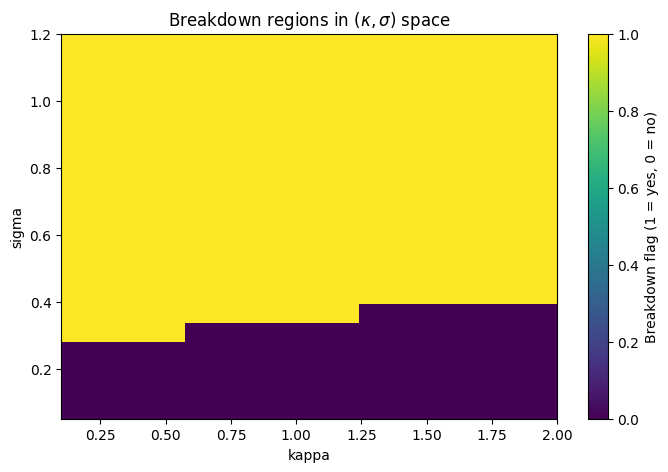

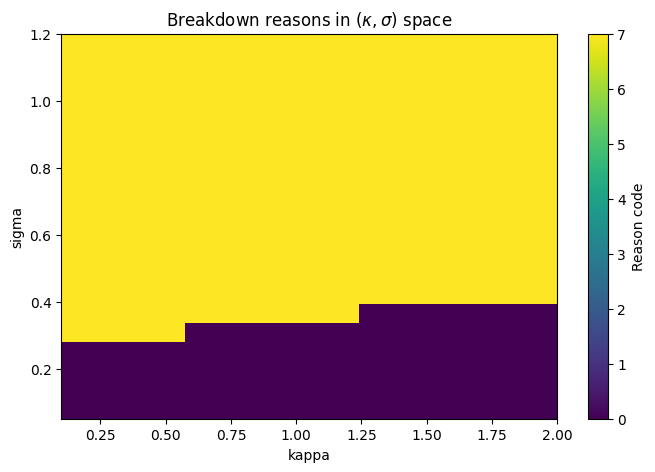

Reason code legend:
0 = ok
1 = pricing_failure
2 = nonfinite_output
3 = negative_spread
4 = invalid_survival_probability
5 = implausibly_large_spread
6 = high_relative_mc_error
7 = severe_feller_violation
8 = annuity_collapse


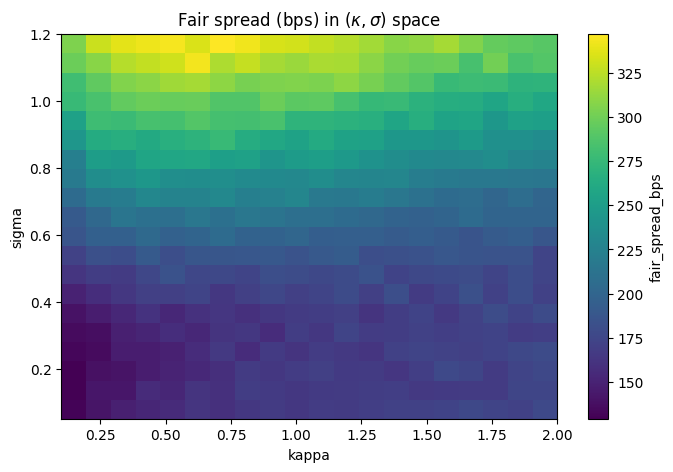

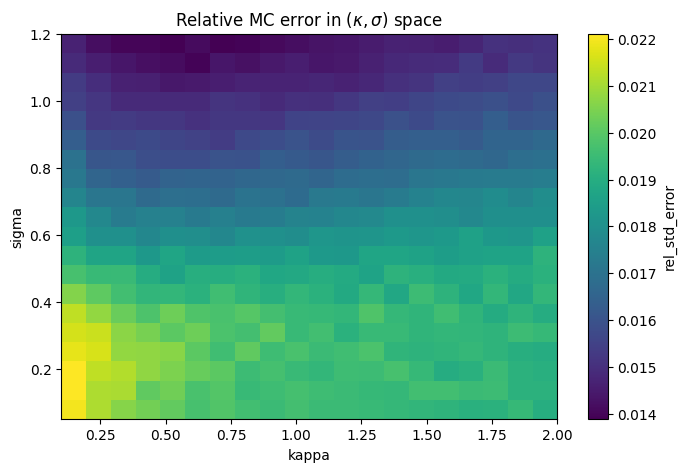


=== Breakdown summary: (kappa, sigma) ===


,breakdown_reason,count,pct
0,severe_feller_violation,297,74.25
1,ok,103,25.75


,kappa,sigma,theta,lam0,R,fair_spread,fair_spread_bps,survival_T,std_error,rel_std_error,annuity_mean,protection_mean,n_valid_paths,valid_path_frac,feller_margin,pricing_status,breakdown,breakdown_reason
0,0.1,0.050000,0.03,0.02,0.4,0.013094,130.937397,0.89635,0.000288,0.021960,4.409054,0.057731,20000,1.0,0.003500,ok,False,ok
1,0.1,0.110526,0.03,0.02,0.4,0.012971,129.712488,0.89755,0.000287,0.022115,4.406486,0.057158,20000,1.0,-0.006216,ok,False,ok
2,0.1,0.171053,0.03,0.02,0.4,0.012919,129.193434,0.89775,0.000286,0.022116,4.410543,0.056981,20000,1.0,-0.023259,ok,False,ok
3,0.1,0.231579,0.03,0.02,0.4,0.013335,133.345332,0.89470,0.000291,0.021799,4.402361,0.058703,20000,1.0,-0.047629,ok,False,ok
4,0.1,0.292105,0.03,0.02,0.4,0.013569,135.686072,0.89275,0.000293,0.021582,4.401614,0.059724,20000,1.0,-0.079325,ok,True,severe_feller_violation


In [44]:
# Structural breakdown study: (kappa, sigma)
kappa_grid = np.linspace(0.10, 2.00, 20)
sigma_grid = np.linspace(0.05, 1.20, 20)

df_break_ks = run_breakdown_kappa_sigma(
    base_params=base_params,
    kappa_grid=kappa_grid,
    sigma_grid=sigma_grid,
    T=5.0,
    dt=0.01,
    N=20000,          # raise to 50000+ for final results
    r=0.03,
    seed=123,
    annuity_eps=1e-12,
    spread_cap_bps=5000.0,
    rel_se_tol=0.05,
    severe_feller_tol=-0.05,
    min_valid_path_frac=0.95,
    make_plots=True
)

print("\n=== Breakdown summary: (kappa, sigma) ===")
display(summarize_breakdown(df_break_ks))
display(df_break_ks.head())

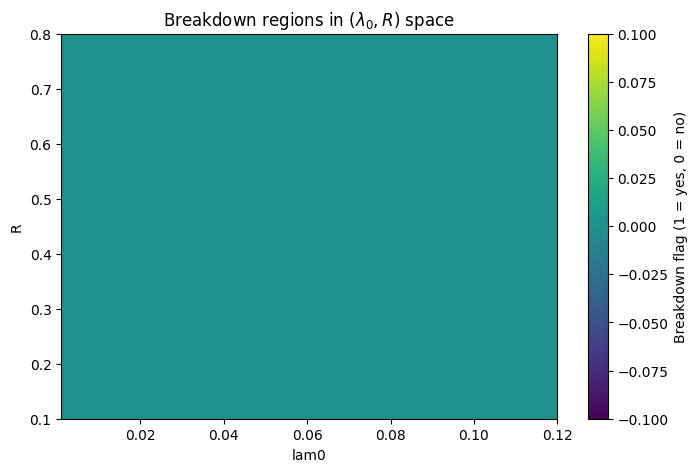

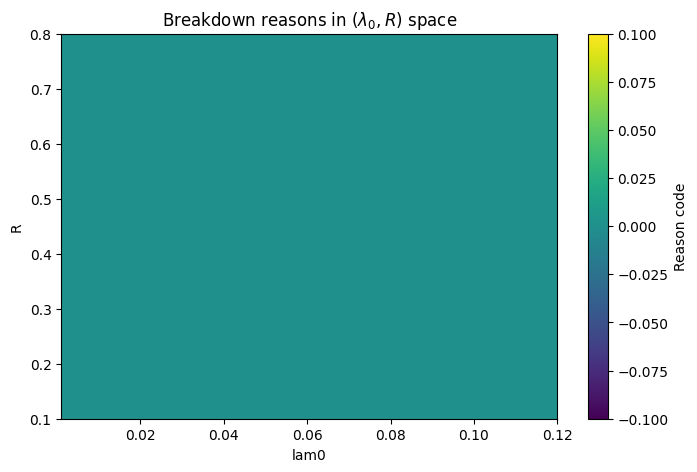

Reason code legend:
0 = ok
1 = pricing_failure
2 = nonfinite_output
3 = negative_spread
4 = invalid_survival_probability
5 = implausibly_large_spread
6 = high_relative_mc_error
7 = severe_feller_violation
8 = annuity_collapse


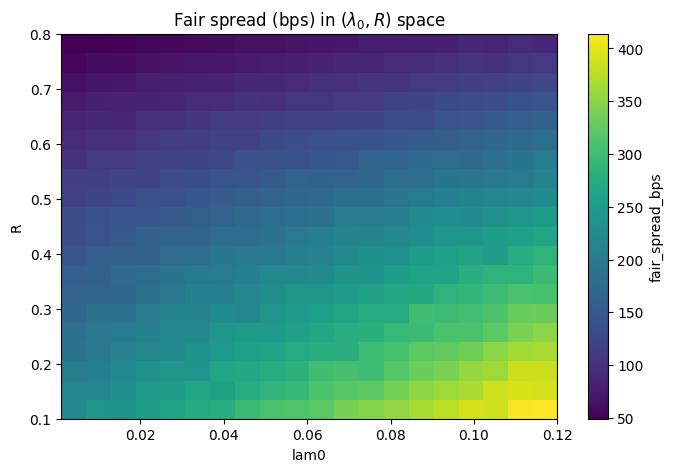

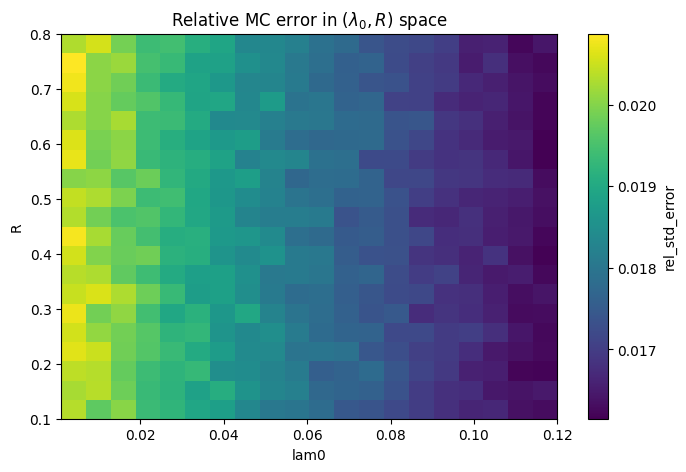


=== Breakdown summary: (lam0, R) ===


,breakdown_reason,count,pct
0,ok,400,100.0


,lam0,R,kappa,theta,sigma,fair_spread,fair_spread_bps,survival_T,std_error,rel_std_error,annuity_mean,protection_mean,n_valid_paths,valid_path_frac,feller_margin,pricing_status,breakdown,breakdown_reason
0,0.001,0.100000,1.2,0.03,0.25,0.022299,222.988314,0.88125,0.000454,0.020342,4.408548,0.098305,20000,1.0,0.0095,ok,False,ok
1,0.001,0.136842,1.2,0.03,0.25,0.021697,216.969178,0.87995,0.000440,0.020256,4.400037,0.095467,20000,1.0,0.0095,ok,False,ok
2,0.001,0.173684,1.2,0.03,0.25,0.020406,204.061131,0.88175,0.000416,0.020396,4.407224,0.089934,20000,1.0,0.0095,ok,False,ok
3,0.001,0.210526,1.2,0.03,0.25,0.018994,189.941839,0.88460,0.000392,0.020649,4.413705,0.083835,20000,1.0,0.0095,ok,False,ok
4,0.001,0.247368,1.2,0.03,0.25,0.018355,183.545546,0.88330,0.000377,0.020549,4.407667,0.080901,20000,1.0,0.0095,ok,False,ok


In [45]:
# Economic breakdown study: (lam0, R)
lam0_grid = np.linspace(0.001, 0.12, 20)
R_grid = np.linspace(0.10, 0.80, 20)

df_break_lr = run_breakdown_lam0_R(
    base_params=base_params,
    lam0_grid=lam0_grid,
    R_grid=R_grid,
    T=5.0,
    dt=0.01,
    N=20000,          # raise to 50000+ for final results
    r=0.03,
    seed=456,
    annuity_eps=1e-12,
    spread_cap_bps=5000.0,
    rel_se_tol=0.05,
    severe_feller_tol=-0.05,
    min_valid_path_frac=0.95,
    make_plots=True
)

print("\n=== Breakdown summary: (lam0, R) ===")
display(summarize_breakdown(df_break_lr))
display(df_break_lr.head())

In [46]:
def feller_boundary_table(df, top_n=15):
    out = df.copy()
    out["abs_feller_margin"] = np.abs(out["feller_margin"])
    cols = [
        "kappa", "sigma", "theta", "lam0", "R",
        "fair_spread_bps", "survival_T", "std_error", "rel_std_error",
        "feller_margin", "breakdown", "breakdown_reason"
    ]
    return out[cols + ["abs_feller_margin"]].sort_values("abs_feller_margin").head(top_n).reset_index(drop=True)

In [47]:
display(feller_boundary_table(df_break_ks, top_n=20))

,kappa,sigma,theta,lam0,R,fair_spread_bps,survival_T,std_error,rel_std_error,feller_margin,breakdown,breakdown_reason,abs_feller_margin
0,0.2,0.110526,0.03,0.02,0.4,142.033826,0.88800,0.000300,0.021116,-0.000216,False,ok,0.000216
1,0.9,0.231579,0.03,0.02,0.4,165.882445,0.87010,0.000325,0.019577,0.000371,False,ok,0.000371
2,0.5,0.171053,0.03,0.02,0.4,150.988764,0.88115,0.000309,0.020479,0.000741,False,ok,0.000741
3,1.4,0.292105,0.03,0.02,0.4,168.905678,0.86805,0.000328,0.019434,-0.001325,False,ok,0.001325
4,0.1,0.050000,0.03,0.02,0.4,130.937397,0.89635,0.000288,0.021960,0.003500,False,ok,0.003500
5,2.0,0.352632,0.03,0.02,0.4,178.636825,0.86140,0.000339,0.018989,-0.004349,False,ok,0.004349
6,1.5,0.292105,0.03,0.02,0.4,171.692089,0.86605,0.000331,0.019288,0.004675,False,ok,0.004675
7,0.4,0.171053,0.03,0.02,0.4,146.441974,0.88445,0.000304,0.020764,-0.005259,False,ok,0.005259
8,0.8,0.231579,0.03,0.02,0.4,156.646583,0.87690,0.000315,0.020114,-0.005629,False,ok,0.005629
9,0.3,0.110526,0.03,0.02,0.4,142.451940,0.88755,0.000300,0.021061,0.005784,False,ok,0.005784


In [48]:
def extreme_metric_table(df, top_n=10, metric="fair_spread_bps", ascending=False):
    cols = [
        "lam0", "R", "kappa", "theta", "sigma",
        "fair_spread_bps", "survival_T", "std_error", "rel_std_error",
        "feller_margin", "breakdown_reason"
    ]
    return df[cols].sort_values(metric, ascending=ascending).head(top_n).reset_index(drop=True)

In [49]:
display(extreme_metric_table(df_break_lr, top_n=10, metric="fair_spread_bps", ascending=False))
display(extreme_metric_table(df_break_lr, top_n=10, metric="rel_std_error", ascending=False))
display(extreme_metric_table(df_break_lr, top_n=10, metric="survival_T", ascending=True))

,lam0,R,kappa,theta,sigma,fair_spread_bps,survival_T,std_error,rel_std_error,feller_margin,breakdown_reason
0,0.120000,0.100000,1.2,0.03,0.25,414.001839,0.80200,0.000675,0.016313,0.0095,ok
1,0.113737,0.100000,1.2,0.03,0.25,411.238668,0.80330,0.000673,0.016370,0.0095,ok
2,0.113737,0.136842,1.2,0.03,0.25,392.284633,0.80420,0.000644,0.016405,0.0095,ok
3,0.101211,0.100000,1.2,0.03,0.25,390.633732,0.81105,0.000650,0.016632,0.0095,ok
4,0.120000,0.136842,1.2,0.03,0.25,390.517357,0.80530,0.000643,0.016468,0.0095,ok
5,0.107474,0.100000,1.2,0.03,0.25,387.582935,0.81230,0.000647,0.016682,0.0095,ok
6,0.107474,0.136842,1.2,0.03,0.25,387.535696,0.80590,0.000638,0.016451,0.0095,ok
7,0.120000,0.173684,1.2,0.03,0.25,385.372677,0.79940,0.000624,0.016202,0.0095,ok
8,0.113737,0.173684,1.2,0.03,0.25,384.453748,0.79990,0.000624,0.016224,0.0095,ok
9,0.094947,0.100000,1.2,0.03,0.25,376.981801,0.81615,0.000634,0.016809,0.0095,ok


,lam0,R,kappa,theta,sigma,fair_spread_bps,survival_T,std_error,rel_std_error,feller_margin,breakdown_reason
0,0.001000,0.763158,1.2,0.03,0.25,55.828880,0.88690,0.000117,0.020868,0.0095,ok
1,0.001000,0.431579,1.2,0.03,0.25,134.951210,0.88615,0.000281,0.020800,0.0095,ok
2,0.001000,0.726316,1.2,0.03,0.25,65.653844,0.88540,0.000136,0.020763,0.0095,ok
3,0.001000,0.284211,1.2,0.03,0.25,171.168381,0.88535,0.000355,0.020725,0.0095,ok
4,0.001000,0.578947,1.2,0.03,0.25,100.914011,0.88520,0.000209,0.020720,0.0095,ok
5,0.001000,0.210526,1.2,0.03,0.25,189.941839,0.88460,0.000392,0.020649,0.0095,ok
6,0.001000,0.615789,1.2,0.03,0.25,92.502561,0.88445,0.000191,0.020628,0.0095,ok
7,0.007263,0.321053,1.2,0.03,0.25,166.597779,0.88325,0.000343,0.020598,0.0095,ok
8,0.001000,0.689474,1.2,0.03,0.25,75.228666,0.88390,0.000155,0.020591,0.0095,ok
9,0.007263,0.800000,1.2,0.03,0.25,49.210182,0.88285,0.000101,0.020555,0.0095,ok


,lam0,R,kappa,theta,sigma,fair_spread_bps,survival_T,std_error,rel_std_error,feller_margin,breakdown_reason
0,0.120000,0.578947,1.2,0.03,0.25,198.287385,0.79785,0.000320,0.016151,0.0095,ok
1,0.120000,0.394737,1.2,0.03,0.25,285.865138,0.79795,0.000463,0.016188,0.0095,ok
2,0.120000,0.615789,1.2,0.03,0.25,180.552783,0.79825,0.000292,0.016168,0.0095,ok
3,0.120000,0.652632,1.2,0.03,0.25,163.147621,0.79880,0.000264,0.016210,0.0095,ok
4,0.120000,0.689474,1.2,0.03,0.25,145.277149,0.79930,0.000236,0.016223,0.0095,ok
5,0.120000,0.173684,1.2,0.03,0.25,385.372677,0.79940,0.000624,0.016202,0.0095,ok
6,0.120000,0.431579,1.2,0.03,0.25,265.338760,0.79960,0.000431,0.016228,0.0095,ok
7,0.113737,0.173684,1.2,0.03,0.25,384.453748,0.79990,0.000624,0.016224,0.0095,ok
8,0.120000,0.247368,1.2,0.03,0.25,350.911656,0.80005,0.000570,0.016257,0.0095,ok
9,0.120000,0.763158,1.2,0.03,0.25,110.139035,0.80020,0.000179,0.016245,0.0095,ok


In [50]:
def grid_summary_stats(df):
    return pd.DataFrame({
        "metric": [
            "fair_spread_bps",
            "survival_T",
            "std_error",
            "rel_std_error",
            "feller_margin"
        ],
        "min": [
            df["fair_spread_bps"].min(),
            df["survival_T"].min(),
            df["std_error"].min(),
            df["rel_std_error"].min(),
            df["feller_margin"].min()
        ],
        "mean": [
            df["fair_spread_bps"].mean(),
            df["survival_T"].mean(),
            df["std_error"].mean(),
            df["rel_std_error"].mean(),
            df["feller_margin"].mean()
        ],
        "max": [
            df["fair_spread_bps"].max(),
            df["survival_T"].max(),
            df["std_error"].max(),
            df["rel_std_error"].max(),
            df["feller_margin"].max()
        ]
    })

In [51]:
display(grid_summary_stats(df_break_ks))
display(grid_summary_stats(df_break_lr))

,metric,min,mean,max
0,fair_spread_bps,129.193434,216.315926,347.068086
1,survival_T,0.745900,0.834570,0.897750
2,std_error,0.000286,0.000371,0.000483
3,rel_std_error,0.013890,0.017663,0.022116
4,feller_margin,-1.434000,-0.449434,0.117500


,metric,min,mean,max
0,fair_spread_bps,49.210182,193.675242,414.001839
1,survival_T,0.797850,0.841668,0.886900
2,std_error,0.000101,0.000346,0.000675
3,rel_std_error,0.016151,0.018107,0.020868
4,feller_margin,0.009500,0.009500,0.009500


## 6.d. Robustness 
<a id="d6d"></a>
*(Is behavior consistent across scenarios?)*

Robustness was assessed through parameter perturbations, numerical sensitivity analysis, and Monte Carlo variability. One-at-a-time shocks of up to $\pm$20% applied to model parameters showed smooth and economically consistent responses in CDS spreads and survival probabilities, with no abrupt changes or instability. Sensitivity was highest with respect to the long-run intensity level $\theta$ and recovery rate $R$, while volatility $\sigma$ and mean reversion $\kappa$ had comparatively limited impact, consistent with the model structure.

Numerical robustness was confirmed through variation of the time step and number of Monte Carlo paths. Pricing results remained stable across discretization levels, with no evidence of drift or instability, and Monte Carlo error decreased at the expected $\mathcal{O}\left(\frac{1}{\sqrt N} \right)$ rate. Additional runs across multiple random seeds showed low dispersion in both spreads and survival probabilities, indicating limited sensitivity to simulation randomness.

Overall, the model exhibits stable behavior under moderate perturbations, supporting the robustness of both the implementation and the resulting pricing conclusions within the admissible parameter region.

In [53]:
# robustness

def run_baseline_result(base_params, T=5.0, dt=0.01, N=50000, r=0.03, seed=123):
    result = price_cds_wrapper(
        kappa=base_params["kappa"],
        theta=base_params["theta"],
        sigma=base_params["sigma"],
        lam0=base_params["lam0"],
        R=base_params["R"],
        T=T,
        dt=dt,
        N=N,
        r=r,
        seed=seed
    )
    return result


def parameter_robustness_sweep(base_params,
                               shock_levels=(-0.20, -0.10, -0.05, 0.05, 0.10, 0.20),
                               T=5.0, dt=0.01, N=50000, r=0.03, seed=123):
    """
    One-at-a-time parameter robustness study around the baseline.
    """
    baseline = run_baseline_result(base_params, T=T, dt=dt, N=N, r=r, seed=seed)
    base_spread = baseline["fair_spread"]
    base_survival = baseline["survival_T"]

    rows = []

    for param in ["kappa", "theta", "sigma", "lam0", "R"]:
        base_value = base_params[param]

        for shock in shock_levels:
            shocked_params = base_params.copy()
            shocked_value = base_value * (1.0 + shock)
            shocked_params[param] = shocked_value

            result = price_cds_wrapper(
                kappa=shocked_params["kappa"],
                theta=shocked_params["theta"],
                sigma=shocked_params["sigma"],
                lam0=shocked_params["lam0"],
                R=shocked_params["R"],
                T=T,
                dt=dt,
                N=N,
                r=r,
                seed=seed
            )

            spread = result["fair_spread"]
            survival = result["survival_T"]
            rel_se = np.nan if (not np.isfinite(spread) or spread <= 0) else result["std_error"] / spread

            rows.append({
                "parameter": param,
                "shock": shock,
                "baseline_value": base_value,
                "shocked_value": shocked_value,
                "fair_spread": spread,
                "fair_spread_bps": 1e4 * spread if np.isfinite(spread) else np.nan,
                "spread_change_bps": 1e4 * (spread - base_spread) if np.isfinite(spread) else np.nan,
                "spread_change_pct": 100.0 * (spread - base_spread) / base_spread if np.isfinite(spread) else np.nan,
                "survival_T": survival,
                "survival_change": survival - base_survival if np.isfinite(survival) else np.nan,
                "std_error": result["std_error"],
                "rel_std_error": rel_se,
                "status": result["status"]
            })

    return pd.DataFrame(rows), baseline

In [54]:
def parameter_robustness_summary(df):
    """
    Summarize robustness by parameter.
    """
    out = (
        df.groupby("parameter")
          .agg(
              mean_abs_spread_change_bps=("spread_change_bps", lambda x: np.mean(np.abs(x))),
              max_abs_spread_change_bps=("spread_change_bps", lambda x: np.max(np.abs(x))),
              mean_abs_survival_change=("survival_change", lambda x: np.mean(np.abs(x))),
              max_abs_survival_change=("survival_change", lambda x: np.max(np.abs(x))),
              mean_rel_se=("rel_std_error", "mean"),
              max_rel_se=("rel_std_error", "max")
          )
          .reset_index()
          .sort_values("max_abs_spread_change_bps", ascending=False)
    )
    return out

In [56]:
def plot_parameter_robustness(df, parameter, value_col="fair_spread_bps"):
    sub = df[df["parameter"] == parameter].sort_values("shock")

    plt.figure(figsize=(7, 4))
    plt.plot(100 * sub["shock"], sub[value_col], marker="o")
    plt.xlabel("Shock (%)")
    plt.ylabel(value_col)
    plt.title(f"{parameter} robustness: {value_col}")
    plt.grid(True, alpha=0.3)
    plt.show()

def plot_all_parameter_robustness(df, value_col="spread_change_bps"):
    for param in ["kappa", "theta", "sigma", "lam0", "R"]:
        plot_parameter_robustness(df, parameter=param, value_col=value_col)

In [57]:
# Time-step sweep

def dt_robustness_sweep(base_params,
                        dt_grid=(0.04, 0.02, 0.01, 0.005),
                        T=5.0, N=50000, r=0.03, seed=123):
    rows = []

    for dt in dt_grid:
        result = price_cds_wrapper(
            kappa=base_params["kappa"],
            theta=base_params["theta"],
            sigma=base_params["sigma"],
            lam0=base_params["lam0"],
            R=base_params["R"],
            T=T,
            dt=dt,
            N=N,
            r=r,
            seed=seed
        )

        spread = result["fair_spread"]
        rel_se = np.nan if (not np.isfinite(spread) or spread <= 0) else result["std_error"] / spread

        rows.append({
            "dt": dt,
            "fair_spread": spread,
            "fair_spread_bps": 1e4 * spread if np.isfinite(spread) else np.nan,
            "survival_T": result["survival_T"],
            "std_error": result["std_error"],
            "rel_std_error": rel_se,
            "status": result["status"]
        })

    df = pd.DataFrame(rows).sort_values("dt", ascending=False).reset_index(drop=True)
    return df

In [58]:
# Path-count sweep

def N_robustness_sweep(base_params,
                       N_grid=(5000, 10000, 20000, 50000, 100000),
                       T=5.0, dt=0.01, r=0.03, seed=123):
    rows = []

    for N in N_grid:
        result = price_cds_wrapper(
            kappa=base_params["kappa"],
            theta=base_params["theta"],
            sigma=base_params["sigma"],
            lam0=base_params["lam0"],
            R=base_params["R"],
            T=T,
            dt=dt,
            N=N,
            r=r,
            seed=seed
        )

        spread = result["fair_spread"]
        rel_se = np.nan if (not np.isfinite(spread) or spread <= 0) else result["std_error"] / spread

        rows.append({
            "N": N,
            "fair_spread": spread,
            "fair_spread_bps": 1e4 * spread if np.isfinite(spread) else np.nan,
            "survival_T": result["survival_T"],
            "std_error": result["std_error"],
            "rel_std_error": rel_se,
            "status": result["status"]
        })

    df = pd.DataFrame(rows).sort_values("N").reset_index(drop=True)
    return df

In [59]:
# Seed robustness

def seed_robustness_sweep(base_params,
                          seed_grid=range(101, 121),
                          T=5.0, dt=0.01, N=50000, r=0.03):
    rows = []

    for seed in seed_grid:
        result = price_cds_wrapper(
            kappa=base_params["kappa"],
            theta=base_params["theta"],
            sigma=base_params["sigma"],
            lam0=base_params["lam0"],
            R=base_params["R"],
            T=T,
            dt=dt,
            N=N,
            r=r,
            seed=seed
        )

        spread = result["fair_spread"]
        rel_se = np.nan if (not np.isfinite(spread) or spread <= 0) else result["std_error"] / spread

        rows.append({
            "seed": seed,
            "fair_spread": spread,
            "fair_spread_bps": 1e4 * spread if np.isfinite(spread) else np.nan,
            "survival_T": result["survival_T"],
            "std_error": result["std_error"],
            "rel_std_error": rel_se,
            "status": result["status"]
        })

    return pd.DataFrame(rows).reset_index(drop=True)

def seed_robustness_summary(df):
    spreads = df["fair_spread_bps"].to_numpy()
    survivals = df["survival_T"].to_numpy()

    return pd.DataFrame({
        "metric": ["fair_spread_bps", "survival_T"],
        "mean": [np.mean(spreads), np.mean(survivals)],
        "std": [np.std(spreads, ddof=1), np.std(survivals, ddof=1)],
        "min": [np.min(spreads), np.min(survivals)],
        "max": [np.max(spreads), np.max(survivals)],
        "cv_pct": [
            100.0 * np.std(spreads, ddof=1) / np.mean(spreads),
            100.0 * np.std(survivals, ddof=1) / np.mean(survivals)
        ]
    })

In [60]:
# Plot results

def plot_dt_robustness(df, value_col="fair_spread_bps"):
    plt.figure(figsize=(7, 4))
    plt.plot(df["dt"], df[value_col], marker="o")
    plt.xlabel("dt")
    plt.ylabel(value_col)
    plt.title(f"Time-step robustness: {value_col}")
    plt.grid(True, alpha=0.3)
    plt.show()

def plot_N_robustness(df, value_col="fair_spread_bps"):
    plt.figure(figsize=(7, 4))
    plt.plot(df["N"], df[value_col], marker="o")
    plt.xlabel("N")
    plt.ylabel(value_col)
    plt.title(f"Path-count robustness: {value_col}")
    plt.grid(True, alpha=0.3)
    plt.show()

def plot_seed_histogram(df, value_col="fair_spread_bps"):
    plt.figure(figsize=(7, 4))
    plt.hist(df[value_col], bins=10)
    plt.xlabel(value_col)
    plt.ylabel("Frequency")
    plt.title(f"Seed robustness: distribution of {value_col}")
    plt.grid(True, alpha=0.3)
    plt.show()

In [61]:
# Runner

def run_robustness(base_params,
                              shock_levels=(-0.20, -0.10, -0.05, 0.05, 0.10, 0.20),
                              dt_grid=(0.04, 0.02, 0.01, 0.005),
                              N_grid=(5000, 10000, 20000, 50000, 100000),
                              seed_grid=range(101, 121),
                              T=5.0, dt=0.01, N=50000, r=0.03, seed=123,
                              make_plots=True):
    # 1. Local parameter robustness
    df_param, baseline = parameter_robustness_sweep(
        base_params=base_params,
        shock_levels=shock_levels,
        T=T, dt=dt, N=N, r=r, seed=seed
    )

    # 2. Numerical robustness
    df_dt = dt_robustness_sweep(
        base_params=base_params,
        dt_grid=dt_grid,
        T=T, N=N, r=r, seed=seed
    )

    df_N = N_robustness_sweep(
        base_params=base_params,
        N_grid=N_grid,
        T=T, dt=dt, r=r, seed=seed
    )

    # 3. Seed robustness
    df_seed = seed_robustness_sweep(
        base_params=base_params,
        seed_grid=seed_grid,
        T=T, dt=dt, N=N, r=r
    )

    if make_plots:
        plot_all_parameter_robustness(df_param, value_col="spread_change_bps")
        plot_dt_robustness(df_dt, value_col="fair_spread_bps")
        plot_dt_robustness(df_dt, value_col="rel_std_error")
        plot_N_robustness(df_N, value_col="fair_spread_bps")
        plot_N_robustness(df_N, value_col="rel_std_error")
        plot_seed_histogram(df_seed, value_col="fair_spread_bps")

    return {
        "baseline": baseline,
        "parameter_results": df_param,
        "parameter_summary": parameter_robustness_summary(df_param),
        "dt_results": df_dt,
        "N_results": df_N,
        "seed_results": df_seed,
        "seed_summary": seed_robustness_summary(df_seed)
    }

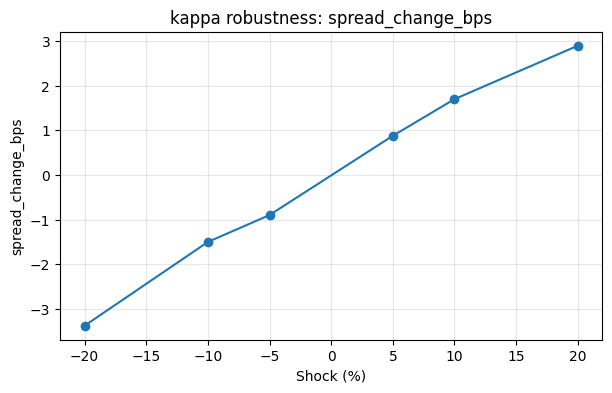

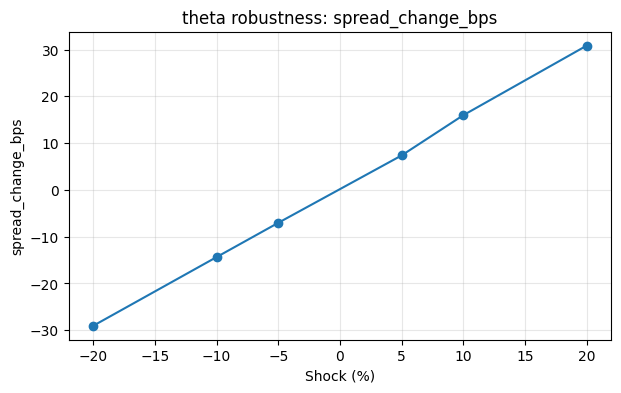

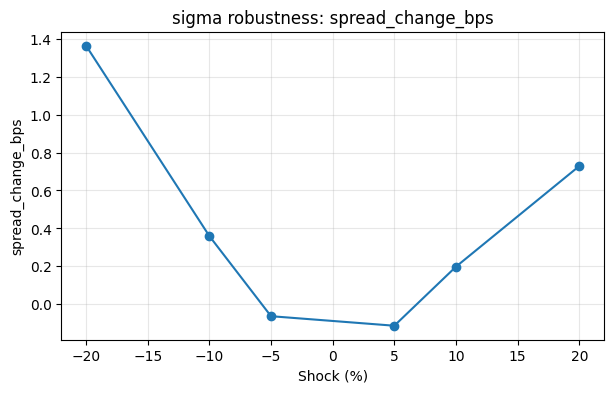

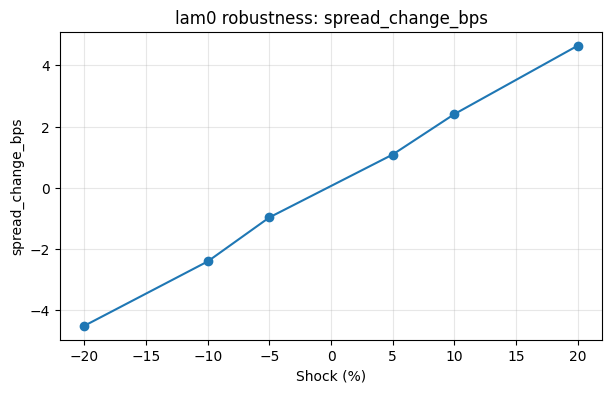

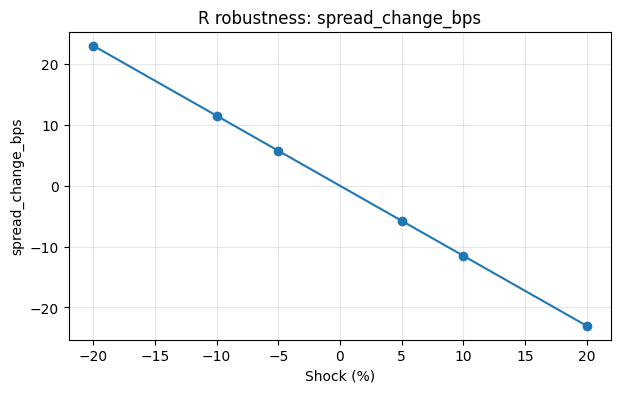

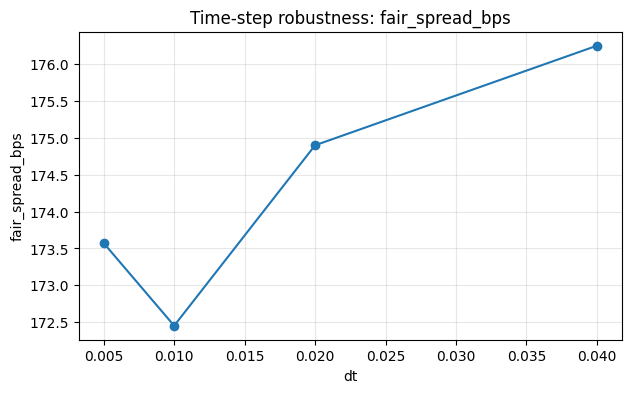

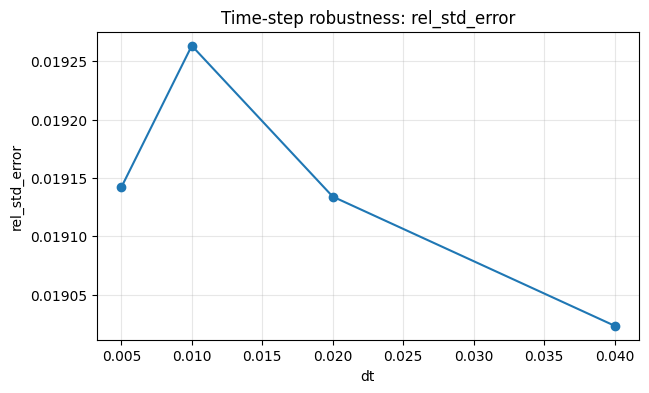

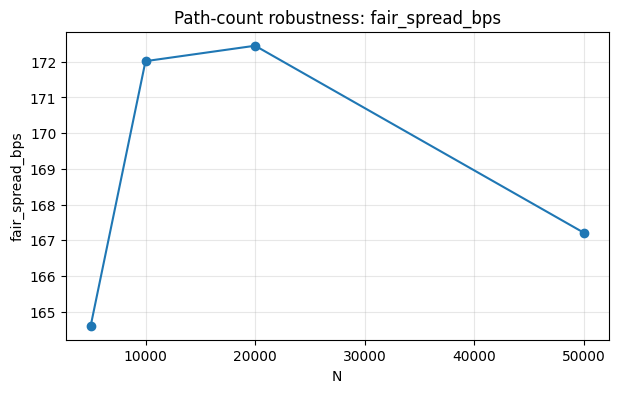

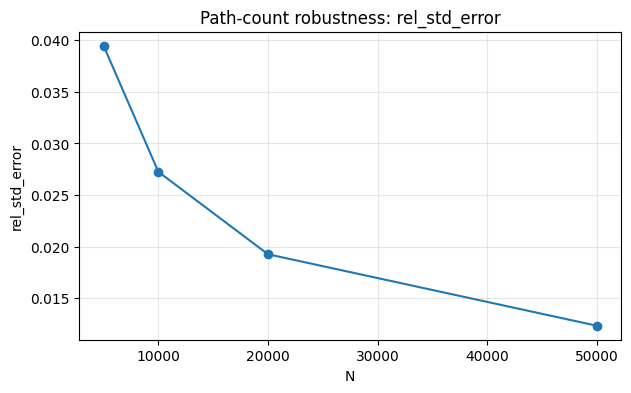

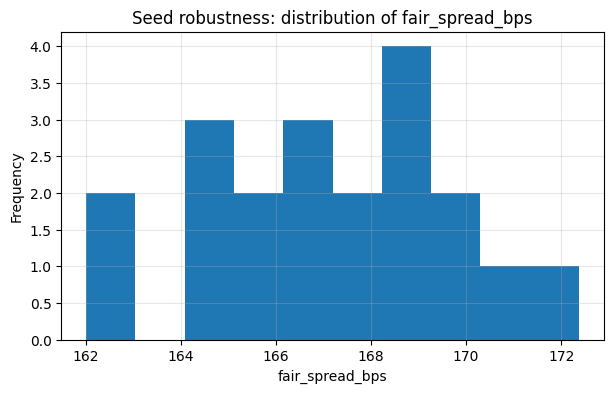

=== Baseline result ===
{'fair_spread': 0.01724503741797007, 'survival_T': 0.8656, 'std_error': 0.00033219812505069096, 'annuity_mean': 4.340227448990836, 'protection_mean': 0.07484738476034775, 'n_valid_paths': 20000, 'status': 'ok'}

=== Parameter robustness summary ===


,parameter,mean_abs_spread_change_bps,max_abs_spread_change_bps,mean_abs_survival_change,max_abs_survival_change,mean_rel_se,max_rel_se
4,theta,17.422110,30.808304,0.012867,0.02260,0.019318,0.021069
0,R,13.412807,22.993383,0.000000,0.00000,0.019263,0.019263
2,lam0,2.669835,4.640694,0.001750,0.00305,0.019262,0.019453
1,kappa,1.874196,3.376037,0.001350,0.00240,0.019264,0.019435
3,sigma,0.470806,1.362871,0.000375,0.00110,0.019239,0.019272



=== Parameter robustness details ===


,parameter,shock,baseline_value,shocked_value,fair_spread,fair_spread_bps,spread_change_bps,spread_change_pct,survival_T,survival_change,std_error,rel_std_error,status
0,kappa,-0.20,1.20,0.9600,0.016907,169.074337,-3.376037,-1.957686,0.86800,0.00240,0.000329,0.019435,ok
1,kappa,-0.10,1.20,1.0800,0.017095,170.950394,-1.499980,-0.869804,0.86665,0.00105,0.000331,0.019337,ok
2,kappa,-0.05,1.20,1.1400,0.017155,171.553259,-0.897115,-0.520216,0.86625,0.00065,0.000331,0.019310,ok
3,kappa,0.05,1.20,1.2600,0.017333,173.328659,0.878285,0.509297,0.86495,-0.00065,0.000333,0.019216,ok
4,kappa,0.10,1.20,1.3200,0.017415,174.148688,1.698314,0.984813,0.86435,-0.00125,0.000334,0.019173,ok
5,kappa,0.20,1.20,1.4400,0.017535,175.345816,2.895442,1.679000,0.86350,-0.00210,0.000335,0.019114,ok
6,theta,-0.20,0.03,0.0240,0.014342,143.423708,-29.026666,-16.831895,0.88725,0.02165,0.000302,0.021069,ok
7,theta,-0.10,0.03,0.0270,0.015810,158.095255,-14.355119,-8.324203,0.87620,0.01060,0.000318,0.020085,ok
8,theta,-0.05,0.03,0.0285,0.016541,165.414221,-7.036153,-4.080103,0.87075,0.00515,0.000325,0.019648,ok
9,theta,0.05,0.03,0.0315,0.017981,179.807473,7.357099,4.266212,0.86020,-0.00540,0.000339,0.018880,ok



=== dt robustness ===


...

,N,fair_spread,fair_spread_bps,survival_T,std_error,rel_std_error,status
0,5000,0.016460,164.603186,0.87160,0.000650,0.039471,ok
1,10000,0.017202,172.017740,0.86580,0.000469,0.027251,ok
2,20000,0.017245,172.450374,0.86560,0.000332,0.019263,ok
3,50000,0.016721,167.208345,0.86914,0.000206,0.012335,ok



=== Seed robustness summary ===


,metric,mean,std,min,max,cv_pct
0,fair_spread_bps,167.093104,2.660131,162.006444,172.377001,1.592005
1,survival_T,0.869245,0.001835,0.865600,0.872900,0.211090



=== Seed robustness details ===


,seed,fair_spread,fair_spread_bps,survival_T,std_error,rel_std_error,status
0,101,0.016887,168.870399,0.86775,0.000327,0.019388,ok
1,102,0.016624,166.244240,0.86980,0.000325,0.019552,ok
2,103,0.016600,165.999361,0.87020,0.000325,0.019597,ok
3,104,0.016614,166.144828,0.87010,0.000325,0.019590,ok
4,105,0.016855,168.551378,0.86840,0.000328,0.019467,ok
5,106,0.016946,169.460137,0.86750,0.000328,0.019382,ok
6,107,0.016732,167.316028,0.86890,0.000326,0.019472,ok
7,108,0.016201,162.006444,0.87290,0.000321,0.019786,ok
8,109,0.016871,168.705921,0.86800,0.000328,0.019416,ok
9,110,0.016751,167.514462,0.86905,0.000327,0.019508,ok


In [62]:
base_params = {
    "kappa": 1.2,
    "theta": 0.03,
    "sigma": 0.25,
    "lam0": 0.02,
    "R": 0.40
}

robust_out = run_robustness(
    base_params=base_params,
    shock_levels=(-0.20, -0.10, -0.05, 0.05, 0.10, 0.20),
    dt_grid=(0.04, 0.02, 0.01, 0.005),
    N_grid=(5000, 10000, 20000, 50000),
    seed_grid=range(101, 121),
    T=5.0,
    dt=0.01,
    N=20000,
    r=0.03,
    seed=123,
    make_plots=True
)

print("=== Baseline result ===")
print(robust_out["baseline"])

print("\n=== Parameter robustness summary ===")
display(robust_out["parameter_summary"])

print("\n=== Parameter robustness details ===")
display(robust_out["parameter_results"].head(20))

print("\n=== dt robustness ===")
display(robust_out["dt_results"])

print("\n=== N robustness ===")
display(robust_out["N_results"])

print("\n=== Seed robustness summary ===")
display(robust_out["seed_summary"])

print("\n=== Seed robustness details ===")
display(robust_out["seed_results"].head(10))

# 7. Validation Conclusion 
<a id="d7"></a>
*(Should we approve it?)*

## 7.a. Approval status 
<a id="d7a"></a>
*(Is the model fit for use?)*

The CDS hazard-rate model with stochastic CIR intensity is **approved with limitations** for controlled analytical use, including CDS pricing experiments, sensitivity analysis, challenger benchmarking, and model validation exercises within an admissible parameter regime.

his approval is supported by the cumulative validation evidence in the previous sections of this project. Verification tests confirm that the implementation is mathematically consistent and numerically stable: time-step error is small on practical grids, Monte Carlo error follows the expected $\frac{1}{\sqrt N}$ rate, independent replication is close, and boundary-condition tests behave correctly. Calibration results show that the model can recover the synthetic truth with low error, and parameter estimates are stable under small spread perturbations and leave-one-out maturity tests. Benchmarking results further support the implementation, as the stochastic and deterministic CIR models are closely aligned, the $\sigma \to 0$ limit behaves correctly, and the CIR specifications outperform simpler challengers in predictive accuracy. Outcomes analysis indicates low forecast error and limited bias under repeated tests. Stress testing and robustness analysis show smooth, economically coherent responses to shocks, no numerical breakdown in economically relevant $(\lambda_0,R)$ regions, and controlled Monte Carlo variability.

The approval is subject to important limitations. Calibration quality depends on initialization and may exhibit non-uniqueness or optimizer sensitivity. Large portions of $(\kappa,\sigma)$ space violate the Feller condition, creating structurally weak regions even when the numerical implementation remains stable. The model is reduced-form and therefore does not capture structural drivers of default. In addition, the study is based on synthetic data and does not establish empirical fit to observed market CDS term structures.

Accordingly, the model is suitable for research, prototyping, and controlled validation use, but should not be used for production pricing, limit setting, or regulatory reporting without tighter calibration controls, explicit parameter restrictions, and empirical market-data validation.

## 7.b. Limitations 
<a id="d7b"></a>
*(What limitations must be acknowledged?)*

The model has several limitations that constrain its scope of use.

### 1. Absence of empirical market-data validation.

**Impact**: High. This directly limits production use and external credibility.

The calibration and outcomes exercises are performed against synthetic term structures rather than observed market CDS data. As a result, the study demonstrates internal consistency and recovery of synthetic truth, but does not establish real-world pricing accuracy, market stability across regimes, or live calibration performance. This is the most important limitation from a model-risk perspective, because production suitability depends not only on internal correctness but also on empirical adequacy.

### 2. Calibration sensitivity to initialization and potential identifiability issues.

**Impact**: High. This affects parameter reliability and model governance, even if the pricing engine is sound.

Although calibration performs well near the synthetic truth and is stable under small spread perturbations and leave-one-out maturity tests, the initial-guess stability exercise shows that the optimizer can converge to materially different parameter values with substantially worse fit. This indicates a nontrivial calibration landscape with potential local minima or weak identifiability among parameters. The implication is that calibration quality depends on solver controls, initialization design, and parameter bounds, which introduces governance risk even when the pricing engine itself is sound.

### 3. Reduced-form specification limits economic interpretability.

**Impact**: Moderate. This is structurally important but does not invalidate the model for reduced-form CDS pricing.

The model treats default as an exogenous jump governed by stochastic intensity. This is appropriate for pricing and term-structure analysis, but it does not capture firm-value dynamics, capital structure effects, or other structural drivers of credit deterioration. Accordingly, the model is better suited to reduced-form pricing and sensitivity analysis than to economically structural interpretation of default mechanisms.

### 4. Structural weakness in Feller-violating parameter regions.

**Impact**: Moderate. The issue is structural rather than numerical and can be controlled with parameter restrictions.

Breakdown analysis shows that much of the $(\kappa,\sigma)$ grid falls into regions of severe Feller violation. While pricing outputs remain numerically stable and smooth even near the boundary, these regions are structurally weaker because the underlying CIR process loses its standard positivity-preserving admissibility properties. Full truncation mitigates numerical failure but does not eliminate the conceptual concern. These regions should therefore be treated as restricted or monitored parameter regimes rather than as standard operating conditions.

### 5. Discretization and simulation approximation remain present.

**Impact**: Low to Moderate. Verification results show it is small on practical grids.

The model relies on full-truncation Euler simulation and discretized default-time construction. Verification results show that time-step errors are small at practical grids and Monte Carlo scaling is correct, but approximation error is not zero. This is especially relevant in more extreme parameter regimes, where continuous-time and discretized behavior may diverge more materially.

### 6. Limited spread sensitivity to volatility.

**Impact**: Low to Moderate. Secondary relative to calibration and empirical-validation issues.

Robustness results show that spread levels are much more sensitive to $\theta$ and $R$ than to $\sigma$. This is consistent with the model structure, but it also means the framework may underrepresent volatility-driven credit effects in environments where dispersion or uncertainty in intensity dynamics is itself a primary risk driver.

## 7.c. Usage restrictions 
<a id="d7c"></a>
*(Where should the model not be used?)*

The use of the CDS pricing model is subject to the following restrictions and controls, derived from validation findings.

### 1. Permitted Use Cases

A. The model is approved for:
1. CDS pricing analysis in controlled environments.
2. Sensitivity and scenario analysis.
3. Benchmarking against alternative reduced-form models.
4. Methodological research and model development.

B. Use is appropriate where:
1. Parameter values remain within validated ranges.
2. Calibration is stable and well-controlled.
3. Outputs are interpreted in a reduced-form framework.

### 2. Prohibited Use Cases

A. The model must not be used for:
1. Production pricing or trading decisions without further validation.
2. Regulatory capital or accounting valuation.
3. Illiquid or stressed market calibration without additional controls.
4. Structural credit risk analysis (e.g. capital structure inference).

B. Rationale:
1. No empirical market validation.
2. Calibration instability under poor initialization.
3. Reduced-form limitations.

### 3. Parameter Admissibility Restrictions

A. To avoid structurally weak regions:
1. The Feller condition region must be monitored, and severe violations must be excluded.
2. Parameter combinations with large negative Feller margins must be treated as invalid or flagged.
3. Extreme parameter combinations (e.g. very low $\kappa$ with high $\sigma$) must not be used.

B. Implementation control:
1. Hard threshold or flag on Feller margin.

### 4. Calibration Controls

Due to sensitivity to initialization:

A. Calibration must be:
1. Run with multiple initial guesses, or
2. Constrained within reasonable parameter bounds.

B. Calibration outputs must be validated via:
1. Fit quality (RMSE, max error).
2. Parameter plausibility checks.

C. Poor-fit calibrations or unstable parameter estimates must be rejected.

### 5. Numerical / Simulation Controls

A. Time step must satisfy:
1. $\Delta t \leq 10^{-2}$.

B. Monte Carlo paths:
1. $N \geq 10^{4}$ for stable estimates.
2. Higher $N$ required for stress scenarios.

C. Full truncation scheme must be used to ensure numerical stability.

D. Outputs must be monitored for:
1. Abnormal spread jumps.
2. Escessive standard error.
3. Path invalidity.

### 6. Interpretation Constraints

A. Results must be interpreted as:
1. Risk-neutral reduced-form outputs, not structural credit measures.

B. Volatility effects should be interpreted cautiously:
1. Spreads are weakly sensitive to $\sigma$.
2. Model may understate volatility-driven credit risk.

## 7.d. Required improvements  
<a id="d7d"></a>
*(What remediation is required?)*

To address the limitations identified in the validation and to enhance the robustness and applicability of the model, the following improvements are required.

### 1. Empirical Market-Data Validation

**Priority**: High. Current validation is based on synthetic data and does not establish real-world performance.

A. The model must be validated against real CDS market data, including:
1. Calibration to observed CDS term structures.
2. Stability across market regimes (e.g. calm vs stressed periods).
3. Out-of-sample predictive performance.

B. Additional diagnostics should include:
1. Bid-ask consistency.
2. Term-structure smoothness vs market curves.
3. Cross-sectional consistency across names.

### 2. Robust Calibration Framework

**Priority**: High. Calibration results show strong dependence on initial conditions despite good local fit.

A. Calibration procedures must be strengthened to address initialization sensitivity and potential non-uniqueness:
1. Implement multi-start optimization.
2. Introduce parameter bounds and regularization.
3. Use robust objective functions (e.g. weighted RMSE).
4. Include diagnostics for convergence quality.

B. Optional enhancements:
1. Global optimization methods (e.g. differential evolution).
2. Parameter penalization for economically implausible values.

### 3. Parameter Admissibility Enforcement

**Priority**: High. Large regions of parameter space exhibit severe Feller violations, which weaken the theoretical foundation of the model.

A. Explicit enforcement of admissible parameter regions is required:
1. Implement hard constraints on the Feller condition (or bounded violation tolerance).
2. Introduce pre- and post-calibration checks on parameter validity.
3. Reject or flag calibrations in structurally weak regions.

### 4. Enhanced Model Specification

**Priority**: Moderate. The current one-factor CIR structure may limit the ability to capture complex term-structure dynamics.

A. Consider extending the model to improve flexibility and realism:
1. Time-dependent parameters such as $\theta(t)$ or $\lambda_0(t)$.
2. Multi-factor intensity models.
3. Regime-switching or stochastic recovery extensions.

### 5. Improved Default-Time Modeling

**Priority**: Moderate. Although discretization error is small, it remains a structural approximation.

A. Refine the treatment of default timing:
1. Implement exact or higher-order default-time simulation methods.
2. Reduce discretization bias in default event timing.
3. Benchmark against analytical or semi-analytical methods where available.

### 6. Expanded Sensitivity and Stress Coverage

**Priority**: Moderate. Current stress testing is well-structured but primarily univariate.

A. Extend stress testing to cover:
1. Joint parameter shocks (not only marginal shocks).
2. Extreme but plausible market scenarios.
3. Interaction effects between parameters.

B. Additional diagnostics should include:
1. Stress scenarios aligned with historical crisis periods.

### 7. Production Controls and Automation

**Priority**: Moderate.

A. Implement automated controls aligned with usage restrictions:
1. Parameter validation checks (e.g. Feller margin thresholds).
2. Calibration quality thresholds (RMSE, max error).
3. Numerical stability monitoring (std error, convergence flags).

B. Additional diagnostics should include:
1. Automated reporting of diagnostics.
2. Reproducibility controls (seed handling, versioning).

### 8. Documentation and Governance Enhancements

**Priority**: Low to Moderate. Necessary for auditability and future production consideration.

Documentation and governance should be enhanced to ensure reproducibility, auditability, and controlled model evolution, including formal documentation of methodology, assumptions, parameter constraints, and validation results, as well as version control and change tracking.

# 8. Ongoing Monitoring 
<a id="d8"></a>
*(How do we keep it under control?)*

## 8.a. Performance tracking 
<a id="d8a"></a><a id="d8a"></a>
*(How is performance tracked over time?)*

Ongoing performance of the CDS pricing model must be monitored using a set of quantitative diagnostics to ensure continued accuracy, stability, and consistency.

### 1. Pricing Accuracy Monitoring

A. Model-implied CDS spreads should be regularly compared against:
1. Observed market spreads (when available), or
2. Benchmark models (e.g. piecewise hazard or deterministic CIR).

B. Key metrics include:
1. Mean absolute error (MAE, in bps).
2. Root mean squared error (RMSE, in bps).
3. Maximum absolute error across maturities (Max error, in bps).

C. Baseline reference:
1. MAE $\approx$ 0.4 to 0.8 bps (deterministic CIR).
2. RMSE $\approx$ 0.5 bps.
3. Max error $\approx$ 0.5 to 1.5 bps (vs synthetic truth).

Persistent deviations beyond these ranges should trigger investigation.

### 2. Calibration Quality Monitoring

A. Each calibration run must be evaluated using:
1. RMSE of fitted spreads.
2. Maximum absolute error.
3. Stability of calibrated parameters.

B. Baseline reference:
1. RMSE $\approx 3.6 \times 10^{-4}$.
2. Max abs error $\approx 7.3 \times 10^{-4}$.
3. Mean relative error $\approx$ 1% to 2%.

Calibration outputs that deviate materially from these levels, or that produce unstable parameter estimates across runs, should be flagged.

### 3. Parameter Stability Tracking

A. Calibrated parameters $(\kappa,\theta,\sigma,\lambda_0)$ must be monitored over time:
1. Track time series of parameter estimates.
2. Compute rolling mean and variance.
3. Detect abrupt shifts or drift.

B. Special attention should be given to:
1. Large shifts in $\theta$ (high sensitivity driver).
2. Instability in $\sigma$ or $\lambda_0$.

C. Unexplained parameter jumps may indicate:
1. Calibration instability.
2. Data inconsistencies.
3. Regime changes.

### 4. Numerical Stability Monitoring

A. Simulation outputs must be monitored to ensure numerical reliability:
1. Standard error of Monte Carlo estimates.
2. Relative standard error (RSE).
3. Fraction of valid paths.

B. Baseline reference:
1. RSE $\approx$ 1.5% to 2.2%.
2. Valid path fraction $\approx$ 100%.

Significant increases in standard error or drops in valid paths indicate potential numerical instability or insufficient simulation granularity.

### 5. Structural Consistency Checks

A. The following structural diagnostics should be tracked:
1. Feller margin $2\kappa\theta-\sigma^2$.
2. Positivity of simulated intensities.
3. Monotonicity and smoothness of survival curves.

Parameter configurations approaching or entering strongly negative Feller regions should be flagged for review.

### 6. Sensitivity Consistency Monitoring

A. Periodic re-evaluation of parameter sensitivities should confirm that:
1. Spreads remain most sensitive to $\theta$ and $R$.
2. Sensitivity to $\sigma$ remains limited.

B. Material changes in sensitivity patterns may indicate:
1. Calibration instability.
2. Regime shift in data.

## 8.b. Model drift 
<a id="d8b"></a>
*(How is drift detected?)*

Model drift refers to the gradual or abrupt deterioration in model performance or changes in model behavior due to shifts in market conditions, data characteristics, or calibration dynamics. The CDS pricing model must be monitored for multiple forms of drift.

### 1. Parameter Drift

Drift in calibrated parameters $(\kappa,\theta,\sigma,\lambda_0)$ should be tracked over time.

A. Indicators of parameter drift include:
1. Sustained trends in parameter levels.
2. Increased volatility of parameter estimates.
3. Abrupt parameter shifts between calibration runs.

B. Particular attention should be given to:
1. $\theta$, due to its strong influence on spread levels.
2. $\lambda_0$, as a direct driver of short-term intensity.

C. Parameter drift may indicate:
1. Changes in underlying credit conditions.
2. Instability in calibration.
3. Structural mismatch between model and market.

### 2. Performance Drift

A. Model performance should be tracked over time using:
1. MAE / RMSE of spreads.
2. Predictive error (out-of-sample, if available).
3. Benchmark-relative error.

B. Drift is indicated by:
1. Systematic increase in pricing errors.
2. Persistent bias (over- or under-pricing).
3. Widening gap relative to benchmark models.

Given validation results displaying MAE $\approx$ 0.4 to 0.8 bps, sustained deviations above these levels suggest degradation in model accuracy.

### 3. Calibration Drift

A. Changes in calibration behavior should be monitored:
1. Increased sensitivity to initial guesses.
2. Failure to converge reliably.
3. Greater dispersion in calibrated parameters across runs.

B. Drift in calibration stability may indicate:
1. Deterioration in data quality.
2. Increased model misspecification.
3. Ill-posed calibration problem under new market conditions.

### 4. Structural Drift

Structural drift occurs when the model’s assumptions no longer align with observed data.

A. Indicators include:
1. Inability to fit term structure shapes (e.g. inverted or highly irregular curves).
2. Changing sensitivity patterns (e.g. $\sigma$ becoming unusually influential).
3. Increasing reliance on extreme parameter values.

B. This is particularly relevant given:
1. Reduced-form model limitations.
2. Single-factor CIR structure.

### 5. Regime Shift Detection

A. The model should be monitored for broader regime changes, such as:
1. Transition from low-volatility to high-volatility credit environments.
2. Shifts in recovery assumptions or market conventions.
3. Systemic credit events affecting spread dynamics.

B. Indicators include:
1. Simultaneous shifts in multiple parameters.
2. Breakdown of historical relationships between spreads and parameters.
3. Increased calibration error across all maturities.

### 6. Numerical Drift

A. Numerical characteristics should also be monitored:
1. Increase in Monte Carlo standard error.
2. Instability in simulation outputs.
3. Sensitivity to time step or number of paths.

Although the validation shows stable behavior under baseline conditions, deterioration in numerical metrics may signal stress conditions or inappropriate parameter regimes.

## 8.c. Thresholds and triggers 
<a id="d8c"></a>
*(What triggers review or intervention?)*

Quantitative thresholds are defined to detect deterioration in model performance, calibration quality, and numerical stability. Breaches of these thresholds trigger review, recalibration, or escalation depending on severity.

### 1. Pricing Performance Thresholds

Performance metrics must remain consistent with validation benchmarks. Thresholds allow for market noise while detecting material degradation.

1. MAE $>$ 2 bps $\to$ warning.
2. MAE $>$ 5 bps $\to$ escalation.
3. RMSE $>$ 3 bps $\to$ warning.
4. RMSE $>$ 6 bps $\to$ escalation.

### 2. Calibration Quality Thresholds

Calibration outputs must meet minimum fit standards.

1. RMSE $>$ 1.0e-3 $\to$ warning.
2. RMSE $>$ 2.0e-3 $\to$ escalation.
3. Max abs error $>$ 1.5e-3 $\to$ escalation.
4. Mean relative error $>$ 5% $\to$ escalation.

### 3. Parameter Stability Thresholds

Parameter movements must remain within reasonable bounds. Model is particularly sensitive to $\theta$, and calibration instability was observed under poor initialization.

1. Daily/periodic parameter change $>$ 20% $\to$ warning.
2. Persistent drift over multiple periods $\to$ escalation.
3. Abrupt change in $\theta$ or $\lambda_0$ beyond historical range $\to$ escalation.

### 4. Numerical Stability Thresholds

Simulation quality must remain within validated ranges.

1. Relative standard error $>$ 3% $\to$ warning.
2. Relative standard error $>$ 5% $\to$ escalation.
3. Valid path fraction $<$ 99% $\to$ escalation.

### 5. Structural (Feller Condition) Thresholds

Parameter admissibility must be enforced. Severe violations were identified as structurally weak regions.

1. Feller margin $<$ 2 $\to$ warning.
2. Feller margin $<$ -0.05 $\to$ escalation/rejection.

### 6. Sensitivity and Stress Consistency Triggers

Model sensitivities must remain stable. Validation shows dominant sensitivity to $\theta$ and $R$, with limited impact from $\sigma$.

1. Significant increase in sensitivity to $\sigma$.
2. Breakdown of expected ranking of parameter importance.
3. Non-smooth or discontinuous stress responses.

### 7. Triggered Actions

Threshold breaches must result in defined actions:

| Severity | Action |
| ----------- | ----------- |
| Warning | Review calibration, verify data quality, and rerun model as needed. |
| Escalation | Formal investigation required; recalibration performed, parameter constraints enforced, and results flagged or restricted from critical use. |
| Rejection | Model output invalid; results must be discarded and recomputed under acceptable conditions. |

## 8.d. Recalibration frequency 
<a id="d8d"></a>
*(How often is recalibration required?)*

The model must be recalibrated at a frequency consistent with the dynamics of the underlying credit environment and the intended use of the model.

### 1. Baseline Recalibration Frequency

A. Recalibration should be performed:
1. Regularly (e.g. daily or weekly) when applied to market data.
2. On-demand for scenario analysis or stress testing.

B. The appropriate frequency depends on:
1. Data availability.
2. Volatility of credit spreads.
3. Intended use (research vs operational).

### 2. Event-Driven Recalibration

A. Recalibration must be triggered outside the regular schedule if any of the following occur:
1. Breach of [performance thresholds](#d8c).
2. Significant [parameter drift](#d8b).
3. Large market moves or regime changes.
4. Changes in input data or conventions.

### 3. Recalibration Validation

A. Each recalibration must be accompanied by:
1. Verification of calibration quality (RMSE, max error).
2. Parameter plausibility checks.
3. Consistency with prior parameter levels.

### 4. Frequency Adjustment

A. Recalibration frequency should be increased when:
1. Markets are volatile.
2. Parameter drift is elevated.
3. Calibration instability is observed.

B. Recalibration frequency can be decreased when:
1. Model behavior is stable.
2. Market conditions are calm.

## 8.e. Change management 
<a id="d8e"></a>
*(How are model changes controlled?)*

All changes to the model, implementation, or calibration framework must be subject to controlled change management procedures.

### 1. Types of Changes

A. Changes include:
1. Model specification (e.g. dynamics, parameters).
2. Numerical methods (e.g. simulation scheme, discretization).
3. Calibration methodology or objective function.
4. Input data sources or preprocessing.

### Change Classification

A. Changes should be classified as:
1. Minor changes (e.g. code refactoring, performance improvements).
2. Material changes (e.g. model dynamics, calibration redesign).

### 3. Validation Requirements

A. Minor changes require:
1. Testing and documentation updates.

B. Material changes require:
1. Full or partial re-validation.
3. Updated governance documentation (e.g. [validation conclusion](#d7) and [ongoing monitoring](#d8)).

### 4. Documentation and Version Control

A. All changes must be:
1. Documented with rationale and impact assessment.
2. Version-controlled.
3. Reproducible.

### 5. Approval and Governance

A. Material changes must be:
1. Reviewed and approved prior to use.
2. Supported by updated validation evidence.